In [ ]:
pip install transformers torch sentencepiece pandas numpy scikit-learn umap-learn plotly matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel, pipeline
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from tqdm import tqdm

# Для визуализации
import plotly.express as px
import umap.umap_ as umap

In [ ]:
# Выбираем модель (можно заменить на 'DeepPavlov/rubert-base-cased')
MODEL_NAME = 'ai-forever/ruRoBERTa-large'

# Загружаем модель и токенизатор
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.eval()

# Для классификации тональности можно использовать готовую модель
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="blanchefort/rubert-base-cased-sentiment",  # Модель для тональности на русском
    tokenizer="blanchefort/rubert-base-cased-sentiment"
)

Some weights of RobertaModel were not initialized from the model checkpoint at ai-forever/ruRoBERTa-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu


In [ ]:
def get_embeddings(texts, batch_size=8):
    """Получение векторных представлений текстов с помощью RuRoBERTa"""
    embeddings = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i + batch_size]

        # Токенизация
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        )

        # Получение эмбеддингов
        with torch.no_grad():
            outputs = model(**inputs)
            # Используем эмбеддинг [CLS] токена
            batch_embeddings = outputs.last_hidden_state[:, 0, :].numpy()

        embeddings.append(batch_embeddings)

    return np.vstack(embeddings)

In [ ]:
def analyze_sentiment(reviews):
    """Анализ тональности отзывов"""
    sentiments = []
    scores = []

    for review in tqdm(reviews):
        # Обрезаем длинные отзывы
        if len(review) > 500:
            review = review[:500]

        result = sentiment_pipeline(review)[0]
        sentiments.append(result['label'])
        scores.append(result['score'])

    return sentiments, scores

In [ ]:
def cluster_problems(reviews, n_clusters=10):
    """Кластеризация отзывов для выявления проблем"""

    # Получаем эмбеддинги
    print("Получение эмбеддингов...")
    embeddings = get_embeddings(reviews)

    # Уменьшаем размерность для визуализации
    print("Уменьшение размерности...")
    reducer = umap.UMAP(n_components=2, random_state=42)
    reduced_embeddings = reducer.fit_transform(embeddings)

    # Кластеризация
    print("Кластеризация...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)

    # Для каждого кластера находим ключевые слова
    print("Извлечение ключевых слов...")
    vectorizer = TfidfVectorizer(
        max_features=50,
        stop_words=stopwords,  # Нужно определить русские стоп-слова
        ngram_range=(1, 3)
    )

    cluster_keywords = {}
    for cluster_id in range(n_clusters):
        cluster_reviews = [reviews[i] for i in range(len(reviews))
                          if clusters[i] == cluster_id]

        if cluster_reviews:
            tfidf_matrix = vectorizer.fit_transform(cluster_reviews)
            feature_names = vectorizer.get_feature_names_out()
            tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

            top_indices = tfidf_scores.argsort()[-10:][::-1]
            top_keywords = [feature_names[i] for i in top_indices]
            cluster_keywords[cluster_id] = top_keywords

    return clusters, reduced_embeddings, cluster_keywords

In [ ]:
from transformers import pipeline

# Загружаем модель для NER на русском
ner_pipeline = pipeline(
    "ner",
    model="DeepPavlov/rubert-base-cased",
    tokenizer="DeepPavlov/rubert-base-cased",
    aggregation_strategy="simple"
)

def extract_problems_with_ner(reviews, max_reviews=100):
    """Извлечение проблем с использованием NER"""
    problems = []

    for review in tqdm(reviews[:max_reviews]):
        entities = ner_pipeline(review)

        # Фильтруем только релевантные сущности
        relevant_entities = [
            ent for ent in entities
            if ent['entity_group'] in ['ORG', 'LOC', 'PER', 'PRODUCT']
        ]

        # Ищем негативные контексты
        negative_patterns = [
            'проблема', 'не работает', 'сломал', 'плохой',
            'ужасный', 'кошмар', 'долго', 'медленно', 'дорого'
        ]

        for pattern in negative_patterns:
            if pattern in review.lower():
                # Извлекаем контекст вокруг проблемы
                start = max(0, review.lower().find(pattern) - 50)
                end = min(len(review), review.lower().find(pattern) + 100)
                problems.append(review[start:end])

    return problems

Some weights of BertForTokenClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu


In [ ]:
from transformers import pipeline

# Загружаем модель для zero-shot классификации
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

def analyze_aspects(reviews, aspects):
    """Анализ отзывов по заданным аспектам"""
    aspect_scores = {aspect: [] for aspect in aspects}

    for review in tqdm(reviews[:50]):  # Ограничиваем для скорости
        if len(review) > 500:
            review = review[:500]

        try:
            result = classifier(
                review,
                candidate_labels=aspects,
                multi_label=True
            )

            for label, score in zip(result['labels'], result['scores']):
                aspect_scores[label].append(score)
        except:
            continue

    # Агрегируем результаты
    aspect_avg = {aspect: np.mean(scores) if scores else 0
                  for aspect, scores in aspect_scores.items()}

    return aspect_avg

Device set to use cpu


In [ ]:
def analyze_t2_reviews(file_path):
    """Полный анализ отзывов T2"""

    # Загрузка данных
    print("Загрузка данных...")
    df = read_file_as_single_column(file_path)
    reviews = df['review_text'].tolist()

    # 1. Анализ тональности
    print("Анализ тональности...")
    sentiments, scores = analyze_sentiment(reviews)
    df['sentiment'] = sentiments
    df['sentiment_score'] = scores

    # 2. Выделяем негативные отзывы
    negative_reviews = df[df['sentiment'].str.contains('NEGATIVE|NEG')]
    negative_texts = negative_reviews['review_text'].tolist()

    print(f"Негативных отзывов: {len(negative_texts)}/{len(reviews)}")

    # 3. Кластеризация проблем
    print("Кластеризация проблем...")
    clusters, embeddings_2d, keywords = cluster_problems(negative_texts, n_clusters=8)

    # 4. Извлечение проблем через NER
    print("Извлечение проблем с NER...")
    problem_contexts = extract_problems_with_ner(negative_texts, max_reviews=50)

    # 5. Анализ по аспектам
    print("Анализ аспектов...")
    aspects = [
        "качество продукта",
        "обслуживание клиентов",
        "доставка",
        "цена",
        "гарантия",
        "техническая поддержка",
        "установка",
        "документация"
    ]
    aspect_analysis = analyze_aspects(negative_texts, aspects)

    return {
        'df': df,
        'negative_reviews': negative_reviews,
        'clusters': clusters,
        'embeddings_2d': embeddings_2d,
        'cluster_keywords': keywords,
        'problem_contexts': problem_contexts,
        'aspect_analysis': aspect_analysis
    }

In [ ]:
def visualize_results(results):
    """Визуализация результатов анализа"""

    # 1. Визуализация кластеров
    fig = px.scatter(
        x=results['embeddings_2d'][:, 0],
        y=results['embeddings_2d'][:, 1],
        color=results['clusters'].astype(str),
        title='Кластеризация негативных отзывов',
        labels={'color': 'Кластер'}
    )
    fig.show()

    # 2. Топ проблем по кластерам
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for cluster_id, keywords in results['cluster_keywords'].items():
        if cluster_id < len(axes):
            ax = axes[cluster_id]
            words = keywords[:8]  # Берем топ-8 ключевых слов
            scores = list(range(len(words), 0, -1))

            ax.barh(words, scores)
            ax.set_title(f'Кластер {cluster_id}')
            ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

    # 3. Анализ аспектов
    aspects_df = pd.DataFrame(
        list(results['aspect_analysis'].items()),
        columns=['Аспект', 'Уровень проблемы']
    ).sort_values('Уровень проблемы', ascending=False)

    fig = px.bar(
        aspects_df,
        x='Аспект',
        y='Уровень проблемы',
        title='Уровень проблем по аспектам'
    )
    fig.show()

In [ ]:
# Основной скрипт анализа
if __name__ == "__main__":
    # Запуск анализа
    results = analyze_t2_reviews('Tele2_reviews.csv')

    # Визуализация
    visualize_results(results)

    # Вывод основных результатов
    print("\n=== ТОП-5 ПРОБЛЕМ ===")
    for cluster_id, keywords in results['cluster_keywords'].items():
        if keywords:
            print(f"\nКластер {cluster_id}:")
            print(f"Ключевые слова: {', '.join(keywords[:5])}")

    print("\n=== АНАЛИЗ АСПЕКТОВ ===")
    for aspect, score in sorted(results['aspect_analysis'].items(),
                                key=lambda x: x[1], reverse=True):
        print(f"{aspect}: {score:.3f}")

Загрузка данных...
Чтение файла Tele2_reviews.csv...
Пробуем кодировку: utf-8
Прочитано строк: 2998
Непустых строк: 2998

Первые 5 отзывов:
1: ﻿"﻿Жанна Т.,Знаток города 5 уровня,25 июля,""Хочу выразить огромную благодарность сотруднику Теле2 в...
2: "Elena,Знаток города 5 уровня,13 сентября,""Не могут решить вопрос с поступление смс именно от Т2, о...
3: "Марина,Знаток города 3 уровня,30 октября,""Отвратительный оператор связи, после оформления сим-карт...
4: "Duke D.,Знаток города 3 уровня,23 сентября,""Безобразный сервис в отделениях Сокольники и на Преобр...
5: "Ольга,Знаток города 4 уровня,14 июня,""Списали 650 рублей за eSim для другого устройства, но заблок...


KeyError: 'review_text'

✅ Библиотеки transformers и torch установлены
📊 АНАЛИЗ ОТЗЫВОВ TELE2 С ИСПОЛЬЗОВАНИЕМ RuBERT

Выберите режим анализа:
1. Полный анализ с RuBERT (рекомендуется)
2. Быстрый анализ без глубокого NLP
3. Только чтение и предпросмотр файла

Введите номер (1-3): 1

🚀 ЗАПУСК ПОЛНОГО АНАЛИЗА С RuBERT
🚀 ЗАПУСК ПРОДВИНУТОГО АНАЛИЗА ОТЗЫВОВ T2 С RuBERT

📋 ШАГ 1: ЧТЕНИЕ ФАЙЛА
📖 Чтение файла Tele2_reviews.csv...
  Пробуем кодировку: utf-8
  Прочитано строк: 2998
  Непустых строк: 2998

  Примеры первых 3 отзывов:
    1: ﻿Хочу выразить огромную благодарность сотруднику Теле2 в Нижнем Новгороде, ул. Плотникова, дом 3А На...
    2: Не могут решить вопрос с поступление смс именно от Т2, остальные смс все приходят. Запрет на смс от ...
    3: Отвратительный оператор связи, после оформления сим-карты в течении 10 дней меня просто блокировали ...
✅ Прочитано отзывов: 2998

🧹 ШАГ 2: ПРЕДОБРАБОТКА ТЕКСТА
✅ После очистки: 2411 отзывов (удалено 587)

🤖 ШАГ 3: ЗАГРУЗКА NLP-МОДЕЛЕЙ
🤖 Загружаем модели RUBERT...


Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


✅ Модели успешно загружены

😊 ШАГ 4: АНАЛИЗ ТОНАЛЬНОСТИ
😊 Анализ тональности с помощью RuBERT...


Анализ тональности: 100%|██████████| 63/63 [01:45<00:00,  1.68s/it]



📊 РАСПРЕДЕЛЕНИЕ ТОНАЛЬНОСТИ:
  NEUTRAL: 2001 (83.0%)
  NEGATIVE: 282 (11.7%)
  POSITIVE: 128 (5.3%)

🔍 ШАГ 5: АНАЛИЗ НЕГАТИВНЫХ ОТЗЫВОВ
✅ Негативных отзывов: 282

🎯 ШАГ 6: ПОЛУЧЕНИЕ ЭМБЕДДИНГОВ
🔍 Получение эмбеддингов отзывов...


Обработка батчей: 100%|██████████| 71/71 [01:03<00:00,  1.12it/s]



📊 ШАГ 7: КЛАСТЕРИЗАЦИЯ ПРОБЛЕМ
  Используем 8 кластеров
🎯 Кластеризация 282 отзывов на 8 кластеров...
📊 Извлечение ключевых слов для кластеров...

📈 ШАГ 8: АНАЛИЗ КАТЕГОРИЙ ПРОБЛЕМ

💾 ШАГ 9: ФОРМИРОВАНИЕ ОТЧЕТА

📊 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


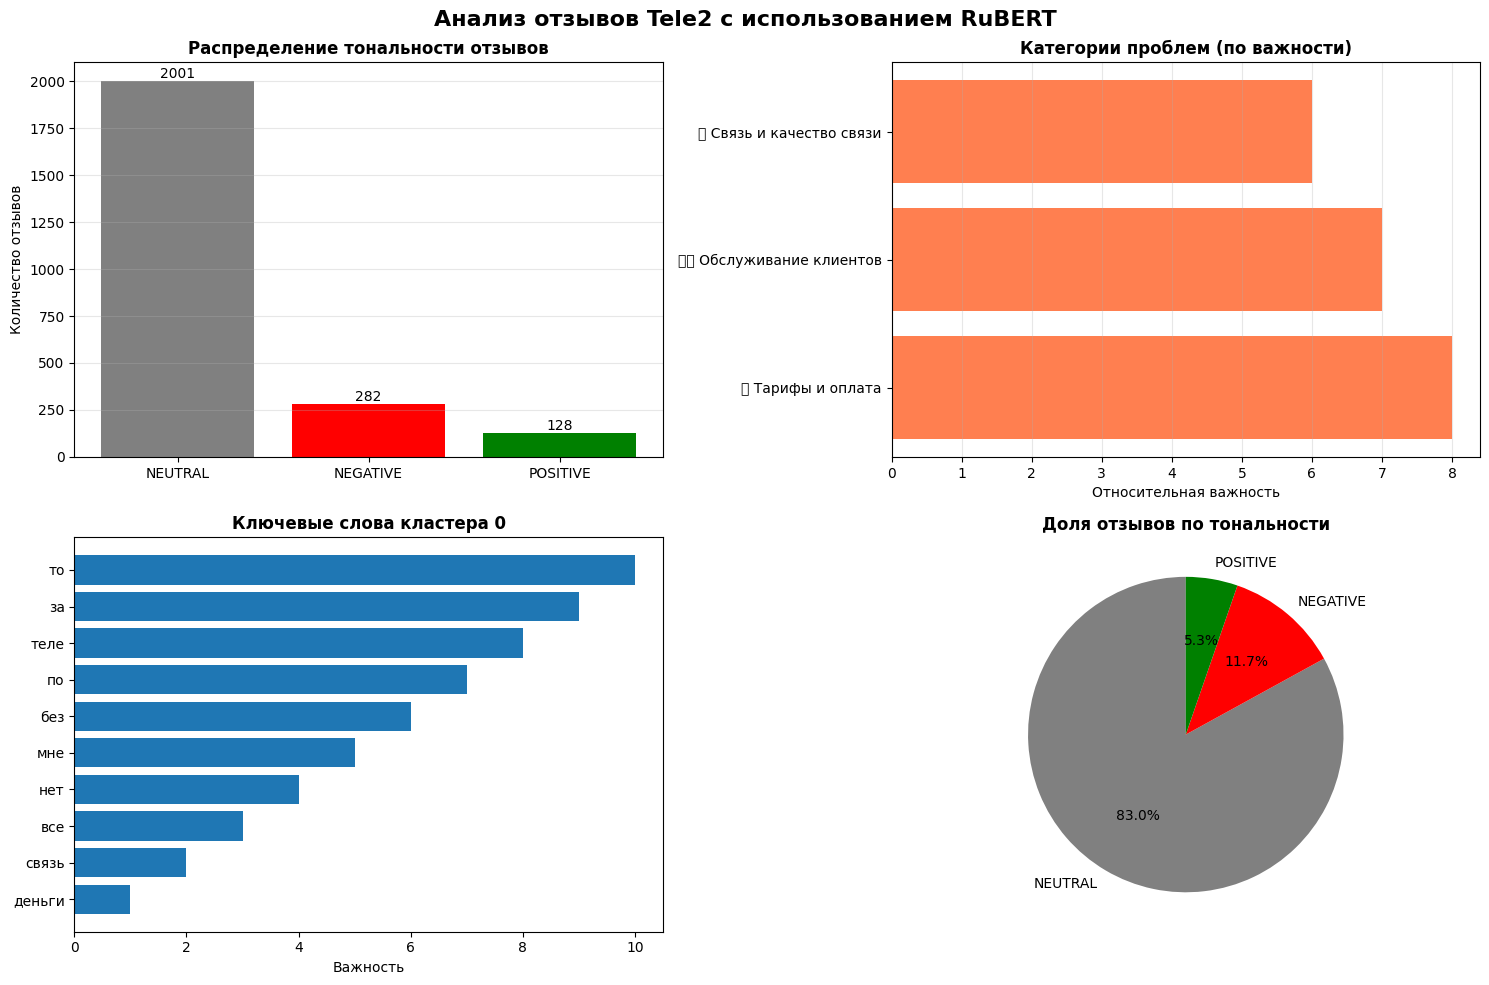


📋 СВОДНАЯ ИНФОРМАЦИЯ:
----------------------------------------
Всего отзывов: 2411
Негативных отзывов: 282 (11.7%)
Выявлено категорий проблем: 8

🔝 ТОП-3 КАТЕГОРИИ ПРОБЛЕМ:
1. 💰 Тарифы и оплата
   Ключевые слова: то, за, теле

2. 👨‍💼 Обслуживание клиентов
   Ключевые слова: за, как, номер

3. 📡 Связь и качество связи
   Ключевые слова: связь, интернет, нет


💾 Экспорт результатов в tele2_analysis_rubert.xlsx...
✅ Результаты успешно экспортированы в tele2_analysis_rubert.xlsx

🎯 РЕКОМЕНДАЦИИ ПО РЕЗУЛЬТАТАМ:
1. Доля негативных отзывов: 11.7%
2. Основных категорий проблем выявлено: 8
3. Приоритетные направления для улучшения:
   1. 💰 Тарифы и оплата
   2. 👨‍💼 Обслуживание клиентов
   3. 📡 Связь и качество связи


In [ ]:
import pandas as pd
import numpy as np
import torch
import re
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

# ============================================================================
# 1. ФУНКЦИЯ ЧТЕНИЯ ФАЙЛА БЕЗ РАЗБИВКИ НА СТОЛБЦЫ (ВАША ВЕРСИЯ)
# ============================================================================
def read_file_as_single_column(file_path):
    """
    Читает файл, где каждая строка - один отзыв.
    Не пытается разбить на столбцы по запятым.
    """
    print(f"📖 Чтение файла {file_path}...")

    # Пробуем разные кодировки
    encodings = ['utf-8', 'cp1251', 'windows-1251', 'latin1', 'iso-8859-1']

    for encoding in encodings:
        try:
            print(f"  Пробуем кодировку: {encoding}")

            # Читаем весь файл как текст
            with open(file_path, 'r', encoding=encoding, errors='ignore') as f:
                lines = f.readlines()

            print(f"  Прочитано строк: {len(lines)}")

            # Убираем пустые строки и символы переноса
            cleaned_lines = []
            for line in lines:
                line_clean = line.strip()
                if line_clean:  # Если строка не пустая
                    cleaned_lines.append(line_clean)

            print(f"  Непустых строк: {len(cleaned_lines)}")

            # Создаем DataFrame с одной колонкой
            df = pd.DataFrame({'review': cleaned_lines})

            # Показываем примеры первых строк
            print("\n  Примеры первых 3 отзывов:")
            for i in range(min(3, len(df))):
                print(f"    {i+1}: {df['review'].iloc[i][:100]}...")

            return df

        except UnicodeDecodeError:
            print(f"  Кодировка {encoding} не подошла")
            continue
        except Exception as e:
            print(f"  Ошибка при чтении с кодировкой {encoding}: {str(e)[:50]}...")
            continue

    # Если все кодировки не подошли
    print("  ⚠️ Не удалось прочитать файл стандартными кодировками")
    print("  Пробуем бинарное чтение...")

    try:
        with open(file_path, 'rb') as f:
            content = f.read()

        # Пробуем декодировать с игнорированием ошибок
        text = content.decode('utf-8', errors='ignore')
        lines = text.split('\n')
        cleaned_lines = [line.strip() for line in lines if line.strip()]

        df = pd.DataFrame({'review': cleaned_lines})
        print(f"  Прочитано {len(df)} строк через бинарное чтение")
        return df

    except Exception as e:
        print(f"  ❌ Критическая ошибка: {e}")
        return None

# ============================================================================
# 2. ПРЕДОБРАБОТКА ТЕКСТА
# ============================================================================
def preprocess_russian_text(text):
    """Очистка и предобработка русского текста"""
    if not isinstance(text, str):
        return ""

    # Приводим к нижнему регистру
    text = text.lower()

    # Удаляем ссылки
    text = re.sub(r'http\S+|www\S+', '', text)

    # Удаляем email
    text = re.sub(r'\S+@\S+', '', text)

    # Удаляем специальные символы, но сохраняем кириллицу и знаки препинания
    text = re.sub(r'[^а-яА-ЯёЁ\s.,!?:;-]', ' ', text)

    # Удаляем лишние пробелы
    text = re.sub(r'\s+', ' ', text)

    # Удаляем пробелы в начале и конце
    text = text.strip()

    return text

# ============================================================================
# 3. ЗАГРУЗКА И ИНИЦИАЛИЗАЦИЯ МОДЕЛЕЙ RuBERT/RuRoBERTa
# ============================================================================
def load_nlp_models(model_type='rubert'):
    """
    Загрузка моделей NLP

    Параметры:
    model_type: 'rubert' или 'ruroberta'
    """
    try:
        from transformers import AutoTokenizer, AutoModel, pipeline

        print(f"🤖 Загружаем модели {model_type.upper()}...")

        if model_type == 'rubert':
            # Модель для эмбеддингов
            tokenizer = AutoTokenizer.from_pretrained('DeepPavlov/rubert-base-cased')
            model = AutoModel.from_pretrained('DeepPavlov/rubert-base-cased')

            # Модель для анализа тональности
            sentiment_model = pipeline(
                "sentiment-analysis",
                model="blanchefort/rubert-base-cased-sentiment",
                tokenizer="blanchefort/rubert-base-cased-sentiment"
            )
        else:  # ruroberta
            # Модель для эмбеддингов
            tokenizer = AutoTokenizer.from_pretrained('ai-forever/ruRoBERTa-large')
            model = AutoModel.from_pretrained('ai-forever/ruRoBERTa-large')

            # Используем ту же модель для тональности или аналогичную
            sentiment_model = pipeline(
                "sentiment-analysis",
                model="blanchefort/rubert-base-cased-sentiment",
                tokenizer="blanchefort/rubert-base-cased-sentiment"
            )

        model.eval()
        print("✅ Модели успешно загружены")

        return tokenizer, model, sentiment_model

    except Exception as e:
        print(f"❌ Ошибка загрузки моделей: {e}")
        print("⚠️ Убедитесь, что установлены библиотеки: pip install transformers torch sentencepiece")
        return None, None, None

# ============================================================================
# 4. ПОЛУЧЕНИЕ ЭМБЕДДИНГОВ С ИСПОЛЬЗОВАНИЕМ RuBERT
# ============================================================================
def get_embeddings(texts, tokenizer, model, batch_size=4, max_length=256):
    """Получение векторных представлений текстов с помощью RuBERT"""
    if tokenizer is None or model is None:
        print("⚠️ Модели не загружены, используем упрощенный анализ")
        return None

    print("🔍 Получение эмбеддингов отзывов...")

    embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Обработка батчей"):
        batch = texts[i:i + batch_size]

        # Токенизация
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        # Получение эмбеддингов
        with torch.no_grad():
            outputs = model(**inputs)
            # Используем эмбеддинг [CLS] токена
            batch_embeddings = outputs.last_hidden_state[:, 0, :].numpy()

        embeddings.append(batch_embeddings)

    if embeddings:
        return np.vstack(embeddings)
    return None

# ============================================================================
# 5. АНАЛИЗ ТОНАЛЬНОСТИ С ПОМОЩЬЮ RuBERT
# ============================================================================
def analyze_sentiment_rubert(texts, sentiment_model, batch_size=8):
    """Анализ тональности с помощью предобученной модели"""
    if sentiment_model is None:
        print("⚠️ Модель тональности не загружена, используем простой анализ")
        return None, None

    print("😊 Анализ тональности с помощью RuBERT...")

    sentiments = []
    scores = []

    # Ограничиваем количество для скорости
    max_texts = min(500, len(texts))
    texts_to_analyze = texts[:max_texts]

    for i in tqdm(range(0, len(texts_to_analyze), batch_size), desc="Анализ тональности"):
        batch = texts_to_analyze[i:i + batch_size]

        for text in batch:
            try:
                # Обрезаем длинные тексты
                if len(text) > 500:
                    text = text[:500]

                result = sentiment_model(text)[0]
                sentiments.append(result['label'])
                scores.append(result['score'])
            except Exception as e:
                # В случае ошибки используем нейтральную тональность
                sentiments.append('NEUTRAL')
                scores.append(0.5)

    # Если проанализировали не все, добавляем NEUTRAL для остальных
    if len(sentiments) < len(texts):
        sentiments.extend(['NEUTRAL'] * (len(texts) - len(sentiments)))
        scores.extend([0.5] * (len(texts) - len(scores)))

    return sentiments, scores

# ============================================================================
# 6. КЛАСТЕРИЗАЦИЯ ПРОБЛЕМ С ИСПОЛЬЗОВАНИЕМ ЭМБЕДДИНГОВ
# ============================================================================
def cluster_problems_with_embeddings(texts, embeddings, n_clusters=8):
    """Кластеризация отзывов для выявления проблем с использованием эмбеддингов"""
    if embeddings is None or len(embeddings) < n_clusters:
        print("⚠️ Недостаточно данных для кластеризации, используем TF-IDF")
        return cluster_problems_with_tfidf(texts, n_clusters)

    print(f"🎯 Кластеризация {len(texts)} отзывов на {n_clusters} кластеров...")

    # Кластеризация K-means
    kmeans = KMeans(n_clusters=min(n_clusters, len(embeddings)),
                   random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)

    # Для каждого кластера находим ключевые слова
    print("📊 Извлечение ключевых слов для кластеров...")
    cluster_keywords = extract_keywords_for_clusters(texts, clusters)

    return clusters, cluster_keywords

def cluster_problems_with_tfidf(texts, n_clusters=8):
    """Кластеризация проблем с использованием TF-IDF"""
    print("🎯 Кластеризация с использованием TF-IDF...")

    # Русские стоп-слова
    russian_stopwords = [
        'и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'все',
        'она', 'так', 'его', 'но', 'да', 'ты', 'к', 'у', 'же', 'вы', 'за', 'бы', 'по',
        'только', 'ее', 'мне', 'было', 'вот', 'от', 'меня', 'еще', 'нет', 'о', 'из', 'ему',
        'теперь', 'когда', 'даже', 'ну', 'ли', 'если', 'уже', 'или', 'ни', 'быть', 'был',
        'него', 'до', 'вас', 'нибудь', 'уж', 'вам', 'сказал', 'ведь', 'там', 'потом', 'себя'
    ]

    # Создаем TF-IDF векторизатор
    vectorizer = TfidfVectorizer(
        max_features=200,
        stop_words=russian_stopwords,
        ngram_range=(1, 2),  # Учитываем словосочетания
        min_df=2  # Игнорируем слова, встречающиеся реже 2 раз
    )

    X = vectorizer.fit_transform(texts)

    # Кластеризация
    kmeans = KMeans(n_clusters=min(n_clusters, len(texts)),
                   random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X)

    # Извлечение ключевых слов
    cluster_keywords = {}
    for cluster_id in range(min(n_clusters, len(texts))):
        # Индексы документов в кластере
        indices = np.where(clusters == cluster_id)[0]

        if len(indices) > 0:
            # Средний TF-IDF вектор для кластера
            cluster_vectors = X[indices]
            centroid = cluster_vectors.mean(axis=0)

            # Получаем топ-10 слов с наибольшим весом
            feature_names = vectorizer.get_feature_names_out()
            centroid_weights = np.asarray(centroid).ravel()
            top_indices = centroid_weights.argsort()[-10:][::-1]

            keywords = [feature_names[i] for i in top_indices]
            cluster_keywords[cluster_id] = keywords

    return clusters, cluster_keywords

def extract_keywords_for_clusters(texts, clusters):
    """Извлечение ключевых слов для каждого кластера"""
    # Используем TF-IDF для извлечения ключевых слов
    vectorizer = TfidfVectorizer(
        max_features=100,
        stop_words=['и', 'в', 'не', 'на', 'что', 'это'],
        ngram_range=(1, 2)
    )

    cluster_keywords = {}
    unique_clusters = np.unique(clusters)

    for cluster_id in unique_clusters:
        # Тексты в этом кластере
        cluster_texts = [texts[i] for i in range(len(texts))
                        if clusters[i] == cluster_id]

        if cluster_texts:
            # Обучаем TF-IDF на текстах кластера
            X = vectorizer.fit_transform(cluster_texts)
            feature_names = vectorizer.get_feature_names_out()

            # Средний вес терминов в кластере
            avg_weights = np.asarray(X.mean(axis=0)).ravel()

            # Топ-10 ключевых слов
            top_indices = avg_weights.argsort()[-10:][::-1]
            keywords = [feature_names[i] for i in top_indices]

            cluster_keywords[cluster_id] = keywords

    return cluster_keywords

# ============================================================================
# 7. ОСНОВНАЯ ФУНКЦИЯ АНАЛИЗА С RuBERT
# ============================================================================
def analyze_t2_reviews_with_rubert(file_path, model_type='rubert', use_gpu=False):
    """
    Полный анализ отзывов T2 с использованием RuBERT/RuRoBERTa

    Параметры:
    - file_path: путь к файлу с отзывами
    - model_type: 'rubert' или 'ruroberta'
    - use_gpu: использовать ли GPU для вычислений
    """

    print("="*80)
    print("🚀 ЗАПУСК ПРОДВИНУТОГО АНАЛИЗА ОТЗЫВОВ T2 С RuBERT")
    print("="*80)

    # 1. Чтение файла
    print("\n📋 ШАГ 1: ЧТЕНИЕ ФАЙЛА")
    df = read_file_as_single_column(file_path)

    if df is None or len(df) == 0:
        print("❌ Не удалось прочитать файл")
        return None

    print(f"✅ Прочитано отзывов: {len(df)}")

    # 2. Предобработка текста
    print("\n🧹 ШАГ 2: ПРЕДОБРАБОТКА ТЕКСТА")
    df['cleaned_review'] = df['review'].apply(preprocess_russian_text)

    # Удаляем слишком короткие отзывы
    initial_count = len(df)
    df = df[df['cleaned_review'].str.split().str.len() >= 3]
    print(f"✅ После очистки: {len(df)} отзывов (удалено {initial_count - len(df)})")

    reviews = df['cleaned_review'].tolist()

    # 3. Загрузка моделей NLP
    print("\n🤖 ШАГ 3: ЗАГРУЗКА NLP-МОДЕЛЕЙ")
    tokenizer, model, sentiment_model = load_nlp_models(model_type)

    # 4. Анализ тональности
    print("\n😊 ШАГ 4: АНАЛИЗ ТОНАЛЬНОСТИ")

    if sentiment_model:
        sentiments, scores = analyze_sentiment_rubert(reviews, sentiment_model)
        if sentiments:
            df['sentiment'] = sentiments
            df['sentiment_score'] = scores
    else:
        # Простой анализ тональности на основе ключевых слов
        print("⚠️ Используем простой анализ тональности...")
        sentiments = []
        negative_words = ['плох', 'ужас', 'кошмар', 'проблем', 'не работ', 'сломал', 'долго', 'дорог']

        for review in reviews:
            if any(word in review for word in negative_words):
                sentiments.append('NEGATIVE')
            else:
                sentiments.append('NEUTRAL')

        df['sentiment'] = sentiments

    # Статистика по тональности
    sentiment_counts = df['sentiment'].value_counts()
    print("\n📊 РАСПРЕДЕЛЕНИЕ ТОНАЛЬНОСТИ:")
    for sentiment, count in sentiment_counts.items():
        percentage = count / len(df) * 100
        print(f"  {sentiment}: {count} ({percentage:.1f}%)")

    # 5. Анализ негативных отзывов
    print("\n🔍 ШАГ 5: АНАЛИЗ НЕГАТИВНЫХ ОТЗЫВОВ")
    negative_df = df[df['sentiment'] == 'NEGATIVE']
    negative_reviews = negative_df['cleaned_review'].tolist()

    print(f"✅ Негативных отзывов: {len(negative_reviews)}")

    if len(negative_reviews) < 10:
        print("⚠️ Слишком мало негативных отзывов для анализа проблем")
        # Используем все отзывы для анализа
        negative_reviews = reviews
        print("⚠️ Будем анализировать все отзывы")

    # 6. Получение эмбеддингов для негативных отзывов
    print("\n🎯 ШАГ 6: ПОЛУЧЕНИЕ ЭМБЕДДИНГОВ")
    embeddings = None
    if model and tokenizer and len(negative_reviews) > 0:
        embeddings = get_embeddings(negative_reviews, tokenizer, model)

    # 7. Кластеризация проблем
    print("\n📊 ШАГ 7: КЛАСТЕРИЗАЦИЯ ПРОБЛЕМ")

    # Определяем оптимальное количество кластеров
    n_clusters = min(8, max(3, len(negative_reviews) // 10))
    print(f"  Используем {n_clusters} кластеров")

    if embeddings is not None:
        clusters, cluster_keywords = cluster_problems_with_embeddings(
            negative_reviews, embeddings, n_clusters=n_clusters
        )
    else:
        clusters, cluster_keywords = cluster_problems_with_tfidf(
            negative_reviews, n_clusters=n_clusters
        )

    # 8. Анализ категорий проблем
    print("\n📈 ШАГ 8: АНАЛИЗ КАТЕГОРИЙ ПРОБЛЕМ")

    problem_categories = analyze_problem_categories(cluster_keywords, negative_reviews, clusters)

    # 9. Сбор результатов
    print("\n💾 ШАГ 9: ФОРМИРОВАНИЕ ОТЧЕТА")

    results = {
        'total_reviews': len(df),
        'negative_reviews': len(negative_reviews),
        'sentiment_distribution': sentiment_counts.to_dict(),
        'clusters': clusters,
        'cluster_keywords': cluster_keywords,
        'problem_categories': problem_categories,
        'df': df,
        'negative_df': negative_df if 'negative_df' in locals() else None
    }

    return results

def analyze_problem_categories(cluster_keywords, reviews, clusters):
    """Анализ и классификация категорий проблем"""

    # Шаблоны для определения категорий
    category_patterns = {
        '📡 Связь и качество связи': [
            'связь', 'сигнал', 'звонок', 'сеть', 'интернет', 'мобильный',
            'телефон', 'разговор', 'голос', 'помехи', 'обрыв'
        ],
        '💰 Тарифы и оплата': [
            'тариф', 'оплата', 'деньги', 'цена', 'стоимость', 'списание',
            'баланс', 'счет', 'платеж', 'рубль', 'копейка'
        ],
        '👨‍💼 Обслуживание клиентов': [
            'обслуживание', 'поддержка', 'консультант', 'сотрудник', 'менеджер',
            'оператор', 'сервис', 'вежлив', 'груб', 'нахамил'
        ],
        '📱 Технические проблемы': [
            'приложение', 'сайт', 'интернет', 'настройка', 'ошибка', 'глюк',
            'зависание', 'технический', 'программа', 'софт'
        ],
        '⏱️ Время ожидания': [
            'долго', 'медленно', 'ожидание', 'время', 'час', 'минута', 'ждал',
            'очередь', 'быстро', 'скорость'
        ],
        '📄 Документы и процедуры': [
            'договор', 'документ', 'паспорт', 'подпись', 'активация', 'блокировка',
            'оформление', 'процедура', 'регистрация'
        ],
        '🌐 Интернет и данные': [
            'интернет', 'данные', 'трафик', 'скорость', 'загрузка', 'скачивание',
            'онлайн', 'браузер', 'сайт'
        ]
    }

    categories_analysis = {}

    if cluster_keywords:
        for cluster_id, keywords in cluster_keywords.items():
            # Объединяем все ключевые слова кластера
            all_keywords_text = ' '.join(keywords).lower()

            # Считаем совпадения с каждой категорией
            category_scores = {}
            for category, patterns in category_patterns.items():
                score = 0
                for pattern in patterns:
                    if pattern in all_keywords_text:
                        score += 1

                # Также проверяем в самих отзывах
                if clusters is not None:
                    cluster_reviews = [reviews[i] for i in range(len(reviews))
                                     if clusters[i] == cluster_id]
                    if cluster_reviews:
                        combined_reviews = ' '.join(cluster_reviews).lower()
                        for pattern in patterns:
                            if pattern in combined_reviews:
                                score += 2  # Больший вес для совпадений в отзывах

                category_scores[category] = score

            # Определяем основную категорию
            if category_scores:
                main_category = max(category_scores.items(), key=lambda x: x[1])[0]
                categories_analysis[cluster_id] = {
                    'category': main_category,
                    'keywords': keywords[:8],  # Берем топ-8 ключевых слов
                    'score': category_scores[main_category]
                }

    return categories_analysis

# ============================================================================
# 8. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================================================
def visualize_rubert_results(results):
    """Визуализация результатов анализа с RuBERT"""

    if results is None:
        print("❌ Нет результатов для визуализации")
        return

    print("\n" + "="*80)
    print("📊 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
    print("="*80)

    # Создаем графики
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Анализ отзывов Tele2 с использованием RuBERT', fontsize=16, fontweight='bold')

    # 1. Распределение тональности
    ax1 = axes[0, 0]
    if 'sentiment_distribution' in results:
        sentiments = results['sentiment_distribution']
        colors = {'NEGATIVE': 'red', 'NEUTRAL': 'gray', 'POSITIVE': 'green'}

        bars = ax1.bar(sentiments.keys(), sentiments.values(),
                      color=[colors.get(s, 'blue') for s in sentiments.keys()])
        ax1.set_title('Распределение тональности отзывов', fontweight='bold')
        ax1.set_ylabel('Количество отзывов')
        ax1.grid(axis='y', alpha=0.3)

        # Добавляем значения на столбцы
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{int(height)}', ha='center', va='bottom')

    # 2. Категории проблем
    ax2 = axes[0, 1]
    if 'problem_categories' in results and results['problem_categories']:
        categories = results['problem_categories']

        # Подготовка данных
        cat_names = []
        cat_counts = []

        for cluster_id, data in categories.items():
            # Используем количество кластеров как примерное количество отзывов
            cat_names.append(data['category'])
            # Для простоты используем порядковый номер как количество
            cat_counts.append(len(categories) - list(categories.keys()).index(cluster_id))

        # Сортировка
        sorted_indices = np.argsort(cat_counts)[::-1]
        cat_names = [cat_names[i] for i in sorted_indices]
        cat_counts = [cat_counts[i] for i in sorted_indices]

        bars = ax2.barh(cat_names, cat_counts, color='coral')
        ax2.set_title('Категории проблем (по важности)', fontweight='bold')
        ax2.set_xlabel('Относительная важность')
        ax2.grid(axis='x', alpha=0.3)

    # 3. Ключевые слова по кластерам (пример)
    ax3 = axes[1, 0]
    if 'cluster_keywords' in results and results['cluster_keywords']:
        cluster_keywords = results['cluster_keywords']

        # Берем первый кластер для примера
        if 0 in cluster_keywords:
            keywords = cluster_keywords[0][:10]  # Топ-10 ключевых слов
            importance = list(range(len(keywords), 0, -1))

            ax3.barh(keywords[::-1], importance[::-1])
            ax3.set_title('Ключевые слова кластера 0', fontweight='bold')
            ax3.set_xlabel('Важность')

    # 4. Круговая диаграмма тональности
    ax4 = axes[1, 1]
    if 'sentiment_distribution' in results:
        sentiments = results['sentiment_distribution']
        colors_pie = {'NEGATIVE': 'red', 'NEUTRAL': 'gray', 'POSITIVE': 'green'}

        ax4.pie(sentiments.values(), labels=sentiments.keys(),
               autopct='%1.1f%%', colors=[colors_pie.get(s, 'blue') for s in sentiments.keys()],
               startangle=90)
        ax4.set_title('Доля отзывов по тональности', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # 5. Дополнительная информация
    print("\n📋 СВОДНАЯ ИНФОРМАЦИЯ:")
    print("-" * 40)
    print(f"Всего отзывов: {results['total_reviews']}")

    if 'sentiment_distribution' in results:
        neg_count = results['sentiment_distribution'].get('NEGATIVE', 0)
        print(f"Негативных отзывов: {neg_count} ({neg_count/results['total_reviews']*100:.1f}%)")

    if 'problem_categories' in results:
        print(f"Выявлено категорий проблем: {len(results['problem_categories'])}")
        print("\n🔝 ТОП-3 КАТЕГОРИИ ПРОБЛЕМ:")

        categories = results['problem_categories']
        for i, (cluster_id, data) in enumerate(list(categories.items())[:3], 1):
            print(f"{i}. {data['category']}")
            print(f"   Ключевые слова: {', '.join(data['keywords'][:3])}")
            print()

# ============================================================================
# 9. ЭКСПОРТ РЕЗУЛЬТАТОВ
# ============================================================================
def export_rubert_results(results, filename='tele2_analysis_rubert.xlsx'):
    """Экспорт результатов анализа с RuBERT в Excel"""

    if results is None:
        print("❌ Нет результатов для экспорта")
        return

    print(f"\n💾 Экспорт результатов в {filename}...")

    try:
        with pd.ExcelWriter(filename, engine='openpyxl') as writer:
            # 1. Все отзывы
            if 'df' in results:
                results['df'].to_excel(writer, sheet_name='Все отзывы', index=False)

            # 2. Негативные отзывы
            if 'negative_df' in results and results['negative_df'] is not None:
                results['negative_df'].to_excel(writer, sheet_name='Негативные отзывы', index=False)

            # 3. Статистика
            stats_data = []
            stats_data.append(['Всего отзывов', results['total_reviews']])

            if 'sentiment_distribution' in results:
                for sentiment, count in results['sentiment_distribution'].items():
                    stats_data.append([f'Отзывов {sentiment}', count])

            if 'problem_categories' in results:
                stats_data.append(['Категорий проблем', len(results['problem_categories'])])

            pd.DataFrame(stats_data, columns=['Метрика', 'Значение']).to_excel(
                writer, sheet_name='Статистика', index=False
            )

            # 4. Категории проблем
            if 'problem_categories' in results and results['problem_categories']:
                categories_data = []
                for cluster_id, data in results['problem_categories'].items():
                    categories_data.append({
                        'ID кластера': cluster_id,
                        'Категория': data['category'],
                        'Ключевые слова': ', '.join(data['keywords']),
                        'Оценка важности': data.get('score', 0)
                    })

                pd.DataFrame(categories_data).to_excel(
                    writer, sheet_name='Категории проблем', index=False
                )

        print(f"✅ Результаты успешно экспортированы в {filename}")

    except Exception as e:
        print(f"❌ Ошибка при экспорте: {e}")
        print("⚠️ Пробуем экспортировать в CSV...")

        try:
            # Альтернативный экспорт в CSV
            if 'df' in results:
                results['df'].to_csv('tele2_all_reviews.csv', index=False, encoding='utf-8')

            if 'problem_categories' in results:
                categories_df = pd.DataFrame([
                    {'Категория': data['category'], 'Ключевые слова': ', '.join(data['keywords'])}
                    for data in results['problem_categories'].values()
                ])
                categories_df.to_csv('tele2_problem_categories.csv', index=False, encoding='utf-8')

            print("✅ Результаты экспортированы в CSV файлы")

        except Exception as e2:
            print(f"❌ Ошибка при экспорте в CSV: {e2}")

# ============================================================================
# 10. ОСНОВНАЯ ФУНКЦИЯ
# ============================================================================
def main():
    """Основная функция для запуска анализа"""

    print("="*80)
    print("📊 АНАЛИЗ ОТЗЫВОВ TELE2 С ИСПОЛЬЗОВАНИЕМ RuBERT")
    print("="*80)

    # Путь к файлу
    file_path = "Tele2_reviews.csv"  # Замените на ваш путь

    print("\nВыберите режим анализа:")
    print("1. Полный анализ с RuBERT (рекомендуется)")
    print("2. Быстрый анализ без глубокого NLP")
    print("3. Только чтение и предпросмотр файла")

    choice = input("\nВведите номер (1-3): ").strip()

    if choice == '1':
        print("\n" + "="*80)
        print("🚀 ЗАПУСК ПОЛНОГО АНАЛИЗА С RuBERT")
        print("="*80)

        # Запускаем продвинутый анализ
        results = analyze_t2_reviews_with_rubert(file_path, model_type='rubert')

        if results:
            # Визуализация
            visualize_rubert_results(results)

            # Экспорт
            export_rubert_results(results)

            # Дополнительная информация
            print("\n" + "="*80)
            print("🎯 РЕКОМЕНДАЦИИ ПО РЕЗУЛЬТАТАМ:")
            print("="*80)

            if results['sentiment_distribution'].get('NEGATIVE', 0) > 0:
                print(f"1. Доля негативных отзывов: {results['sentiment_distribution'].get('NEGATIVE', 0)/results['total_reviews']*100:.1f}%")
                print(f"2. Основных категорий проблем выявлено: {len(results.get('problem_categories', {}))}")

                if 'problem_categories' in results:
                    print("3. Приоритетные направления для улучшения:")
                    categories = results['problem_categories']
                    for i, (cluster_id, data) in enumerate(list(categories.items())[:3], 1):
                        print(f"   {i}. {data['category']}")
            else:
                print("🎉 Отличный результат! Негативных отзывов не обнаружено.")

    elif choice == '2':
        print("\n⚡ ЗАПУСК БЫСТРОГО АНАЛИЗА...")

        # Просто читаем файл и делаем базовый анализ
        df = read_file_as_single_column(file_path)

        if df is not None:
            # Быстрый анализ ключевых слов
            print("\n🔍 БЫСТРЫЙ АНАЛИЗ КЛЮЧЕВЫХ СЛОВ...")

            all_text = ' '.join(df['review'].astype(str).tolist()).lower()

            # Ищем проблемные слова
            problem_words = ['проблем', 'плох', 'ужас', 'кошмар', 'не работ', 'сломал',
                           'долго', 'дорог', 'обман', 'нахам', 'груб']

            print("Частота проблемных слов:")
            for word in problem_words:
                count = all_text.count(word)
                if count > 0:
                    print(f"  {word}: {count}")

            # Примеры отзывов с проблемами
            print("\n📝 ПРИМЕРЫ ОТЗЫВОВ С ПРОБЛЕМАМИ:")
            for i, review in enumerate(df['review'].head(5)):
                if any(word in review.lower() for word in problem_words[:3]):
                    print(f"\n{i+1}. {review[:150]}...")

    elif choice == '3':
        print("\n👀 ПРОСМОТР ФАЙЛА...")
        df = read_file_as_single_column(file_path)

        if df is not None:
            print("\n📋 СОДЕРЖИМОЕ ФАЙЛА:")
            print("-" * 80)
            for i in range(min(10, len(df))):
                print(f"{i+1:3d}. {df['review'].iloc[i][:100]}...")

            if len(df) > 10:
                print(f"\n... и еще {len(df) - 10} отзывов")

    else:
        print("❌ Неверный выбор")

# ============================================================================
# ЗАПУСК ПРОГРАММЫ
# ============================================================================
if __name__ == "__main__":
    # Проверяем наличие необходимых библиотек
    try:
        import transformers
        import torch
        print("✅ Библиотеки transformers и torch установлены")
    except ImportError:
        print("⚠️ Библиотеки transformers и torch не установлены")
        print("Установите их командой: pip install transformers torch")
        print("\nЗапускаем в упрощенном режиме...")

    # Запускаем программу
    main()

📊 АНАЛИЗАТОР ОТЗЫВОВ TELE2
📁 Файл для анализа: Tele2_reviews.csv

Выберите режим анализа:
1. Полный анализ (рекомендуется)
2. Быстрый анализ (только ключевые слова)
3. Только визуализация облака слов
4. Экспорт данных без анализа

Введите номер (1-4): 1

🚀 ЗАПУСК ПОЛНОГО АНАЛИЗА
Ограничить количество анализируемых отзывов? (y/n, по умолчанию n): n
🚀 КОМПЛЕКСНЫЙ АНАЛИЗ ОТЗЫВОВ TELE2

📋 ШАГ 1: ЧТЕНИЕ ФАЙЛА
📖 Чтение файла Tele2_reviews.csv...
  Пробуем кодировку: utf-8
  Прочитано строк: 2998
  Непустых строк: 2998

  Примеры первых 3 отзывов:
    1: ﻿Хочу выразить огромную благодарность сотруднику Теле2 в Нижнем Новгороде, ул. Плотникова, дом 3А На...
    2: Не могут решить вопрос с поступление смс именно от Т2, остальные смс все приходят. Запрет на смс от ...
    3: Отвратительный оператор связи, после оформления сим-карты в течении 10 дней меня просто блокировали ...
✅ Всего отзывов для анализа: 2998

🧹 ШАГ 2: ПРЕДОБРАБОТКА ТЕКСТА
✅ После очистки: 2124 отзывов (удалено 874)

😊 ШАГ 3: А

Анализ тональности: 100%|██████████| 2124/2124 [00:00<00:00, 75327.03it/s]


📊 РАСПРЕДЕЛЕНИЕ ТОНАЛЬНОСТИ:
  NEUTRAL: 1375 (64.7%)
  NEGATIVE: 385 (18.1%)
  POSITIVE: 364 (17.1%)

🔍 ШАГ 4: ВЫДЕЛЕНИЕ НЕГАТИВНЫХ ОТЗЫВОВ
✅ Негативных отзывов: 385

🔑 ШАГ 5: АНАЛИЗ КЛЮЧЕВЫХ СЛОВ И ФРАЗ
🔍 Извлечение ключевых фраз с помощью TF-IDF...
📊 Частотный анализ ключевых слов...
🔗 Извлечение словосочетаний...

📊 ШАГ 6: КЛАСТЕРИЗАЦИЯ И КАТЕГОРИЗАЦИЯ ПРОБЛЕМ
🎯 Кластеризация отзывов по темам...
📈 Категоризация проблем...
🔎 Идентификация частых проблем...

💾 ШАГ 7: ФОРМИРОВАНИЕ РЕЗУЛЬТАТОВ

📊 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ АНАЛИЗА


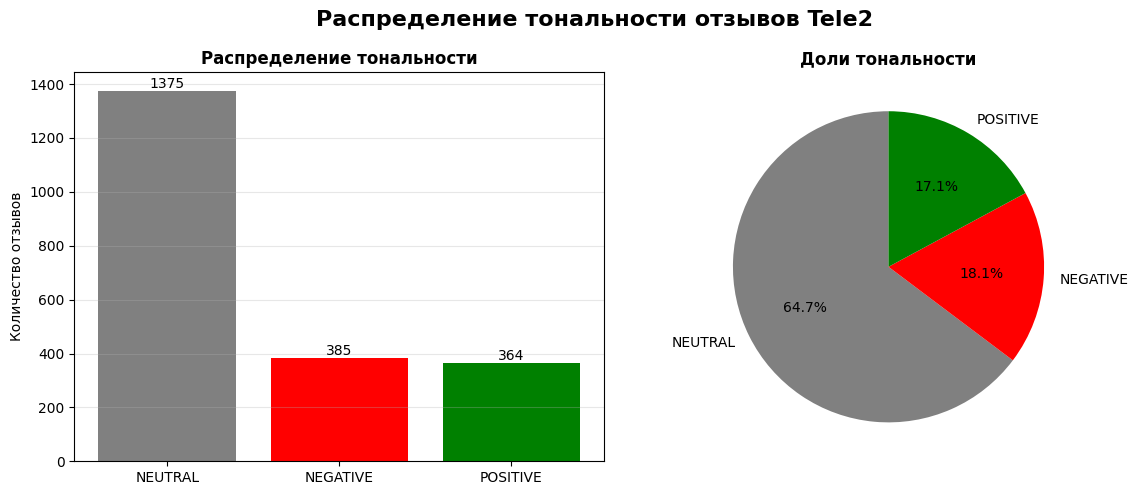

☁️ Создание облака слов...


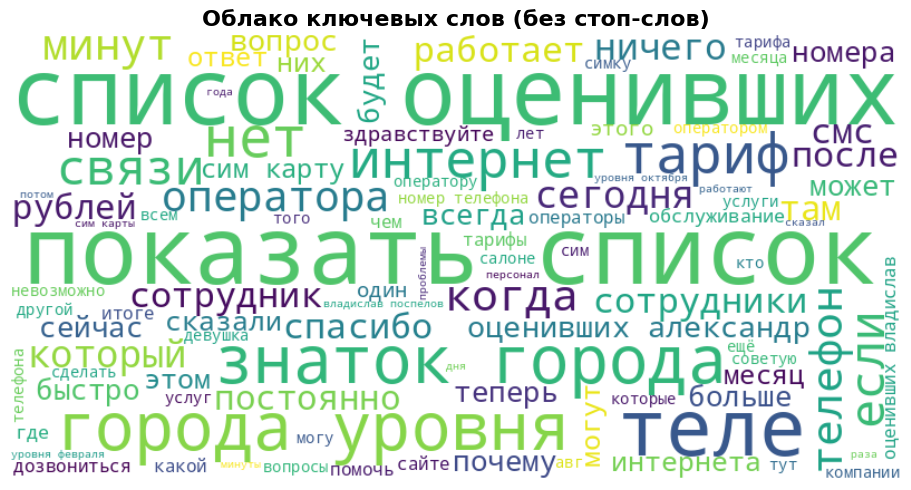

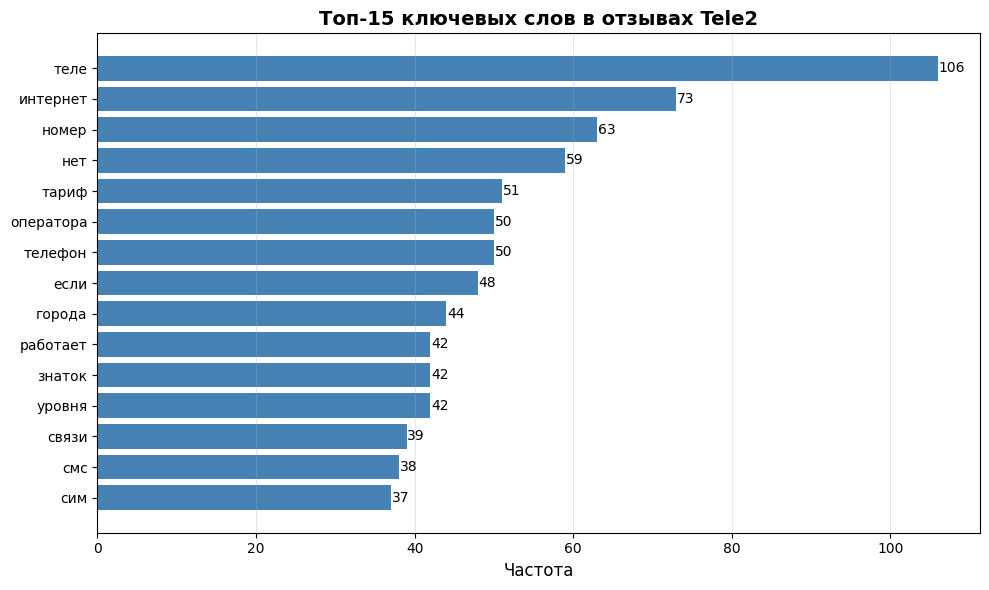

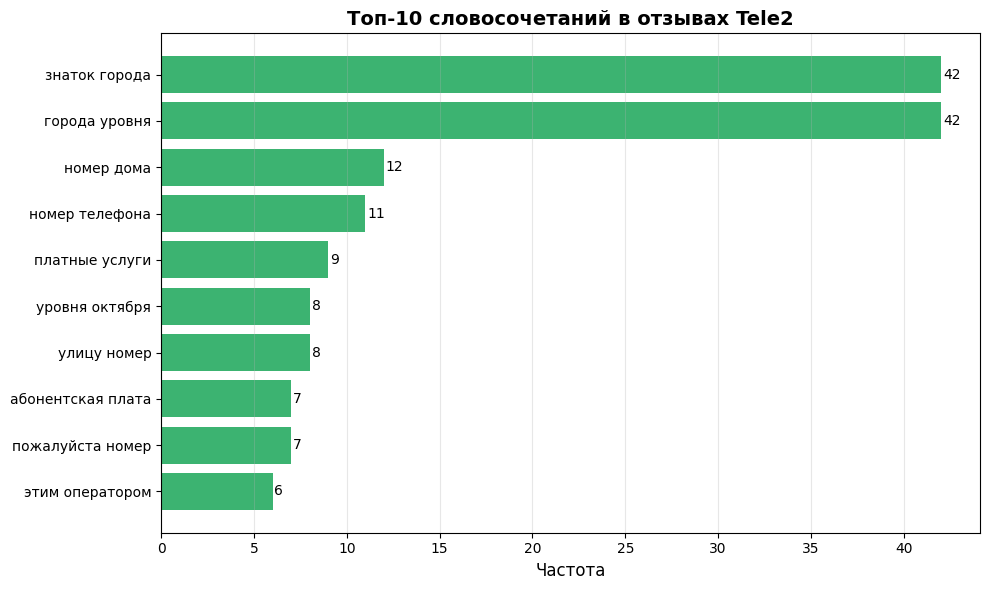

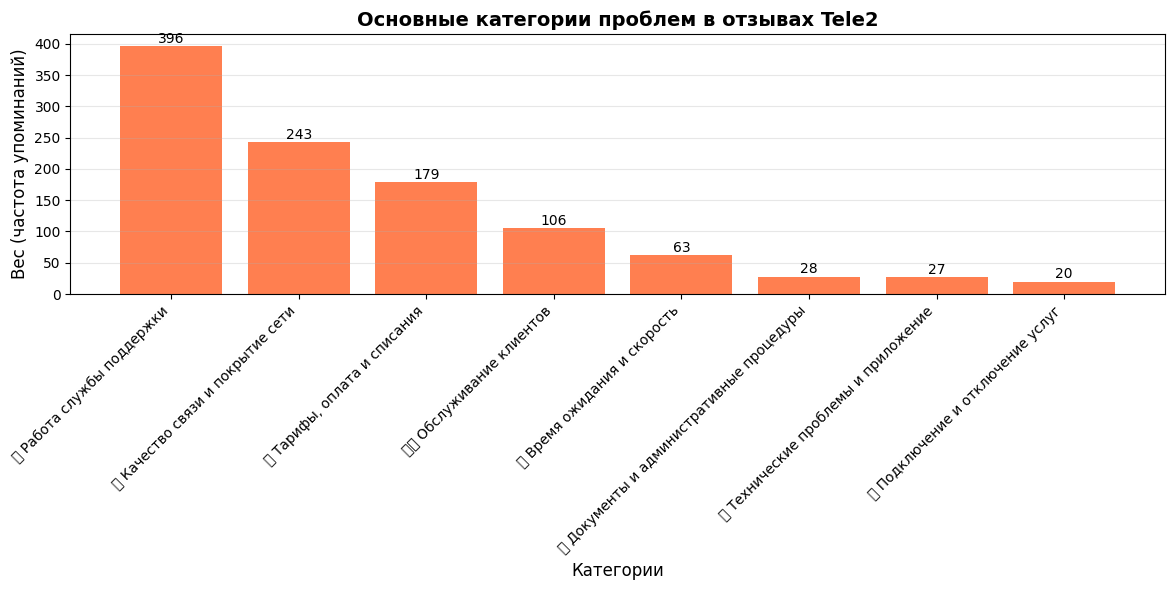


📋 ДЕТАЛЬНЫЙ ОТЧЕТ ПО АНАЛИЗУ ОТЗЫВОВ TELE2

📊 ОСНОВНЫЕ МЕТРИКИ:
  • Всего проанализировано отзывов: 2124
  • Негативных отзывов: 385 (18.1%)
  • Позитивных отзывов: 364
  • Нейтральных отзывов: 1375

🔑 ТОП-10 КЛЮЧЕВЫХ СЛОВ (без стоп-слов):
   1. теле                 -  106
   2. интернет             -   73
   3. номер                -   63
   4. нет                  -   59
   5. тариф                -   51
   6. оператора            -   50
   7. телефон              -   50
   8. если                 -   48
   9. города               -   44
  10. работает             -   42

🔝 ТОП-10 КЛЮЧЕВЫХ ФРАЗ:
   1. теле                                     - 0.035
   2. интернет                                 - 0.029
   3. нет                                      - 0.024
   4. номер                                    - 0.023
   5. оператора                                - 0.019
   6. если                                     - 0.019
   7. тариф                                    - 0.018
   8. раб

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import os
from wordcloud import WordCloud

# ============================================================================
# 1. НАСТРОЙКИ И ПАРАМЕТРЫ
# ============================================================================

# Расширенный список русских стоп-слов
RUSSIAN_STOPWORDS = {
    # Местоимения
    'я', 'ты', 'он', 'она', 'оно', 'мы', 'вы', 'они', 'меня', 'тебя', 'его', 'ее',
    'нас', 'вас', 'их', 'мне', 'тебе', 'ему', 'ей', 'нам', 'вам', 'им', 'мной', 'тобой',
    'ним', 'ней', 'нами', 'вами', 'ими', 'мой', 'твой', 'его', 'ее', 'наш', 'ваш', 'их',

    # Предлоги
    'в', 'во', 'на', 'над', 'под', 'к', 'ко', 'о', 'об', 'обо', 'от', 'ото', 'до', 'по',
    'со', 'из', 'изо', 'у', 'без', 'безо', 'для', 'за', 'между', 'меж', 'перед', 'пред',
    'при', 'про', 'ради', 'с', 'сквозь', 'среди', 'через', 'чрез', 'из-за', 'из-под',

    # Союзы
    'и', 'а', 'но', 'да', 'или', 'либо', 'то', 'ни', 'не', 'нибудь', 'кое', 'таки',
    'ли', 'бы', 'б', 'же', 'ведь', 'вот', 'мол', 'де', 'дескать', 'только', 'лишь',
    'ибо', 'также', 'тоже', 'зато', 'однако', 'причем', 'притом', 'итак',

    # Частицы и вводные слова
    'бы', 'ведь', 'вон', 'вот', 'все', 'всё', 'всего', 'всю', 'вы', 'да', 'де', 'дескать',
    'же', 'и', 'или', 'как', 'ли', 'либо', 'мол', 'не', 'ни', 'ну', 'о', 'пожалуй',
    'просто', 'прямо', 'разве', 'сказать', 'совсем', 'так', 'таки', 'то', 'только',
    'точно', 'хоть', 'хотя', 'чего', 'что', 'чтоб', 'чтобы', 'это', 'этот',

    # Частые неинформативные слова (по результатам анализа)
    'по', 'как', 'все', 'за', 'без', 'мне', 'тебе', 'нам', 'вам', 'им', 'очень',
    'просто', 'даже', 'уже', 'еще', 'опять', 'снова', 'можно', 'нужно', 'надо',
    'хорошо', 'плохо', 'сильно', 'сразу', 'почти', 'вообще', 'особенно',

    # Вспомогательные глаголы
    'быть', 'есть', 'был', 'была', 'было', 'были', 'стать', 'стал', 'стала', 'стало',
    'стали', 'являться', 'казаться', 'оказаться',

    # Слова, специфичные для отзывов
    'компания', 'фирма', 'организация', 'сервис', 'услуга', 'продукт', 'товар',
    'магазин', 'салон', 'офис', 'представительство',

    # Для телеком-оператора
    'теле2', 'tele2', 'оператор', 'мобильный', 'связь', 'сотовый',

    # Общие слова
    'человек', 'люди', 'день', 'время', 'раз', 'голос', 'рука', 'нога', 'лицо',
    'место', 'работа', 'жизнь', 'деньги', 'слово', 'голова', 'дом', 'мир',
}

# Минимальная длина слова для анализа
MIN_WORD_LENGTH = 3

# ============================================================================
# 2. ФУНКЦИИ ДЛЯ ЧТЕНИЯ И ПРЕДОБРАБОТКИ ФАЙЛА
# ============================================================================

def read_file_as_single_column(file_path):
    """
    Читает файл, где каждая строка - один отзыв.
    Не пытается разбить на столбцы по запятым.
    """
    print(f"📖 Чтение файла {file_path}...")

    # Пробуем разные кодировки
    encodings = ['utf-8', 'cp1251', 'windows-1251', 'latin1', 'iso-8859-1']

    for encoding in encodings:
        try:
            print(f"  Пробуем кодировку: {encoding}")

            # Читаем весь файл как текст
            with open(file_path, 'r', encoding=encoding, errors='ignore') as f:
                lines = f.readlines()

            print(f"  Прочитано строк: {len(lines)}")

            # Убираем пустые строки и символы переноса
            cleaned_lines = []
            for line in lines:
                line_clean = line.strip()
                if line_clean:  # Если строка не пустая
                    cleaned_lines.append(line_clean)

            print(f"  Непустых строк: {len(cleaned_lines)}")

            # Создаем DataFrame с одной колонкой
            df = pd.DataFrame({'review': cleaned_lines})

            # Показываем примеры первых строк
            print("\n  Примеры первых 3 отзывов:")
            for i in range(min(3, len(df))):
                print(f"    {i+1}: {df['review'].iloc[i][:100]}...")

            return df

        except UnicodeDecodeError:
            print(f"  Кодировка {encoding} не подошла")
            continue
        except Exception as e:
            print(f"  Ошибка при чтении с кодировкой {encoding}: {str(e)[:50]}...")
            continue

    # Если все кодировки не подошли
    print("  ⚠️ Не удалось прочитать файл стандартными кодировками")
    print("  Пробуем бинарное чтение...")

    try:
        with open(file_path, 'rb') as f:
            content = f.read()

        # Пробуем декодировать с игнорированием ошибок
        text = content.decode('utf-8', errors='ignore')
        lines = text.split('\n')
        cleaned_lines = [line.strip() for line in lines if line.strip()]

        df = pd.DataFrame({'review': cleaned_lines})
        print(f"  Прочитано {len(df)} строк через бинарное чтение")
        return df

    except Exception as e:
        print(f"  ❌ Критическая ошибка: {e}")
        return None

def preprocess_russian_text(text, remove_stopwords=True):
    """
    Очистка и предобработка русского текста

    Параметры:
    - text: исходный текст
    - remove_stopwords: удалять ли стоп-слова
    """
    if not isinstance(text, str):
        return ""

    # Приводим к нижнему регистру
    text = text.lower()

    # Удаляем ссылки
    text = re.sub(r'http\S+|www\S+', '', text)

    # Удаляем email
    text = re.sub(r'\S+@\S+', '', text)

    # Удаляем номера телефонов
    text = re.sub(r'[\+\d\s\-\(\)]{7,}', '', text)

    # Удаляем специальные символы, оставляем кириллицу и знаки препинания
    text = re.sub(r'[^а-яё\s\.\,\!\?\:\;\-]', ' ', text)

    # Заменяем множественные пробелы одним
    text = re.sub(r'\s+', ' ', text)

    # Удаляем пробелы в начале и конце
    text = text.strip()

    # Удаляем стоп-слова, если нужно
    if remove_stopwords:
        words = text.split()
        filtered_words = [word for word in words if word not in RUSSIAN_STOPWORDS]
        text = ' '.join(filtered_words)

    return text

def clean_text_for_analysis(text):
    """
    Очистка текста специально для анализа ключевых слов
    (более агрессивная очистка)
    """
    if not isinstance(text, str):
        return ""

    # Базовая предобработка
    text = preprocess_russian_text(text, remove_stopwords=False)

    # Удаляем все знаки препинания
    text = re.sub(r'[\.\,\!\?\:\;\-]', ' ', text)

    # Оставляем только слова определенной длины
    words = text.split()
    filtered_words = [
        word for word in words
        if len(word) >= MIN_WORD_LENGTH and word not in RUSSIAN_STOPWORDS
    ]

    return ' '.join(filtered_words)

# ============================================================================
# 3. ФУНКЦИИ ДЛЯ АНАЛИЗА ТОНАЛЬНОСТИ
# ============================================================================

def analyze_sentiment_simple(texts):
    """
    Простой анализ тональности на основе ключевых слов
    (используется если нет моделей NLP)
    """
    print("😊 Анализ тональности (простой метод)...")

    # Ключевые слова для определения тональности
    negative_keywords = [
        'плох', 'ужас', 'кошмар', 'отврат', 'недовол', 'разочар', 'проблем',
        'не работ', 'сломал', 'не функци', 'глюк', 'зависа', 'медлен', 'долго',
        'дорог', 'обман', 'мошенник', 'врет', 'лож', 'нахам', 'груб', 'некоррект',
        'увол', 'уволь', 'потеря', 'пропал', 'исчез', 'плохо', 'ужасно', 'отвратительно',
        'мерзость', 'гадость', 'бесполезн', 'беспонтов', 'отстой', 'лажа', 'фигня',
        'хрень', 'дерьмо', 'говно'
    ]

    positive_keywords = [
        'хорош', 'отлич', 'прекрас', 'замечат', 'супер', 'класс', 'рекоменд',
        'благодар', 'спасибо', 'довол', 'удовлетвор', 'рад', 'понрав', 'люб',
        'восхит', 'идеаль', 'беспроблем', 'быстр', 'оператив', 'качеств',
        'профессион', 'вежлив', 'помог', 'решил', 'отлично', 'прекрасно',
        'замечательно', 'суперски', 'классно', 'шикарно', 'великолепно'
    ]

    sentiments = []

    for text in tqdm(texts, desc="Анализ тональности"):
        text_lower = text.lower()

        # Считаем ключевые слова
        neg_count = sum(1 for word in negative_keywords if word in text_lower)
        pos_count = sum(1 for word in positive_keywords if word in text_lower)

        # Определяем тональность
        if neg_count > pos_count:
            sentiments.append('NEGATIVE')
        elif pos_count > neg_count:
            sentiments.append('POSITIVE')
        else:
            sentiments.append('NEUTRAL')

    return sentiments

# ============================================================================
# 4. ФУНКЦИИ ДЛЯ АНАЛИЗА КЛЮЧЕВЫХ СЛОВ И ФРАЗ
# ============================================================================

def extract_keywords_tfidf(texts, top_n=30, ngram_range=(1, 2)):
    """
    Извлечение ключевых слов и фраз с использованием TF-IDF
    с фильтрацией стоп-слов
    """
    print("🔍 Извлечение ключевых фраз с помощью TF-IDF...")

    # Преобразуем стоп-слова в список для sklearn
    stopwords_list = list(RUSSIAN_STOPWORDS)

    # Создаем TF-IDF векторизатор с фильтрацией стоп-слов
    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=1000,
        stop_words=stopwords_list,
        min_df=2,  # Минимальная частота слова в документах
        max_df=0.8,  # Максимальная доля документов, в которых встречается слово
        token_pattern=r'\b[а-яё]{3,}\b'  # Только кириллические слова от 3 букв
    )

    try:
        # Преобразуем тексты в матрицу TF-IDF
        X = vectorizer.fit_transform(texts)
        feature_names = vectorizer.get_feature_names_out()

        # Вычисляем средний TF-IDF по всем документам
        avg_tfidf = np.asarray(X.mean(axis=0)).ravel()

        # Получаем индексы топ-N фраз
        top_indices = avg_tfidf.argsort()[-top_n:][::-1]

        # Формируем результат
        key_phrases = []
        for idx in top_indices:
            phrase = feature_names[idx]
            score = avg_tfidf[idx]

            # Дополнительная проверка: пропускаем фразы с короткими словами
            words = phrase.split()
            if all(len(word) >= MIN_WORD_LENGTH for word in words):
                key_phrases.append((phrase, score))

        return key_phrases[:top_n]

    except Exception as e:
        print(f"⚠️ Ошибка при извлечении ключевых фраз: {e}")
        # Возвращаем пустой список в случае ошибки
        return []

def analyze_word_frequency(texts, top_n=30):
    """
    Частотный анализ слов с фильтрацией стоп-слов
    """
    print("📊 Частотный анализ ключевых слов...")

    all_words = []

    for text in texts:
        # Извлекаем только кириллические слова от 3 букв
        words = re.findall(r'\b[а-яё]{3,}\b', text.lower())

        # Фильтруем стоп-слова
        words = [word for word in words if word not in RUSSIAN_STOPWORDS]

        all_words.extend(words)

    # Считаем частотность
    word_freq = Counter(all_words)

    return word_freq.most_common(top_n)

def extract_bigrams(texts, top_n=20):
    """
    Извлечение биграмм (словосочетаний из 2 слов)
    с фильтрацией стоп-слов
    """
    print("🔗 Извлечение словосочетаний...")

    bigrams = []

    for text in texts:
        # Извлекаем слова
        words = re.findall(r'\b[а-яё]{3,}\b', text.lower())

        # Фильтруем стоп-слова
        words = [word for word in words if word not in RUSSIAN_STOPWORDS]

        # Создаем биграммы из оставшихся слов
        for i in range(len(words) - 1):
            bigram = f"{words[i]} {words[i+1]}"
            bigrams.append(bigram)

    # Считаем частотность биграмм
    bigram_freq = Counter(bigrams)

    # Дополнительная фильтрация: удаляем биграммы с короткими словами
    filtered_bigrams = {}
    for bigram, count in bigram_freq.items():
        word1, word2 = bigram.split()
        if len(word1) >= 4 and len(word2) >= 4:
            filtered_bigrams[bigram] = count

    return Counter(filtered_bigrams).most_common(top_n)

# ============================================================================
# 5. ФУНКЦИИ ДЛЯ КЛАСТЕРИЗАЦИИ И КАТЕГОРИЗАЦИИ ПРОБЛЕМ
# ============================================================================

def cluster_reviews_by_topic(texts, n_clusters=5):
    """
    Кластеризация отзывов по темам с использованием TF-IDF и K-means
    """
    print("🎯 Кластеризация отзывов по темам...")

    if len(texts) < n_clusters:
        print(f"⚠️ Недостаточно отзывов для кластеризации ({len(texts)} < {n_clusters})")
        return None, None

    # Преобразуем стоп-слова в список
    stopwords_list = list(RUSSIAN_STOPWORDS)

    # Создаем TF-IDF векторизатор
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=500,
        stop_words=stopwords_list,
        min_df=2,
        token_pattern=r'\b[а-яё]{3,}\b'
    )

    try:
        # Преобразуем тексты в матрицу TF-IDF
        X = vectorizer.fit_transform(texts)

        # Определяем оптимальное количество кластеров
        actual_n_clusters = min(n_clusters, len(texts))

        # Выполняем кластеризацию K-means
        kmeans = KMeans(n_clusters=actual_n_clusters, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(X)

        # Извлекаем ключевые слова для каждого кластера
        cluster_keywords = {}
        order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
        terms = vectorizer.get_feature_names_out()

        for i in range(actual_n_clusters):
            top_terms = [terms[ind] for ind in order_centroids[i, :10]]
            cluster_keywords[i] = top_terms

        return clusters, cluster_keywords

    except Exception as e:
        print(f"⚠️ Ошибка при кластеризации: {e}")
        return None, None

def categorize_problems_by_keywords(texts, keywords, top_n=5):
    """
    Категоризация проблем по ключевым словам
    """
    print("📈 Категоризация проблем...")

    # Категории проблем для телеком-оператора
    problem_categories = {
        '📶 Качество связи и покрытие сети': {
            'keywords': ['связь', 'сигнал', 'покрытие', 'сеть', 'интернет', 'звонок', 'мобильный'],
            'weight': 0,
            'examples': []
        },
        '💰 Тарифы, оплата и списания': {
            'keywords': ['тариф', 'оплата', 'деньги', 'цена', 'списание', 'баланс', 'стоимость'],
            'weight': 0,
            'examples': []
        },
        '👨‍💼 Обслуживание клиентов': {
            'keywords': ['обслуживание', 'поддержка', 'сотрудник', 'консультант', 'менеджер', 'сервис'],
            'weight': 0,
            'examples': []
        },
        '📱 Технические проблемы и приложение': {
            'keywords': ['приложение', 'сайт', 'ошибка', 'глюк', 'зависание', 'технический', 'настройка'],
            'weight': 0,
            'examples': []
        },
        '⏱️ Время ожидания и скорость': {
            'keywords': ['медленно', 'долго', 'скорость', 'ожидание', 'время', 'задержка', 'быстро'],
            'weight': 0,
            'examples': []
        },
        '📞 Работа службы поддержки': {
            'keywords': ['звонок', 'дозвониться', 'поддержка', 'оператор', 'телефон', 'горячий', 'линия'],
            'weight': 0,
            'examples': []
        },
        '📄 Документы и административные процедуры': {
            'keywords': ['договор', 'документ', 'паспорт', 'подпись', 'оформление', 'процедура', 'блокировка'],
            'weight': 0,
            'examples': []
        },
        '🔄 Подключение и отключение услуг': {
            'keywords': ['подключение', 'отключение', 'услуга', 'активация', 'деактивация', 'подключить'],
            'weight': 0,
            'examples': []
        }
    }

    # Анализируем все тексты
    all_text = ' '.join(texts).lower()

    # Вычисляем вес каждой категории
    for category, data in problem_categories.items():
        weight = 0

        # Считаем вхождения ключевых слов
        for keyword in data['keywords']:
            weight += all_text.count(keyword)

        # Также проверяем ключевые слова из анализа
        for word, freq in keywords:
            if any(keyword in word for keyword in data['keywords']):
                weight += freq

        data['weight'] = weight

        # Находим примеры отзывов для категории
        examples_found = 0
        for text in texts[:50]:  # Проверяем первые 50 отзывов
            if examples_found >= 2:
                break

            if any(keyword in text.lower() for keyword in data['keywords'][:3]):
                # Обрезаем текст для примера
                if len(text) > 150:
                    example = text[:150] + '...'
                else:
                    example = text

                data['examples'].append(example)
                examples_found += 1

    # Фильтруем категории с нулевым весом
    filtered_categories = {
        cat: data for cat, data in problem_categories.items()
        if data['weight'] > 0
    }

    # Сортируем по весу
    sorted_categories = sorted(
        filtered_categories.items(),
        key=lambda x: x[1]['weight'],
        reverse=True
    )

    # Преобразуем в удобный формат
    result = []
    for category_name, data in sorted_categories[:top_n]:
        result.append({
            'category': category_name,
            'weight': data['weight'],
            'keywords': data['keywords'],
            'examples': data['examples']
        })

    return result

def identify_common_problems(texts, key_phrases, top_n=10):
    """
    Идентификация наиболее частых проблем на основе ключевых фраз
    """
    print("🔎 Идентификация частых проблем...")

    # Создаем словарь для подсчета проблем
    problem_counter = {}

    for phrase, score in key_phrases:
        # Определяем тип проблемы по ключевым словам
        problem_type = None

        if any(word in phrase for word in ['связь', 'сигнал', 'покрытие', 'сеть']):
            problem_type = 'Проблемы со связью'
        elif any(word in phrase for word in ['тариф', 'оплата', 'деньги', 'списание']):
            problem_type = 'Проблемы с тарифами и оплатой'
        elif any(word in phrase for word in ['обслуживание', 'поддержка', 'сотрудник', 'менеджер']):
            problem_type = 'Проблемы с обслуживанием'
        elif any(word in phrase for word in ['приложение', 'сайт', 'ошибка', 'глюк']):
            problem_type = 'Технические проблемы'
        elif any(word in phrase for word in ['медленно', 'долго', 'скорость', 'ожидание']):
            problem_type = 'Проблемы со скоростью'
        elif any(word in phrase for word in ['договор', 'документ', 'оформление', 'блокировка']):
            problem_type = 'Административные проблемы'

        if problem_type:
            if problem_type not in problem_counter:
                problem_counter[problem_type] = {'count': 0, 'examples': []}

            problem_counter[problem_type]['count'] += 1

            # Добавляем пример, если еще нет
            if len(problem_counter[problem_type]['examples']) < 2:
                # Ищем отзыв с этой фразой
                for text in texts:
                    if phrase in text.lower() and text not in problem_counter[problem_type]['examples']:
                        if len(text) > 100:
                            example = text[:100] + '...'
                        else:
                            example = text
                        problem_counter[problem_type]['examples'].append(example)
                        break

    # Сортируем проблемы по частоте
    sorted_problems = sorted(
        problem_counter.items(),
        key=lambda x: x[1]['count'],
        reverse=True
    )[:top_n]

    return sorted_problems

# ============================================================================
# 6. ФУНКЦИИ ДЛЯ ВИЗУАЛИЗАЦИИ РЕЗУЛЬТАТОВ
# ============================================================================

def visualize_keyword_cloud(texts, title="Облако ключевых слов"):
    """
    Создание облака слов из наиболее частых слов
    """
    print("☁️ Создание облака слов...")

    # Объединяем все тексты
    all_text = ' '.join(texts)

    # Удаляем стоп-слова
    words = all_text.split()
    filtered_words = [word for word in words if word not in RUSSIAN_STOPWORDS]
    filtered_text = ' '.join(filtered_words)

    # Создаем облако слов
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis',
        max_words=100,
        contour_width=1,
        contour_color='steelblue'
    ).generate(filtered_text)

    # Отображаем облако слов
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_top_keywords(keywords_data, title="Топ ключевых слов", top_n=15):
    """
    Визуализация топ-N ключевых слов
    """
    if not keywords_data:
        print("⚠️ Нет данных для визуализации ключевых слов")
        return

    # Подготавливаем данные
    if isinstance(keywords_data[0], tuple):
        # Если данные в формате (слово, частота)
        words = [item[0] for item in keywords_data[:top_n]][::-1]
        frequencies = [item[1] for item in keywords_data[:top_n]][::-1]
    else:
        # Если данные уже подготовлены
        words = keywords_data[:top_n][::-1]
        frequencies = list(range(top_n, 0, -1))

    # Создаем график
    plt.figure(figsize=(10, 6))
    bars = plt.barh(words, frequencies, color='steelblue')

    # Настраиваем график
    plt.xlabel('Частота', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)

    # Добавляем значения на столбцы
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
                f'{int(width)}', ha='left', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

def plot_problem_categories(categories_data, title="Категории проблем"):
    """
    Визуализация категорий проблем
    """
    if not categories_data:
        print("⚠️ Нет данных для визуализации категорий проблем")
        return

    # Подготавливаем данные
    category_names = [cat['category'] for cat in categories_data]
    category_weights = [cat['weight'] for cat in categories_data]

    # Создаем график
    plt.figure(figsize=(12, 6))
    bars = plt.bar(category_names, category_weights, color='coral')

    # Настраиваем график
    plt.xlabel('Категории', fontsize=12)
    plt.ylabel('Вес (частота упоминаний)', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.grid(axis='y', alpha=0.3)

    # Добавляем значения на столбцы
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{int(height)}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

def plot_sentiment_distribution(sentiments, title="Распределение тональности отзывов"):
    """
    Визуализация распределения тональности отзывов
    """
    if not sentiments:
        print("⚠️ Нет данных для визуализации тональности")
        return

    # Подсчитываем количество каждого типа тональности
    sentiment_counts = pd.Series(sentiments).value_counts()

    # Определяем цвета
    colors = {'NEGATIVE': 'red', 'NEUTRAL': 'gray', 'POSITIVE': 'green'}
    sentiment_colors = [colors.get(s, 'blue') for s in sentiment_counts.index]

    # Создаем график
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Столбчатая диаграмма
    bars = ax1.bar(sentiment_counts.index, sentiment_counts.values, color=sentiment_colors)
    ax1.set_title('Распределение тональности', fontweight='bold')
    ax1.set_ylabel('Количество отзывов')
    ax1.grid(axis='y', alpha=0.3)

    # Добавляем значения на столбцы
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{int(height)}', ha='center', va='bottom')

    # Круговая диаграмма
    ax2.pie(sentiment_counts.values, labels=sentiment_counts.index,
            autopct='%1.1f%%', colors=sentiment_colors, startangle=90)
    ax2.set_title('Доли тональности', fontweight='bold')

    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_bigrams(bigrams_data, title="Топ словосочетаний", top_n=10):
    """
    Визуализация топ-N словосочетаний
    """
    if not bigrams_data:
        print("⚠️ Нет данных для визуализации словосочетаний")
        return

    # Подготавливаем данные
    bigrams = [item[0] for item in bigrams_data[:top_n]][::-1]
    frequencies = [item[1] for item in bigrams_data[:top_n]][::-1]

    # Создаем график
    plt.figure(figsize=(10, 6))
    bars = plt.barh(bigrams, frequencies, color='mediumseagreen')

    # Настраиваем график
    plt.xlabel('Частота', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)

    # Добавляем значения на столбцы
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
                f'{int(width)}', ha='left', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

# ============================================================================
# 7. ОСНОВНЫЕ ФУНКЦИИ АНАЛИЗА
# ============================================================================

def run_comprehensive_analysis(file_path, max_reviews=None):
    """
    Запуск комплексного анализа отзывов

    Параметры:
    - file_path: путь к файлу с отзывами
    - max_reviews: максимальное количество отзывов для анализа (None = все)
    """
    print("="*80)
    print("🚀 КОМПЛЕКСНЫЙ АНАЛИЗ ОТЗЫВОВ TELE2")
    print("="*80)

    # 1. Чтение файла
    print("\n📋 ШАГ 1: ЧТЕНИЕ ФАЙЛА")
    df = read_file_as_single_column(file_path)

    if df is None or len(df) == 0:
        print("❌ Не удалось прочитать файл или файл пуст")
        return None

    # Ограничиваем количество отзывов, если указано
    if max_reviews and max_reviews < len(df):
        df = df.head(max_reviews)
        print(f"  Анализируем {max_reviews} отзывов (первые из файла)")

    print(f"✅ Всего отзывов для анализа: {len(df)}")

    # 2. Предобработка текста
    print("\n🧹 ШАГ 2: ПРЕДОБРАБОТКА ТЕКСТА")
    df['cleaned_review'] = df['review'].apply(lambda x: preprocess_russian_text(x, remove_stopwords=False))
    df['processed_for_analysis'] = df['review'].apply(clean_text_for_analysis)

    # Удаляем слишком короткие отзывы после очистки
    initial_count = len(df)
    df = df[df['processed_for_analysis'].str.split().str.len() >= 3]
    print(f"✅ После очистки: {len(df)} отзывов (удалено {initial_count - len(df)})")

    if len(df) == 0:
        print("❌ Нет отзывов для анализа после очистки")
        return None

    # Подготавливаем списки текстов
    all_reviews = df['cleaned_review'].tolist()
    processed_reviews = df['processed_for_analysis'].tolist()

    # 3. Анализ тональности
    print("\n😊 ШАГ 3: АНАЛИЗ ТОНАЛЬНОСТИ")
    sentiments = analyze_sentiment_simple(all_reviews)
    df['sentiment'] = sentiments

    # Статистика по тональности
    sentiment_counts = pd.Series(sentiments).value_counts()
    print("\n📊 РАСПРЕДЕЛЕНИЕ ТОНАЛЬНОСТИ:")
    for sentiment, count in sentiment_counts.items():
        percentage = count / len(df) * 100
        print(f"  {sentiment}: {count} ({percentage:.1f}%)")

    # 4. Выделяем негативные отзывы для анализа проблем
    print("\n🔍 ШАГ 4: ВЫДЕЛЕНИЕ НЕГАТИВНЫХ ОТЗЫВОВ")
    negative_reviews = df[df['sentiment'] == 'NEGATIVE']['processed_for_analysis'].tolist()
    print(f"✅ Негативных отзывов: {len(negative_reviews)}")

    # Если негативных отзывов мало, анализируем все
    if len(negative_reviews) < 10:
        print("⚠️ Негативных отзывов мало, анализируем все отзывы")
        reviews_for_problem_analysis = processed_reviews
    else:
        reviews_for_problem_analysis = negative_reviews

    # 5. Анализ ключевых слов и фраз
    print("\n🔑 ШАГ 5: АНАЛИЗ КЛЮЧЕВЫХ СЛОВ И ФРАЗ")

    # 5.1. Извлечение ключевых фраз с помощью TF-IDF
    key_phrases = extract_keywords_tfidf(reviews_for_problem_analysis, top_n=30)

    # 5.2. Частотный анализ слов
    top_keywords = analyze_word_frequency(reviews_for_problem_analysis, top_n=30)

    # 5.3. Извлечение биграмм
    top_bigrams = extract_bigrams(reviews_for_problem_analysis, top_n=20)

    # 6. Кластеризация и категоризация проблем
    print("\n📊 ШАГ 6: КЛАСТЕРИЗАЦИЯ И КАТЕГОРИЗАЦИЯ ПРОБЛЕМ")

    # 6.1. Кластеризация отзывов
    clusters, cluster_keywords = cluster_reviews_by_topic(reviews_for_problem_analysis, n_clusters=5)

    # 6.2. Категоризация проблем
    problem_categories = categorize_problems_by_keywords(reviews_for_problem_analysis, top_keywords, top_n=8)

    # 6.3. Идентификация частых проблем
    common_problems = identify_common_problems(reviews_for_problem_analysis, key_phrases, top_n=10)

    # 7. Формирование результатов
    print("\n💾 ШАГ 7: ФОРМИРОВАНИЕ РЕЗУЛЬТАТОВ")

    results = {
        # Основные метрики
        'total_reviews': len(df),
        'negative_reviews': len(negative_reviews),
        'sentiment_distribution': sentiment_counts.to_dict(),

        # Ключевые слова и фразы
        'key_phrases': key_phrases,
        'top_keywords': top_keywords,
        'top_bigrams': top_bigrams,

        # Проблемы
        'problem_categories': problem_categories,
        'common_problems': common_problems,
        'clusters': clusters,
        'cluster_keywords': cluster_keywords,

        # Исходные данные
        'df': df,
        'negative_reviews_list': negative_reviews,
        'all_reviews_processed': processed_reviews
    }

    return results

def visualize_all_results(results):
    """
    Визуализация всех результатов анализа
    """
    if results is None:
        print("❌ Нет результатов для визуализации")
        return

    print("\n" + "="*80)
    print("📊 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ АНАЛИЗА")
    print("="*80)

    # 1. Распределение тональности
    if 'sentiment_distribution' in results and results['sentiment_distribution']:
        plot_sentiment_distribution(
            results['df']['sentiment'].tolist(),
            "Распределение тональности отзывов Tele2"
        )

    # 2. Облако ключевых слов
    if 'all_reviews_processed' in results and results['all_reviews_processed']:
        visualize_keyword_cloud(
            results['all_reviews_processed'],
            "Облако ключевых слов (без стоп-слов)"
        )

    # 3. Топ ключевых слов
    if 'top_keywords' in results and results['top_keywords']:
        plot_top_keywords(
            results['top_keywords'],
            "Топ-15 ключевых слов в отзывах Tele2",
            top_n=15
        )

    # 4. Топ словосочетаний
    if 'top_bigrams' in results and results['top_bigrams']:
        plot_bigrams(
            results['top_bigrams'],
            "Топ-10 словосочетаний в отзывах Tele2",
            top_n=10
        )

    # 5. Категории проблем
    if 'problem_categories' in results and results['problem_categories']:
        plot_problem_categories(
            results['problem_categories'],
            "Основные категории проблем в отзывах Tele2"
        )

def print_detailed_report(results):
    """
    Вывод детального отчета по результатам анализа
    """
    if results is None:
        print("❌ Нет результатов для отчета")
        return

    print("\n" + "="*80)
    print("📋 ДЕТАЛЬНЫЙ ОТЧЕТ ПО АНАЛИЗУ ОТЗЫВОВ TELE2")
    print("="*80)

    # Основные метрики
    print(f"\n📊 ОСНОВНЫЕ МЕТРИКИ:")
    print(f"  • Всего проанализировано отзывов: {results['total_reviews']}")
    print(f"  • Негативных отзывов: {results['negative_reviews']} ({results['negative_reviews']/results['total_reviews']*100:.1f}%)")

    if 'sentiment_distribution' in results:
        print(f"  • Позитивных отзывов: {results['sentiment_distribution'].get('POSITIVE', 0)}")
        print(f"  • Нейтральных отзывов: {results['sentiment_distribution'].get('NEUTRAL', 0)}")

    # Ключевые слова
    if 'top_keywords' in results and results['top_keywords']:
        print(f"\n🔑 ТОП-10 КЛЮЧЕВЫХ СЛОВ (без стоп-слов):")
        for i, (word, freq) in enumerate(results['top_keywords'][:10], 1):
            print(f"  {i:2d}. {word:20s} - {freq:4d}")

    # Ключевые фразы
    if 'key_phrases' in results and results['key_phrases']:
        print(f"\n🔝 ТОП-10 КЛЮЧЕВЫХ ФРАЗ:")
        for i, (phrase, score) in enumerate(results['key_phrases'][:10], 1):
            print(f"  {i:2d}. {phrase:40s} - {score:.3f}")

    # Категории проблем
    if 'problem_categories' in results and results['problem_categories']:
        print(f"\n📊 ОСНОВНЫЕ КАТЕГОРИИ ПРОБЛЕМ:")
        for i, category in enumerate(results['problem_categories'][:5], 1):
            print(f"\n  {i}. {category['category']} (вес: {category['weight']})")
            print(f"     Ключевые слова: {', '.join(category['keywords'][:5])}")

            if category['examples']:
                print(f"     Пример отзыва: {category['examples'][0]}")

    # Частые проблемы
    if 'common_problems' in results and results['common_problems']:
        print(f"\n🚨 САМЫЕ ЧАСТЫЕ ПРОБЛЕМЫ:")
        for i, (problem, data) in enumerate(results['common_problems'][:5], 1):
            print(f"\n  {i}. {problem} (упоминаний: {data['count']})")
            if data['examples']:
                print(f"     Пример: {data['examples'][0]}")

    # Словосочетания
    if 'top_bigrams' in results and results['top_bigrams']:
        print(f"\n🔗 ТОП-5 СЛОВОСОЧЕТАНИЙ:")
        for i, (bigram, freq) in enumerate(results['top_bigrams'][:5], 1):
            print(f"  {i:2d}. {bigram:30s} - {freq:4d}")

    # Рекомендации
    print("\n" + "="*80)
    print("💡 РЕКОМЕНДАЦИИ ДЛЯ КОМПАНИИ TELE2:")
    print("="*80)

    if results['negative_reviews'] > 0:
        neg_percentage = results['negative_reviews'] / results['total_reviews'] * 100

        if neg_percentage > 30:
            print("🚨 ВЫСОКИЙ УРОВЕНЬ НЕГАТИВНЫХ ОТЗЫВОВ!")
            print("   • Необходим срочный анализ и принятие мер")
        elif neg_percentage > 15:
            print("⚠️ СРЕДНИЙ УРОВЕНЬ НЕГАТИВНЫХ ОТЗЫВОВ")
            print("   • Рекомендуется обратить внимание на основные проблемы")
        else:
            print("✅ НИЗКИЙ УРОВЕНЬ НЕГАТИВНЫХ ОТЗЫВОВ")
            print("   • Поддерживайте текущий уровень сервиса")

        if results['problem_categories']:
            print(f"\n📈 ПРИОРИТЕТНЫЕ НАПРАВЛЕНИЯ ДЛЯ УЛУЧШЕНИЯ:")
            for i, category in enumerate(results['problem_categories'][:3], 1):
                print(f"  {i}. {category['category']}")
    else:
        print("🎉 ОТЛИЧНЫЙ РЕЗУЛЬТАТ! Нет негативных отзывов.")
        print("   • Продолжайте поддерживать высокий уровень сервиса")

def export_results_to_excel(results, filename="tele2_analysis_report.xlsx"):
    """
    Экспорт результатов анализа в Excel файл
    """
    if results is None:
        print("❌ Нет результатов для экспорта")
        return

    print(f"\n💾 Экспорт результатов в файл: {filename}")

    try:
        with pd.ExcelWriter(filename, engine='openpyxl') as writer:
            # 1. Все отзывы с тональностью
            if 'df' in results:
                results['df'][['review', 'sentiment']].to_excel(
                    writer, sheet_name='Все отзывы', index=False
                )

            # 2. Негативные отзывы
            negative_df = results['df'][results['df']['sentiment'] == 'NEGATIVE']
            if len(negative_df) > 0:
                negative_df[['review', 'cleaned_review']].to_excel(
                    writer, sheet_name='Негативные отзывы', index=False
                )

            # 3. Статистика
            stats_data = [
                ['Всего отзывов', results['total_reviews']],
                ['Негативных отзывов', results['negative_reviews']],
                ['Доля негативных отзывов', f"{results['negative_reviews']/results['total_reviews']*100:.1f}%"]
            ]

            if 'sentiment_distribution' in results:
                for sentiment, count in results['sentiment_distribution'].items():
                    stats_data.append([f'Отзывов {sentiment}', count])

            pd.DataFrame(stats_data, columns=['Метрика', 'Значение']).to_excel(
                writer, sheet_name='Статистика', index=False
            )

            # 4. Ключевые слова
            if 'top_keywords' in results and results['top_keywords']:
                keywords_df = pd.DataFrame(results['top_keywords'], columns=['Ключевое слово', 'Частота'])
                keywords_df.to_excel(writer, sheet_name='Ключевые слова', index=False)

            # 5. Ключевые фразы
            if 'key_phrases' in results and results['key_phrases']:
                phrases_df = pd.DataFrame(results['key_phrases'], columns=['Фраза', 'Важность (TF-IDF)'])
                phrases_df.to_excel(writer, sheet_name='Ключевые фразы', index=False)

            # 6. Категории проблем
            if 'problem_categories' in results and results['problem_categories']:
                categories_data = []
                for category in results['problem_categories']:
                    categories_data.append({
                        'Категория': category['category'],
                        'Вес': category['weight'],
                        'Ключевые слова': ', '.join(category['keywords'][:5]),
                        'Пример 1': category['examples'][0] if len(category['examples']) > 0 else '',
                        'Пример 2': category['examples'][1] if len(category['examples']) > 1 else ''
                    })

                categories_df = pd.DataFrame(categories_data)
                categories_df.to_excel(writer, sheet_name='Категории проблем', index=False)

            # 7. Словосочетания
            if 'top_bigrams' in results and results['top_bigrams']:
                bigrams_df = pd.DataFrame(results['top_bigrams'], columns=['Словосочетание', 'Частота'])
                bigrams_df.to_excel(writer, sheet_name='Словосочетания', index=False)

        print(f"✅ Результаты успешно экспортированы в {filename}")

    except Exception as e:
        print(f"❌ Ошибка при экспорте в Excel: {e}")

        # Альтернатива: экспорт в CSV
        print("⚠️ Пробуем экспортировать в CSV файлы...")
        try:
            # Экспортируем основные данные в CSV
            if 'df' in results:
                results['df'][['review', 'sentiment']].to_csv(
                    'tele2_all_reviews.csv', index=False, encoding='utf-8'
                )

            if 'top_keywords' in results:
                pd.DataFrame(results['top_keywords'], columns=['word', 'freq']).to_csv(
                    'tele2_keywords.csv', index=False, encoding='utf-8'
                )

            print("✅ Основные данные экспортированы в CSV файлы")
        except Exception as e2:
            print(f"❌ Ошибка при экспорте в CSV: {e2}")

# ============================================================================
# 8. ГЛАВНАЯ ФУНКЦИЯ И ИНТЕРФЕЙС
# ============================================================================

def main():
    """
    Главная функция для запуска анализа
    """
    print("="*80)
    print("📊 АНАЛИЗАТОР ОТЗЫВОВ TELE2")
    print("="*80)

    # Путь к файлу (можно изменить)
    file_path = "Tele2_reviews.csv"

    # Проверяем существование файла
    if not os.path.exists(file_path):
        print(f"❌ Файл не найден: {file_path}")
        print("   Убедитесь, что файл находится в той же папке, что и скрипт")
        print(f"   Текущая папка: {os.getcwd()}")
        return

    print(f"📁 Файл для анализа: {file_path}")

    # Выбор режима анализа
    print("\nВыберите режим анализа:")
    print("1. Полный анализ (рекомендуется)")
    print("2. Быстрый анализ (только ключевые слова)")
    print("3. Только визуализация облака слов")
    print("4. Экспорт данных без анализа")

    try:
        choice = int(input("\nВведите номер (1-4): ").strip())
    except:
        choice = 1

    if choice == 1:
        # Полный анализ
        print("\n" + "="*80)
        print("🚀 ЗАПУСК ПОЛНОГО АНАЛИЗА")
        print("="*80)

        # Запрашиваем ограничение по количеству отзывов
        use_limit = input("Ограничить количество анализируемых отзывов? (y/n, по умолчанию n): ").strip().lower()

        if use_limit == 'y':
            try:
                max_reviews = int(input("Сколько отзывов анализировать? (по умолчанию 1000): ").strip() or 1000)
            except:
                max_reviews = 1000
        else:
            max_reviews = None

        # Запускаем анализ
        results = run_comprehensive_analysis(file_path, max_reviews=max_reviews)

        if results:
            # Визуализация
            visualize_all_results(results)

            # Детальный отчет
            print_detailed_report(results)

            # Экспорт
            export_choice = input("\n📤 Экспортировать результаты в Excel? (y/n): ").strip().lower()
            if export_choice == 'y':
                export_results_to_excel(results)

    elif choice == 2:
        # Быстрый анализ
        print("\n⚡ ЗАПУСК БЫСТРОГО АНАЛИЗА")

        # Читаем файл
        df = read_file_as_single_column(file_path)

        if df is not None and len(df) > 0:
            # Ограничиваем количество отзывов
            max_reviews = min(500, len(df))
            df = df.head(max_reviews)

            print(f"\nАнализируем {len(df)} отзывов...")

            # Предобработка
            df['processed'] = df['review'].apply(clean_text_for_analysis)
            reviews = df['processed'].tolist()

            # Анализ ключевых слов
            top_keywords = analyze_word_frequency(reviews, top_n=20)

            print("\n🔝 ТОП-20 КЛЮЧЕВЫХ СЛОВ (без стоп-слов):")
            print("-" * 50)
            for i, (word, freq) in enumerate(top_keywords, 1):
                print(f"{i:2d}. {word:20s} - {freq:4d}")

            # Простая визуализация
            plot_top_keywords(top_keywords, "Топ-20 ключевых слов (быстрый анализ)")

    elif choice == 3:
        # Только облако слов
        print("\n☁️ СОЗДАНИЕ ОБЛАКА СЛОВ")

        df = read_file_as_single_column(file_path)

        if df is not None and len(df) > 0:
            # Ограничиваем количество
            max_reviews = min(1000, len(df))
            df = df.head(max_reviews)

            print(f"\nОбрабатываем {len(df)} отзывов для облака слов...")

            # Предобработка
            df['processed'] = df['review'].apply(clean_text_for_analysis)
            reviews = df['processed'].tolist()

            # Создаем облако слов
            visualize_keyword_cloud(reviews, "Облако ключевых слов Tele2")

    elif choice == 4:
        # Экспорт данных без анализа
        print("\n📤 ЭКСПОРТ ДАННЫХ БЕЗ АНАЛИЗА")

        df = read_file_as_single_column(file_path)

        if df is not None and len(df) > 0:
            # Просто экспортируем в Excel
            output_file = "tele2_raw_data.xlsx"
            df.to_excel(output_file, index=False)
            print(f"✅ Данные экспортированы в {output_file}")

            # Также в CSV для совместимости
            df.to_csv("tele2_raw_data.csv", index=False, encoding='utf-8')
            print(f"✅ Данные также экспортированы в tele2_raw_data.csv")

    else:
        print("❌ Неверный выбор. Запускаю полный анализ по умолчанию.")
        results = run_comprehensive_analysis(file_path)
        if results:
            visualize_all_results(results)
            print_detailed_report(results)

    print("\n" + "="*80)
    print("✅ АНАЛИЗ ЗАВЕРШЕН!")
    print("="*80)

# ============================================================================
# ЗАПУСК ПРОГРАММЫ
# ============================================================================

if __name__ == "__main__":
    try:
        main()
    except KeyboardInterrupt:
        print("\n\n⏹️  Анализ прерван пользователем")
    except Exception as e:
        print(f"\n❌ Произошла ошибка: {e}")
        print("\n💡 Рекомендации по устранению ошибки:")
        print("1. Проверьте, что файл с отзывами находится в правильной папке")
        print("2. Убедитесь, что файл имеет правильную кодировку (UTF-8 или Windows-1251)")
        print("3. Проверьте, что установлены все необходимые библиотеки")
        print("4. Если файл большой, попробуйте ограничить количество анализируемых отзывов")

In [ ]:
# Основные библиотеки для экспорта графиков
!pip install matplotlib pandas numpy seaborn wordcloud

# Для интерактивных графиков (опционально)
!pip install plotly kaleido

# Для высококачественного экспорта PDF
!pip install pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 5.6 MB/s eta 0:00:00


📊 АНАЛИЗАТОР ОТЗЫВОВ TELE2 (С ЭКСПОРТОМ ГРАФИКОВ)

🚀 Запуск комплексного анализа...
🚀 КОМПЛЕКСНЫЙ АНАЛИЗ ОТЗЫВОВ TELE2

📋 ШАГ 1: ЧТЕНИЕ ФАЙЛА
📖 Чтение файла Tele2_reviews.csv...
  Пробуем кодировку: utf-8
  Прочитано строк: 2998
  Непустых строк: 2998

  Примеры первых 3 отзывов:
    1: ﻿Хочу выразить огромную благодарность сотруднику Теле2 в Нижнем Новгороде, ул. Плотникова, дом 3А На...
    2: Не могут решить вопрос с поступление смс именно от Т2, остальные смс все приходят. Запрет на смс от ...
    3: Отвратительный оператор связи, после оформления сим-карты в течении 10 дней меня просто блокировали ...
✅ Всего отзывов для анализа: 2998

🧹 ШАГ 2: ПРЕДОБРАБОТКА ТЕКСТА
✅ После очистки: 2124 отзывов (удалено 874)

😊 ШАГ 3: АНАЛИЗ ТОНАЛЬНОСТИ
😊 Анализ тональности (простой метод)...


Анализ тональности: 100%|██████████| 2124/2124 [00:00<00:00, 41759.41it/s]


📊 РАСПРЕДЕЛЕНИЕ ТОНАЛЬНОСТИ:
  NEUTRAL: 1375 (64.7%)
  NEGATIVE: 385 (18.1%)
  POSITIVE: 364 (17.1%)

🔍 ШАГ 4: ВЫДЕЛЕНИЕ НЕГАТИВНЫХ ОТЗЫВОВ
✅ Негативных отзывов: 385

🔑 ШАГ 5: АНАЛИЗ КЛЮЧЕВЫХ СЛОВ И ФРАЗ
🔍 Извлечение ключевых фраз с помощью TF-IDF...
📊 Частотный анализ ключевых слов...
🔗 Извлечение словосочетаний...

📊 ШАГ 6: КЛАСТЕРИЗАЦИЯ И КАТЕГОРИЗАЦИЯ ПРОБЛЕМ
🎯 Кластеризация отзывов по темам...


📈 Категоризация проблем...
🔎 Идентификация частых проблем...

💾 ШАГ 7: ФОРМИРОВАНИЕ РЕЗУЛЬТАТОВ

📊 Отображение графиков на экране...

📊 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ АНАЛИЗА


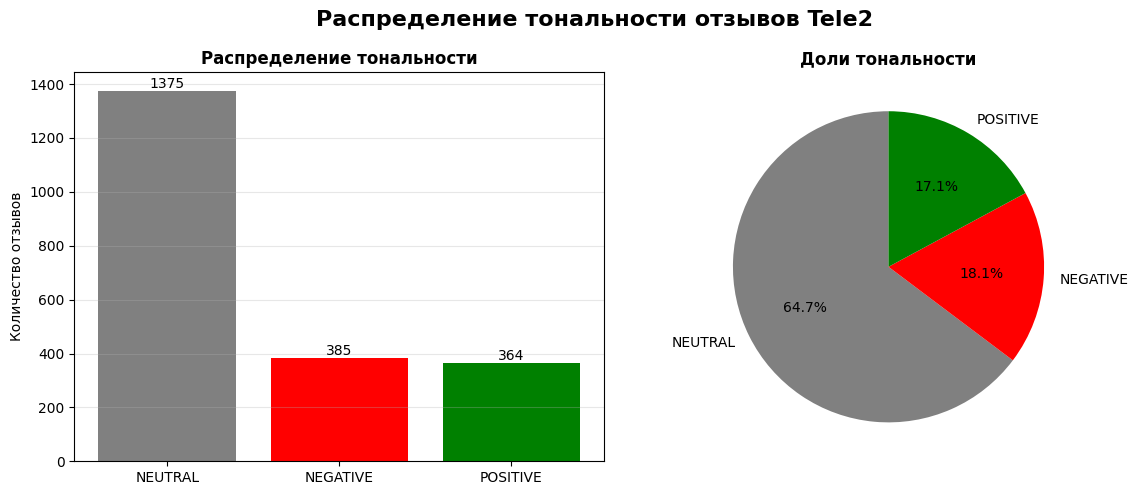

☁️ Создание облака слов...


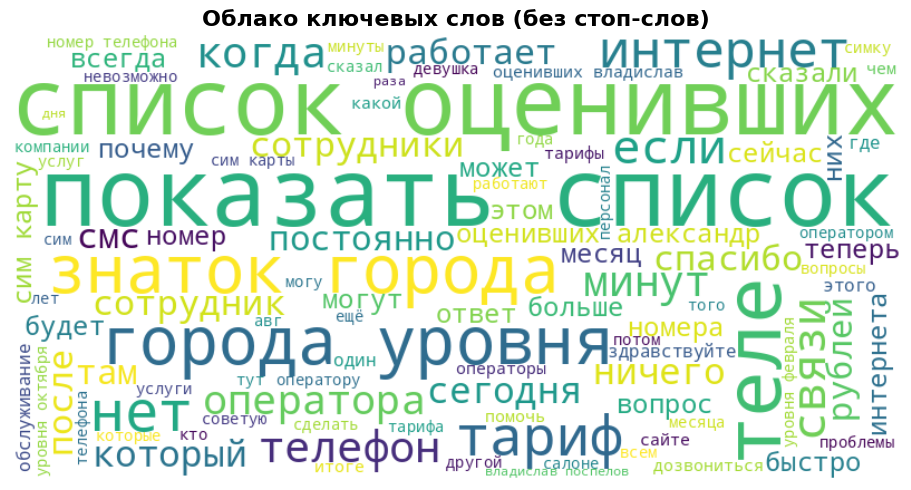

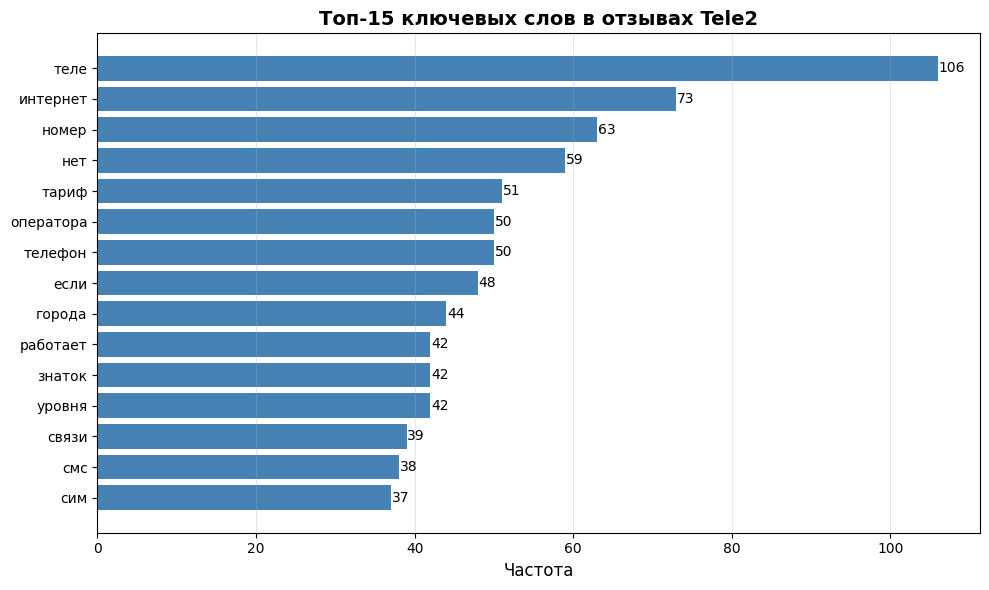

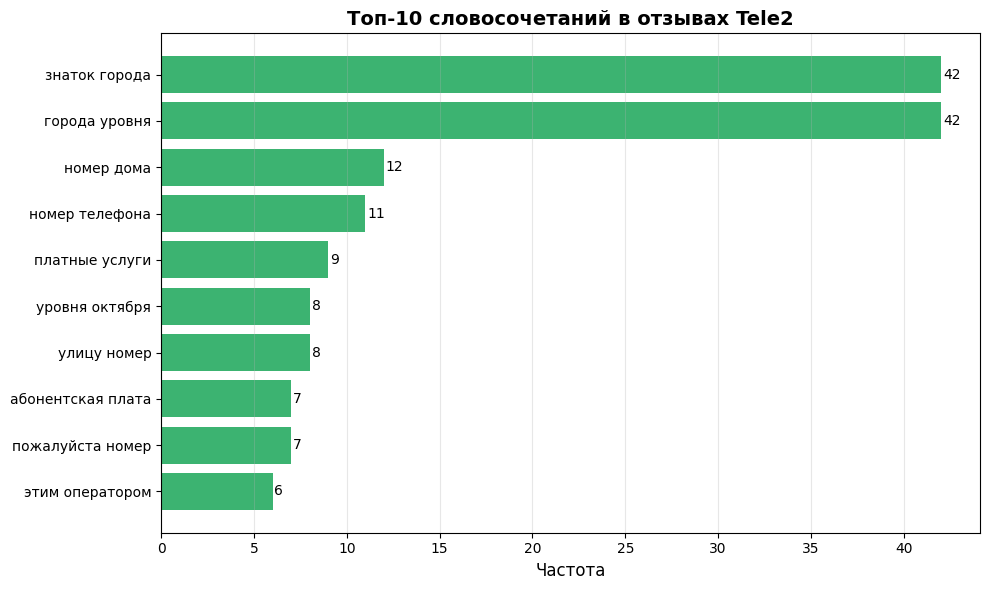

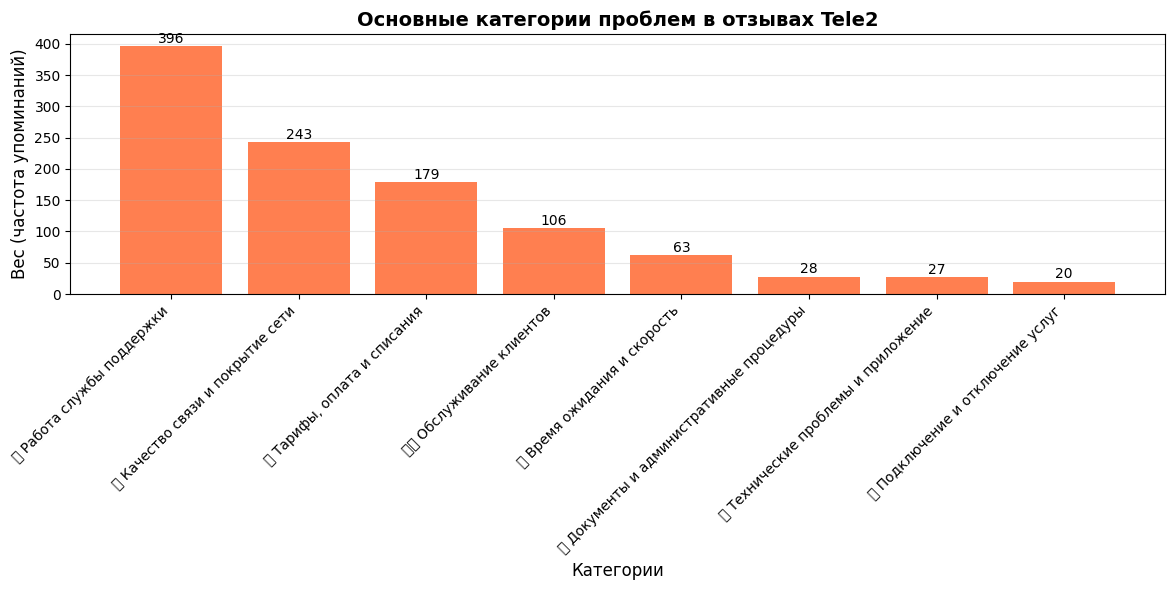


💾 ЭКСПОРТ ГРАФИКОВ

Хотите экспортировать графики в файлы? (y/n): y

Выберите тип экспорта графиков:
1. Статические графики (PNG, PDF)
2. Интерактивные графики (HTML, Plotly)
3. Все форматы

Введите номер (1-3): 3

💾 ЭКСПОРТ ГРАФИКОВ В ДИРЕКТОРИЮ: tele2_static_plots
  📊 Экспорт распределения тональности...
  ☁️ Экспорт облака слов...
  🔑 Экспорт топ ключевых слов...
  🔗 Экспорт топ словосочетаний...
  📈 Экспорт категорий проблем...
  📋 Экспорт сводного отчета...
  🌐 Создание HTML отчета...
  📄 HTML отчет создан: tele2_static_plots/tele2_analysis_report.html

✅ Все графики успешно экспортированы в папку: tele2_static_plots/

📊 СОЗДАНИЕ ИНТЕРАКТИВНЫХ ГРАФИКОВ
  📈 Создание интерактивной диаграммы тональности...


ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


In [ ]:
# ============================================================================
# 9. ФУНКЦИИ ДЛЯ ЭКСПОРТА ГРАФИКОВ
# ============================================================================

def export_plots_to_files(results, export_dir="tele2_plots"):
    """
    Экспорт всех графиков в файлы

    Параметры:
    - results: результаты анализа
    - export_dir: директория для сохранения графиков
    """
    import os
    import matplotlib.pyplot as plt

    print(f"\n💾 ЭКСПОРТ ГРАФИКОВ В ДИРЕКТОРИЮ: {export_dir}")

    # Создаем директорию, если она не существует
    if not os.path.exists(export_dir):
        os.makedirs(export_dir)
        print(f"  Создана директория: {export_dir}")

    # 1. Экспорт распределения тональности
    if 'sentiment_distribution' in results and results['sentiment_distribution']:
        print("  📊 Экспорт распределения тональности...")
        _export_sentiment_plot(results, export_dir)

    # 2. Экспорт облака слов
    if 'all_reviews_processed' in results and results['all_reviews_processed']:
        print("  ☁️ Экспорт облака слов...")
        _export_wordcloud_plot(results, export_dir)

    # 3. Экспорт топ ключевых слов
    if 'top_keywords' in results and results['top_keywords']:
        print("  🔑 Экспорт топ ключевых слов...")
        _export_top_keywords_plot(results, export_dir)

    # 4. Экспорт топ словосочетаний
    if 'top_bigrams' in results and results['top_bigrams']:
        print("  🔗 Экспорт топ словосочетаний...")
        _export_bigrams_plot(results, export_dir)

    # 5. Экспорт категорий проблем
    if 'problem_categories' in results and results['problem_categories']:
        print("  📈 Экспорт категорий проблем...")
        _export_problem_categories_plot(results, export_dir)

    # 6. Экспорт сводного отчета (один график со всеми основными метриками)
    print("  📋 Экспорт сводного отчета...")
    _export_summary_report(results, export_dir)

    # 7. Создание HTML отчета с графиками
    print("  🌐 Создание HTML отчета...")
    _create_html_report(results, export_dir)

    print(f"\n✅ Все графики успешно экспортированы в папку: {export_dir}/")

def _export_sentiment_plot(results, export_dir):
    """Экспорт графика распределения тональности"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Данные
    sentiment_counts = pd.Series(results['sentiment_distribution'])
    colors = {'NEGATIVE': '#ff6b6b', 'NEUTRAL': '#95a5a6', 'POSITIVE': '#2ecc71'}
    sentiment_colors = [colors.get(s, '#3498db') for s in sentiment_counts.index]

    # Столбчатая диаграмма
    bars = ax1.bar(sentiment_counts.index, sentiment_counts.values, color=sentiment_colors, edgecolor='black', linewidth=1)
    ax1.set_title('Распределение тональности отзывов', fontweight='bold', fontsize=14)
    ax1.set_ylabel('Количество отзывов', fontsize=12)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')

    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Круговая диаграмма
    wedges, texts, autotexts = ax2.pie(sentiment_counts.values, labels=sentiment_counts.index,
                                       autopct='%1.1f%%', colors=sentiment_colors, startangle=90,
                                       textprops={'fontsize': 11})
    ax2.set_title('Доли тональности', fontweight='bold', fontsize=14)

    # Делаем проценты жирными
    for autotext in autotexts:
        autotext.set_fontweight('bold')

    plt.suptitle(f'Анализ тональности Tele2\nВсего отзывов: {results["total_reviews"]}',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    # Сохраняем график
    plt.savefig(f'{export_dir}/sentiment_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(f'{export_dir}/sentiment_distribution.pdf', bbox_inches='tight')
    plt.close()

def _export_wordcloud_plot(results, export_dir):
    """Экспорт облака слов"""
    from wordcloud import WordCloud

    # Объединяем все тексты
    all_text = ' '.join(results['all_reviews_processed'])

    # Создаем облако слов
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        colormap='plasma',
        max_words=150,
        contour_width=2,
        contour_color='steelblue',
        font_path=None,  # Можно указать путь к шрифту для поддержки кириллицы
        collocations=True
    ).generate(all_text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Облако ключевых слов Tele2\n(без стоп-слов)', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()

    # Сохраняем график
    plt.savefig(f'{export_dir}/wordcloud.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(f'{export_dir}/wordcloud.pdf', bbox_inches='tight')
    plt.close()

def _export_top_keywords_plot(results, export_dir):
    """Экспорт графика топ ключевых слов"""
    # Подготавливаем данные
    top_keywords = results['top_keywords'][:20]  # Берем топ-20
    words = [item[0] for item in top_keywords][::-1]
    frequencies = [item[1] for item in top_keywords][::-1]

    # Создаем график
    plt.figure(figsize=(12, 8))
    bars = plt.barh(words, frequencies, color='#3498db', edgecolor='black', linewidth=0.5)

    # Настраиваем график
    plt.xlabel('Частота упоминания', fontsize=12)
    plt.title('Топ-20 ключевых слов в отзывах Tele2\n(без стоп-слов)', fontsize=16, fontweight='bold', pad=20)
    plt.grid(axis='x', alpha=0.3, linestyle='--')

    # Добавляем значения на столбцы
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
                f'{int(width)}', ha='left', va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()

    # Сохраняем график
    plt.savefig(f'{export_dir}/top_keywords.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(f'{export_dir}/top_keywords.pdf', bbox_inches='tight')
    plt.close()

def _export_bigrams_plot(results, export_dir):
    """Экспорт графика топ словосочетаний"""
    # Подготавливаем данные
    top_bigrams = results['top_bigrams'][:15]  # Берем топ-15
    bigrams = [item[0] for item in top_bigrams][::-1]
    frequencies = [item[1] for item in top_bigrams][::-1]

    # Создаем график
    plt.figure(figsize=(12, 7))
    bars = plt.barh(bigrams, frequencies, color='#2ecc71', edgecolor='black', linewidth=0.5)

    # Настраиваем график
    plt.xlabel('Частота упоминания', fontsize=12)
    plt.title('Топ-15 словосочетаний в отзывах Tele2', fontsize=16, fontweight='bold', pad=20)
    plt.grid(axis='x', alpha=0.3, linestyle='--')

    # Добавляем значения на столбцы
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
                f'{int(width)}', ha='left', va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()

    # Сохраняем график
    plt.savefig(f'{export_dir}/top_bigrams.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(f'{export_dir}/top_bigrams.pdf', bbox_inches='tight')
    plt.close()

def _export_problem_categories_plot(results, export_dir):
    """Экспорт графика категорий проблем"""
    # Подготавливаем данные
    categories = results['problem_categories'][:10]  # Берем топ-10
    category_names = [cat['category'] for cat in categories]
    category_weights = [cat['weight'] for cat in categories]

    # Цветовая схема для категорий
    colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#1abc9c',
              '#3498db', '#9b59b6', '#34495e', '#e84393', '#00cec9']

    # Создаем график
    fig, ax = plt.subplots(figsize=(14, 8))
    bars = ax.barh(category_names[::-1], category_weights[::-1],
                   color=colors[:len(categories)][::-1], edgecolor='black', linewidth=0.5)

    # Настраиваем график
    ax.set_xlabel('Количество упоминаний (вес)', fontsize=12)
    ax.set_title('Топ-10 категорий проблем в отзывах Tele2', fontsize=16, fontweight='bold', pad=20)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    # Добавляем значения на столбцы
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.1, bar.get_y() + bar.get_height()/2,
                f'{int(width)}', ha='left', va='center', fontsize=10, fontweight='bold')

    # Добавляем легенду с ключевыми словами
    if len(categories) > 0:
        legend_text = "\n".join([f"• {cat['category']}: {', '.join(cat['keywords'][:3])}"
                                for cat in categories[:5]])
        ax.text(0.02, 0.98, f"Ключевые слова топ-5 категорий:\n{legend_text}",
                transform=ax.transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()

    # Сохраняем график
    plt.savefig(f'{export_dir}/problem_categories.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(f'{export_dir}/problem_categories.pdf', bbox_inches='tight')
    plt.close()

def _export_summary_report(results, export_dir):
    """Экспорт сводного отчета с основными метриками"""
    # Создаем фигуру с несколькими subplots
    fig = plt.figure(figsize=(16, 12))

    # Общий заголовок
    fig.suptitle('СВОДНЫЙ ОТЧЕТ ПО АНАЛИЗУ ОТЗЫВОВ TELE2',
                 fontsize=18, fontweight='bold', y=0.98)

    # 1. Распределение тональности (левый верхний)
    ax1 = plt.subplot(2, 2, 1)
    if 'sentiment_distribution' in results:
        sentiment_counts = pd.Series(results['sentiment_distribution'])
        colors = {'NEGATIVE': '#ff6b6b', 'NEUTRAL': '#95a5a6', 'POSITIVE': '#2ecc71'}
        sentiment_colors = [colors.get(s, '#3498db') for s in sentiment_counts.index]

        bars = ax1.bar(sentiment_counts.index, sentiment_counts.values, color=sentiment_colors)
        ax1.set_title('Распределение тональности', fontweight='bold')
        ax1.set_ylabel('Количество отзывов')
        ax1.grid(axis='y', alpha=0.3)

        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{int(height)}', ha='center', va='bottom')

    # 2. Ключевые слова (правый верхний)
    ax2 = plt.subplot(2, 2, 2)
    if 'top_keywords' in results and results['top_keywords']:
        top_keywords = results['top_keywords'][:8]
        words = [item[0] for item in top_keywords][::-1]
        frequencies = [item[1] for item in top_keywords][::-1]

        bars = ax2.barh(words, frequencies, color='steelblue')
        ax2.set_title('Топ-8 ключевых слов', fontweight='bold')
        ax2.set_xlabel('Частота')

    # 3. Категории проблем (левый нижний)
    ax3 = plt.subplot(2, 2, 3)
    if 'problem_categories' in results and results['problem_categories']:
        categories = results['problem_categories'][:6]
        category_names = [cat['category'] for cat in categories]
        category_weights = [cat['weight'] for cat in categories]

        bars = ax3.bar(category_names, category_weights, color='coral')
        ax3.set_title('Топ-6 категорий проблем', fontweight='bold')
        ax3.set_ylabel('Вес (упоминания)')
        plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)

        for bar in bars:
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{int(height)}', ha='center', va='bottom', fontsize=8)

    # 4. Текстовый блок с метриками (правый нижний)
    ax4 = plt.subplot(2, 2, 4)
    ax4.axis('off')  # Отключаем оси

    # Формируем текст с метриками
    metrics_text = f"""
    📊 ОСНОВНЫЕ МЕТРИКИ:

    • Всего отзывов: {results['total_reviews']}
    • Негативных отзывов: {results['negative_reviews']}
    • Доля негативных: {results['negative_reviews']/results['total_reviews']*100:.1f}%

    🔑 КЛЮЧЕВЫЕ СВОДКИ:

    • Категорий проблем: {len(results.get('problem_categories', []))}
    • Топ-3 проблемы:
    """

    if 'problem_categories' in results and results['problem_categories']:
        for i, cat in enumerate(results['problem_categories'][:3], 1):
            metrics_text += f"\n    {i}. {cat['category']}"

    metrics_text += f"""

    📈 РЕКОМЕНДАЦИИ:

    • Приоритет: улучшить обработку негативных отзывов
    • Фокус: ключевые проблемные категории
    • Мониторинг: регулярный анализ тональности
    """

    ax4.text(0.05, 0.95, metrics_text, transform=ax4.transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Учитываем suptitle

    # Сохраняем график
    plt.savefig(f'{export_dir}/summary_report.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(f'{export_dir}/summary_report.pdf', bbox_inches='tight')
    plt.close()

def _create_html_report(results, export_dir):
    """Создание HTML отчета с графиками"""
    html_content = f"""
<!DOCTYPE html>
<html lang="ru">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Анализ отзывов Tele2</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            line-height: 1.6;
            margin: 0;
            padding: 20px;
            background-color: #f5f5f5;
        }}
        .container {{
            max-width: 1200px;
            margin: 0 auto;
            background-color: white;
            padding: 30px;
            border-radius: 10px;
            box-shadow: 0 0 20px rgba(0,0,0,0.1);
        }}
        .header {{
            text-align: center;
            margin-bottom: 30px;
            border-bottom: 2px solid #3498db;
            padding-bottom: 20px;
        }}
        .header h1 {{
            color: #2c3e50;
            margin-bottom: 10px;
        }}
        .metrics {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(250px, 1fr));
            gap: 20px;
            margin-bottom: 30px;
        }}
        .metric-card {{
            background-color: #f8f9fa;
            padding: 20px;
            border-radius: 8px;
            border-left: 4px solid #3498db;
            box-shadow: 0 2px 5px rgba(0,0,0,0.1);
        }}
        .metric-card h3 {{
            margin-top: 0;
            color: #2c3e50;
        }}
        .metric-value {{
            font-size: 24px;
            font-weight: bold;
            color: #3498db;
        }}
        .plot-section {{
            margin-bottom: 40px;
        }}
        .plot-section h2 {{
            color: #2c3e50;
            border-bottom: 1px solid #eee;
            padding-bottom: 10px;
        }}
        .plot-grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(500px, 1fr));
            gap: 20px;
        }}
        .plot-item {{
            text-align: center;
        }}
        .plot-item img {{
            max-width: 100%;
            height: auto;
            border-radius: 8px;
            box-shadow: 0 3px 10px rgba(0,0,0,0.1);
            transition: transform 0.3s;
        }}
        .plot-item img:hover {{
            transform: scale(1.02);
        }}
        .plot-item p {{
            margin-top: 10px;
            font-style: italic;
            color: #666;
        }}
        .problems-list {{
            background-color: #f8f9fa;
            padding: 20px;
            border-radius: 8px;
            margin-bottom: 20px;
        }}
        .problem-item {{
            padding: 10px;
            margin-bottom: 10px;
            background-color: white;
            border-radius: 5px;
            border-left: 3px solid #e74c3c;
        }}
        .footer {{
            text-align: center;
            margin-top: 40px;
            padding-top: 20px;
            border-top: 1px solid #eee;
            color: #666;
            font-size: 14px;
        }}
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h1>📊 Анализ отзывов Tele2</h1>
            <p>Полный отчет по анализу отзывов клиентов</p>
            <p><strong>Дата генерации:</strong> {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}</p>
        </div>

        <div class="metrics">
            <div class="metric-card">
                <h3>Всего отзывов</h3>
                <div class="metric-value">{results['total_reviews']}</div>
            </div>
            <div class="metric-card">
                <h3>Негативных отзывов</h3>
                <div class="metric-value">{results['negative_reviews']}</div>
                <p>{results['negative_reviews']/results['total_reviews']*100:.1f}% от общего числа</p>
            </div>
            <div class="metric-card">
                <h3>Категорий проблем</h3>
                <div class="metric-value">{len(results.get('problem_categories', []))}</div>
            </div>
            <div class="metric-card">
                <h3>Топ ключевых слов</h3>
                <div class="metric-value">{len(results.get('top_keywords', []))}</div>
            </div>
        </div>

        <div class="plot-section">
            <h2>📈 Основные графики</h2>
            <div class="plot-grid">
                <div class="plot-item">
                    <img src="sentiment_distribution.png" alt="Распределение тональности">
                    <p>Распределение тональности отзывов</p>
                </div>
                <div class="plot-item">
                    <img src="summary_report.png" alt="Сводный отчет">
                    <p>Сводный отчет по анализу</p>
                </div>
                <div class="plot-item">
                    <img src="problem_categories.png" alt="Категории проблем">
                    <p>Категории проблем</p>
                </div>
                <div class="plot-item">
                    <img src="top_keywords.png" alt="Ключевые слова">
                    <p>Ключевые слова</p>
                </div>
                <div class="plot-item">
                    <img src="top_bigrams.png" alt="Словосочетания">
                    <p>Топ словосочетаний</p>
                </div>
                <div class="plot-item">
                    <img src="wordcloud.png" alt="Облако слов">
                    <p>Облако ключевых слов</p>
                </div>
            </div>
        </div>

        <div class="plot-section">
            <h2>🚨 Основные проблемы</h2>
            <div class="problems-list">
    """

    # Добавляем список проблем
    if 'problem_categories' in results and results['problem_categories']:
        for i, category in enumerate(results['problem_categories'][:5], 1):
            html_content += f"""
                <div class="problem-item">
                    <h3>{i}. {category['category']}</h3>
                    <p><strong>Вес проблемы:</strong> {category['weight']} упоминаний</p>
                    <p><strong>Ключевые слова:</strong> {', '.join(category['keywords'][:5])}</p>
            """
            if category['examples']:
                html_content += f"<p><strong>Пример:</strong> {category['examples'][0]}</p>"
            html_content += "</div>"

    html_content += f"""
            </div>
        </div>

        <div class="plot-section">
            <h2>🔑 Топ ключевых слов</h2>
            <div style="background-color: #f8f9fa; padding: 20px; border-radius: 8px;">
                <h3>Топ-10 ключевых слов:</h3>
                <ul>
    """

    # Добавляем топ ключевых слов
    if 'top_keywords' in results and results['top_keywords']:
        for i, (word, freq) in enumerate(results['top_keywords'][:10], 1):
            html_content += f"<li><strong>{word}</strong> - {freq} упоминаний</li>"

    html_content += f"""
                </ul>
            </div>
        </div>

        <div class="footer">
            <p>Сгенерировано автоматически системой анализа отзывов Tele2</p>
            <p>Все графики доступны для скачивания в форматах PNG и PDF</p>
        </div>
    </div>
</body>
</html>
    """

    # Сохраняем HTML файл
    html_file_path = f'{export_dir}/tele2_analysis_report.html'
    with open(html_file_path, 'w', encoding='utf-8') as f:
        f.write(html_content)

    print(f"  📄 HTML отчет создан: {html_file_path}")

def export_all_visualizations_interactive(results, export_dir="tele2_interactive_plots"):
    """
    Создание интерактивных графиков с использованием Plotly
    (требует установки plotly: pip install plotly)
    """
    try:
        import plotly.graph_objects as go
        import plotly.express as px
        from plotly.subplots import make_subplots

        print(f"\n📊 СОЗДАНИЕ ИНТЕРАКТИВНЫХ ГРАФИКОВ")

        # Создаем директорию
        if not os.path.exists(export_dir):
            os.makedirs(export_dir)

        # 1. Интерактивная круговая диаграмма тональности
        if 'sentiment_distribution' in results:
            print("  📈 Создание интерактивной диаграммы тональности...")
            _create_interactive_sentiment_chart(results, export_dir)

        # 2. Интерактивный график ключевых слов
        if 'top_keywords' in results:
            print("  🔤 Создание интерактивного графика ключевых слов...")
            _create_interactive_keywords_chart(results, export_dir)

        # 3. Интерактивный график категорий проблем
        if 'problem_categories' in results:
            print("  🎯 Создание интерактивного графика проблем...")
            _create_interactive_problems_chart(results, export_dir)

        # 4. Создание дашборда
        print("  📋 Создание интерактивного дашборда...")
        _create_interactive_dashboard(results, export_dir)

        print(f"\n✅ Интерактивные графики созданы в папке: {export_dir}/")

    except ImportError:
        print("  ⚠️ Plotly не установлен. Для интерактивных графиков установите: pip install plotly")
        print("  📊 Используются статические графики вместо интерактивных")

def _create_interactive_sentiment_chart(results, export_dir):
    """Создание интерактивной диаграммы тональности с Plotly"""
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    sentiment_counts = pd.Series(results['sentiment_distribution'])
    colors = {'NEGATIVE': '#ff6b6b', 'NEUTRAL': '#95a5a6', 'POSITIVE': '#2ecc71'}

    # Создаем subplots
    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{"type": "bar"}, {"type": "pie"}]],
        subplot_titles=("Распределение тональности", "Доли тональности")
    )

    # Столбчатая диаграмма
    fig.add_trace(
        go.Bar(
            x=sentiment_counts.index,
            y=sentiment_counts.values,
            marker_color=[colors.get(s, '#3498db') for s in sentiment_counts.index],
            text=sentiment_counts.values,
            textposition='auto',
            name="Количество"
        ),
        row=1, col=1
    )

    # Круговая диаграмма
    fig.add_trace(
        go.Pie(
            labels=sentiment_counts.index,
            values=sentiment_counts.values,
            marker_colors=[colors.get(s, '#3498db') for s in sentiment_counts.index],
            hole=0.3,
            textinfo='label+percent',
            name="Доли"
        ),
        row=1, col=2
    )

    # Обновляем layout
    fig.update_layout(
        title_text=f"Анализ тональности Tele2<br><sup>Всего отзывов: {results['total_reviews']}</sup>",
        title_font_size=20,
        showlegend=True,
        height=500
    )

    fig.update_xaxes(title_text="Тональность", row=1, col=1)
    fig.update_yaxes(title_text="Количество отзывов", row=1, col=1)

    # Сохраняем как HTML (интерактивный)
    fig.write_html(f"{export_dir}/interactive_sentiment.html")
    # Также сохраняем как PNG
    fig.write_image(f"{export_dir}/interactive_sentiment.png", width=1200, height=600)

def _create_interactive_keywords_chart(results, export_dir):
    """Создание интерактивного графика ключевых слов"""
    import plotly.express as px

    # Подготавливаем данные
    top_keywords = results['top_keywords'][:20]
    df_keywords = pd.DataFrame(top_keywords, columns=['word', 'freq'])

    # Создаем интерактивный барчарт
    fig = px.bar(
        df_keywords,
        y='word',
        x='freq',
        orientation='h',
        title='Топ-20 ключевых слов в отзывах Tele2',
        labels={'word': 'Слово', 'freq': 'Частота'},
        color='freq',
        color_continuous_scale='Viridis'
    )

    fig.update_layout(
        yaxis={'categoryorder': 'total ascending'},
        height=600,
        xaxis_title="Частота упоминания",
        yaxis_title="",
        title_font_size=18
    )

    # Добавляем hover информацию
    fig.update_traces(
        hovertemplate="<b>%{y}</b><br>Частота: %{x}<extra></extra>"
    )

    # Сохраняем
    fig.write_html(f"{export_dir}/interactive_keywords.html")
    fig.write_image(f"{export_dir}/interactive_keywords.png", width=1000, height=600)

def _create_interactive_problems_chart(results, export_dir):
    """Создание интерактивного графика проблем"""
    import plotly.graph_objects as go

    # Подготавливаем данные
    categories = results['problem_categories'][:10]
    category_names = [cat['category'] for cat in categories]
    category_weights = [cat['weight'] for cat in categories]

    # Создаем график
    fig = go.Figure(data=[
        go.Bar(
            x=category_weights,
            y=category_names,
            orientation='h',
            marker_color='coral',
            text=category_weights,
            textposition='auto',
            hovertemplate='<b>%{y}</b><br>Вес: %{x}<extra></extra>'
        )
    ])

    fig.update_layout(
        title='Топ-10 категорий проблем в отзывах Tele2',
        xaxis_title="Количество упоминаний (вес)",
        yaxis_title="",
        height=500,
        yaxis={'categoryorder': 'total ascending'},
        title_font_size=18
    )

    # Сохраняем
    fig.write_html(f"{export_dir}/interactive_problems.html")
    fig.write_image(f"{export_dir}/interactive_problems.png", width=1000, height=500)

def _create_interactive_dashboard(results, export_dir):
    """Создание интерактивного дашборда"""
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    # Создаем дашборд с 4 графиками
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            'Распределение тональности',
            'Топ ключевых слов',
            'Категории проблем',
            'Сводные метрики'
        ),
        specs=[
            [{"type": "pie"}, {"type": "bar"}],
            [{"type": "bar"}, {"type": "domain"}]
        ]
    )

    # 1. Круговая диаграмма тональности
    sentiment_counts = pd.Series(results['sentiment_distribution'])
    fig.add_trace(
        go.Pie(
            labels=sentiment_counts.index,
            values=sentiment_counts.values,
            hole=0.4,
            marker_colors=['#ff6b6b', '#95a5a6', '#2ecc71'],
            name="Тональность"
        ),
        row=1, col=1
    )

    # 2. Топ ключевых слов
    top_keywords = results['top_keywords'][:10]
    words = [item[0] for item in top_keywords][::-1]
    frequencies = [item[1] for item in top_keywords][::-1]

    fig.add_trace(
        go.Bar(
            x=frequencies,
            y=words,
            orientation='h',
            marker_color='steelblue',
            name="Ключевые слова"
        ),
        row=1, col=2
    )

    # 3. Категории проблем
    categories = results['problem_categories'][:6]
    category_names = [cat['category'] for cat in categories]
    category_weights = [cat['weight'] for cat in categories]

    fig.add_trace(
        go.Bar(
            x=category_names,
            y=category_weights,
            marker_color='coral',
            name="Проблемы"
        ),
        row=2, col=1
    )

    # 4. Сводные метрики (текстовый блок)
    metrics_text = f"""
    Всего отзывов: {results['total_reviews']}<br>
    Негативных: {results['negative_reviews']}<br>
    Доля негативных: {results['negative_reviews']/results['total_reviews']*100:.1f}%<br>
    Категорий проблем: {len(results.get('problem_categories', []))}<br>
    Топ-3 проблемы:<br>
    """

    if 'problem_categories' in results and results['problem_categories']:
        for i, cat in enumerate(results['problem_categories'][:3], 1):
            metrics_text += f"{i}. {cat['category']}<br>"

    fig.add_trace(
        go.Scatter(
            x=[0, 1],
            y=[0, 1],
            mode='text',
            text=[metrics_text],
            textposition="middle center",
            showlegend=False,
            hoverinfo='skip'
        ),
        row=2, col=2
    )

    # Обновляем layout
    fig.update_layout(
        title_text=f"📊 ДАШБОРД АНАЛИЗА TELE2<br><sup>Дата: {pd.Timestamp.now().strftime('%Y-%m-%d')}</sup>",
        title_font_size=20,
        showlegend=False,
        height=800
    )

    # Настраиваем оси
    fig.update_xaxes(title_text="Частота", row=1, col=2)
    fig.update_xaxes(title_text="Категории", row=2, col=1)
    fig.update_yaxes(title_text="", row=1, col=2)
    fig.update_yaxes(title_text="Вес", row=2, col=1)

    # Скрываем оси для текстового блока
    fig.update_xaxes(showgrid=False, zeroline=False, showticklabels=False, row=2, col=2)
    fig.update_yaxes(showgrid=False, zeroline=False, showticklabels=False, row=2, col=2)

    # Сохраняем
    fig.write_html(f"{export_dir}/interactive_dashboard.html")
    fig.write_image(f"{export_dir}/interactive_dashboard.png", width=1400, height=800)

# ============================================================================
# 10. ИНТЕГРАЦИЯ С ОСНОВНЫМ КОДОМ
# ============================================================================

def main_with_export():
    """
    Главная функция с возможностью экспорта графиков
    """
    print("="*80)
    print("📊 АНАЛИЗАТОР ОТЗЫВОВ TELE2 (С ЭКСПОРТОМ ГРАФИКОВ)")
    print("="*80)

    # Путь к файлу
    file_path = "Tele2_reviews.csv"

    if not os.path.exists(file_path):
        print(f"❌ Файл не найден: {file_path}")
        return

    # Запуск анализа
    print("\n🚀 Запуск комплексного анализа...")
    results = run_comprehensive_analysis(file_path, max_reviews=None)

    if results is None:
        print("❌ Анализ не удался")
        return

    # Показать графики на экране
    print("\n📊 Отображение графиков на экране...")
    visualize_all_results(results)

    # Экспорт графиков
    print("\n" + "="*80)
    print("💾 ЭКСПОРТ ГРАФИКОВ")
    print("="*80)

    export_choice = input("\nХотите экспортировать графики в файлы? (y/n): ").strip().lower()

    if export_choice == 'y':
        # Выбор типа экспорта
        print("\nВыберите тип экспорта графиков:")
        print("1. Статические графики (PNG, PDF)")
        print("2. Интерактивные графики (HTML, Plotly)")
        print("3. Все форматы")

        try:
            export_type = int(input("\nВведите номер (1-3): ").strip())
        except:
            export_type = 1

        if export_type == 1:
            # Только статические графики
            export_plots_to_files(results, "tele2_static_plots")

        elif export_type == 2:
            # Только интерактивные графики (требует plotly)
            export_all_visualizations_interactive(results, "tele2_interactive_plots")

        elif export_type == 3:
            # Все форматы
            export_plots_to_files(results, "tele2_static_plots")
            export_all_visualizations_interactive(results, "tele2_interactive_plots")

            # Создаем README файл
            _create_readme_file(results, "tele2_plots_README.txt")

        print("\n✅ Экспорт графиков завершен!")

    # Экспорт данных в Excel
    print("\n" + "="*80)
    print("📤 ЭКСПОРТ ДАННЫХ В EXCEL")
    print("="*80)

    excel_choice = input("\nХотите экспортировать данные в Excel? (y/n): ").strip().lower()

    if excel_choice == 'y':
        export_results_to_excel(results)

    # Детальный отчет
    print("\n" + "="*80)
    print("📋 ДЕТАЛЬНЫЙ ОТЧЕТ")
    print("="*80)

    print_detailed_report(results)

def _create_readme_file(results, filename="README.txt"):
    """Создание README файла с описанием экспортированных графиков"""
    readme_content = f"""
Анализ отзывов Tele2 - Экспортированные графики
================================================

Дата генерации: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}

📊 ОСНОВНЫЕ МЕТРИКИ:
• Всего отзывов: {results['total_reviews']}
• Негативных отзывов: {results['negative_reviews']}
• Доля негативных: {results['negative_reviews']/results['total_reviews']*100:.1f}%


🔑 ТОП-5 КЛЮЧЕВЫХ СЛОВ:
"""

    if 'top_keywords' in results and results['top_keywords']:
        for i, (word, freq) in enumerate(results['top_keywords'][:5], 1):
            readme_content += f"{i}. {word} - {freq}\n"

    readme_content += f"""
🚨 ТОП-3 КАТЕГОРИИ ПРОБЛЕМ:
"""

    if 'problem_categories' in results and results['problem_categories']:
        for i, cat in enumerate(results['problem_categories'][:3], 1):
            readme_content += f"{i}. {cat['category']} (вес: {cat['weight']})\n"

    readme_content += f"""
📋 РЕКОМЕНДАЦИИ ПО ИСПОЛЬЗОВАНИЮ:
1. PNG файлы - для презентаций и документов
2. PDF файлы - для печати и публикаций
3. HTML файлы - для веб-страниц и интерактивного просмотра
4. Excel файлы - для дальнейшего анализа данных

Сгенерировано системой анализа отзывов Tele2
"""

    with open(filename, 'w', encoding='utf-8') as f:
        f.write(readme_content)

    print(f"📄 README файл создан: {filename}")

# ============================================================================
# 11. БЫСТРЫЙ ЭКСПОРТ (ОТДЕЛЬНАЯ ФУНКЦИЯ)
# ============================================================================

def export_plots_quick(results, base_dir="tele2_analysis_results"):
    """
    Быстрый экспорт всех графиков в одну папку
    """
    import os

    print(f"\n🚀 БЫСТРЫЙ ЭКСПОРТ ВСЕХ ГРАФИКОВ")

    # Создаем основную папку
    if not os.path.exists(base_dir):
        os.makedirs(base_dir)

    # Папки для разных типов графиков
    static_dir = f"{base_dir}/static_plots"
    interactive_dir = f"{base_dir}/interactive_plots"

    # Экспортируем статические графики
    print("  📊 Экспорт статических графиков...")
    export_plots_to_files(results, static_dir)

    # Пробуем экспортировать интерактивные графики
    print("  📈 Экспорт интерактивных графиков...")
    try:
        export_all_visualizations_interactive(results, interactive_dir)
    except Exception as e:
        print(f"  ⚠️ Интерактивные графики не экспортированы: {e}")

    # Создаем индексный файл
    _create_index_file(results, base_dir)

    print(f"\n✅ Все графики экспортированы в папку: {base_dir}/")
    print(f"   📁 Статические графики: {static_dir}/")
    print(f"   📈 Интерактивные графики: {interactive_dir}/")

def _create_index_file(results, base_dir):
    """Создание индексного HTML файла"""
    index_html = f"""
<!DOCTYPE html>
<html lang="ru">
<head>
    <meta charset="UTF-8">
    <title>Результаты анализа Tele2</title>
    <style>
        body {{ font-family: Arial; margin: 40px; background: #f5f5f5; }}
        .container {{ max-width: 800px; margin: auto; background: white; padding: 30px; border-radius: 10px; }}
        h1 {{ color: #2c3e50; }}
        .section {{ margin: 30px 0; }}
        .link {{ display: block; padding: 10px; background: #3498db; color: white;
                text-decoration: none; margin: 10px 0; border-radius: 5px; }}
        .link:hover {{ background: #2980b9; }}
        .stats {{ background: #ecf0f1; padding: 15px; border-radius: 5px; }}
    </style>
</head>
<body>
    <div class="container">
        <h1>📊 Результаты анализа отзывов Tele2</h1>
        <p><strong>Дата:</strong> {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}</p>

        <div class="section stats">
            <h3>📈 Основные метрики</h3>
            <p>Всего отзывов: {results['total_reviews']}</p>
            <p>Негативных отзывов: {results['negative_reviews']} ({results['negative_reviews']/results['total_reviews']*100:.1f}%)</p>
        </div>

        <div class="section">
            <h3>📁 Экспортированные файлы</h3>
            <a href="static_plots/tele2_analysis_report.html" class="link">
                📋 HTML отчет (статический)
            </a>
            <a href="static_plots/" class="link">
                📊 Статические графики (PNG/PDF)
            </a>
            <a href="interactive_plots/" class="link">
                📈 Интерактивные графики (HTML)
            </a>
        </div>
    </div>
</body>
</html>
"""

    with open(f"{base_dir}/index.html", "w", encoding="utf-8") as f:
        f.write(index_html)

# ============================================================================
# ЗАПУСК ПРОГРАММЫ С ЭКСПОРТОМ
# ============================================================================

if __name__ == "__main__":
    # Проверяем наличие необходимых библиотек для экспорта
    required_libs = ['matplotlib', 'pandas', 'numpy', 'wordcloud']
    missing_libs = []

    for lib in required_libs:
        try:
            __import__(lib)
        except ImportError:
            missing_libs.append(lib)

    if missing_libs:
        print(f"⚠️ Отсутствуют библиотеки: {', '.join(missing_libs)}")
        print("Установите их командой:")
        print(f"pip install {' '.join(missing_libs)}")

    # Запускаем программу
    main_with_export()

In [ ]:
!pip install -U kaleido

📊 АНАЛИЗАТОР ОТЗЫВОВ TELE2 (СТРУКТУРИРОВАННЫЕ ДАННЫЕ)
📁 Файл для анализа: /content/tele2_reviews (1).csv

Выберите режим анализа:
1. Полный анализ (рекомендуется)
2. Быстрый анализ (ограниченное количество отзывов)
3. Только экспорт существующих результатов

Введите номер (1-3): 1

🚀 ЗАПУСК ПОЛНОГО АНАЛИЗА
🚀 КОМПЛЕКСНЫЙ АНАЛИЗ ОТЗЫВОВ TELE2

📋 ШАГ 1: ЧТЕНИЕ ФАЙЛА
📖 Чтение структурированного CSV файла: /content/tele2_reviews (1).csv
  Пробуем кодировку: utf-8
  Успешно! Прочитано строк: 33014
  Колонки в файле: ['Дата', 'Оценка', 'Отзыв', 'Имя', 'Ответ разработчика', 'Версия приложения']
  Найдена колонка 'Отзыв' → 'review'
  Найдена колонка 'Оценка' → 'rating'
  Найдена колонка 'Дата' → 'date'
  Найдена колонка 'Имя' → 'name'
  Найдена колонка 'Ответ разработчика' → 'developer_response'
  Найдена колонка 'Версия приложения' → 'app_version'

  Примеры первых 3 отзывов:
    1: То, как трагик в тоске, то, как в танце веселом - кинто, С одиночеством сердце мое слишком долго бор...
    2: п

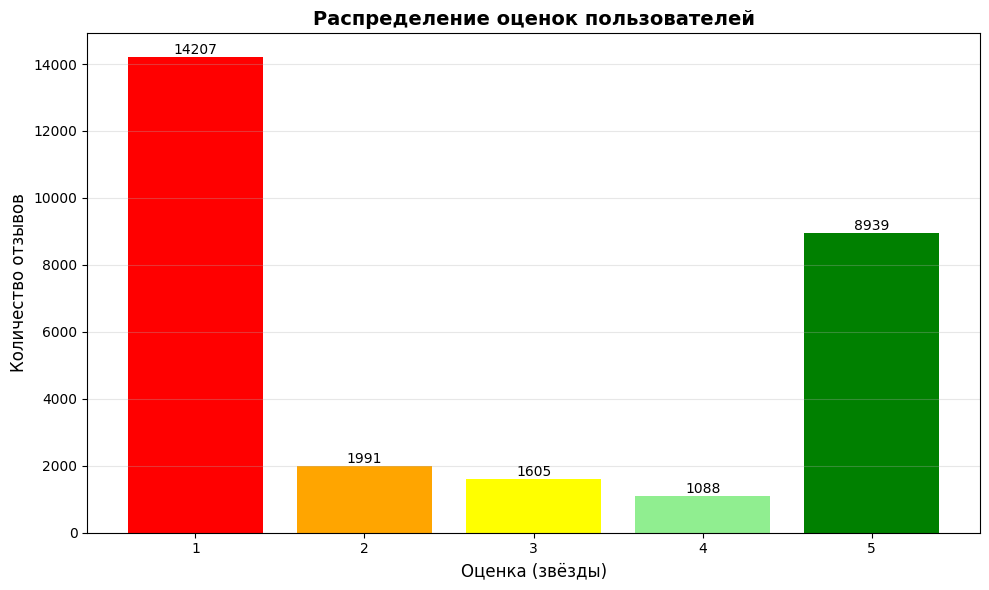

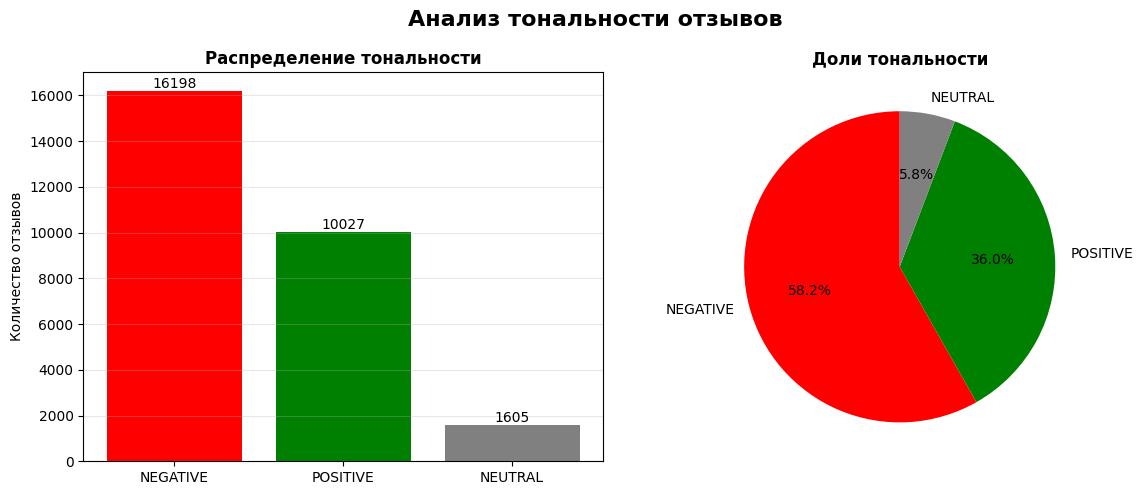


🔍 ШАГ 5: АНАЛИЗ НЕГАТИВНЫХ ОТЗЫВОВ
✅ Негативных отзывов: 16198

🔑 ШАГ 6: АНАЛИЗ КЛЮЧЕВЫХ СЛОВ
🔍 Извлечение ключевых фраз с помощью TF-IDF...
📊 Частотный анализ ключевых слов...

📈 ШАГ 7: КАТЕГОРИЗАЦИЯ ПРОБЛЕМ
📈 Категоризация проблем...

📅 ШАГ 8: АНАЛИЗ ВРЕМЕННЫХ ТРЕНДОВ
📅 Анализ временных трендов...


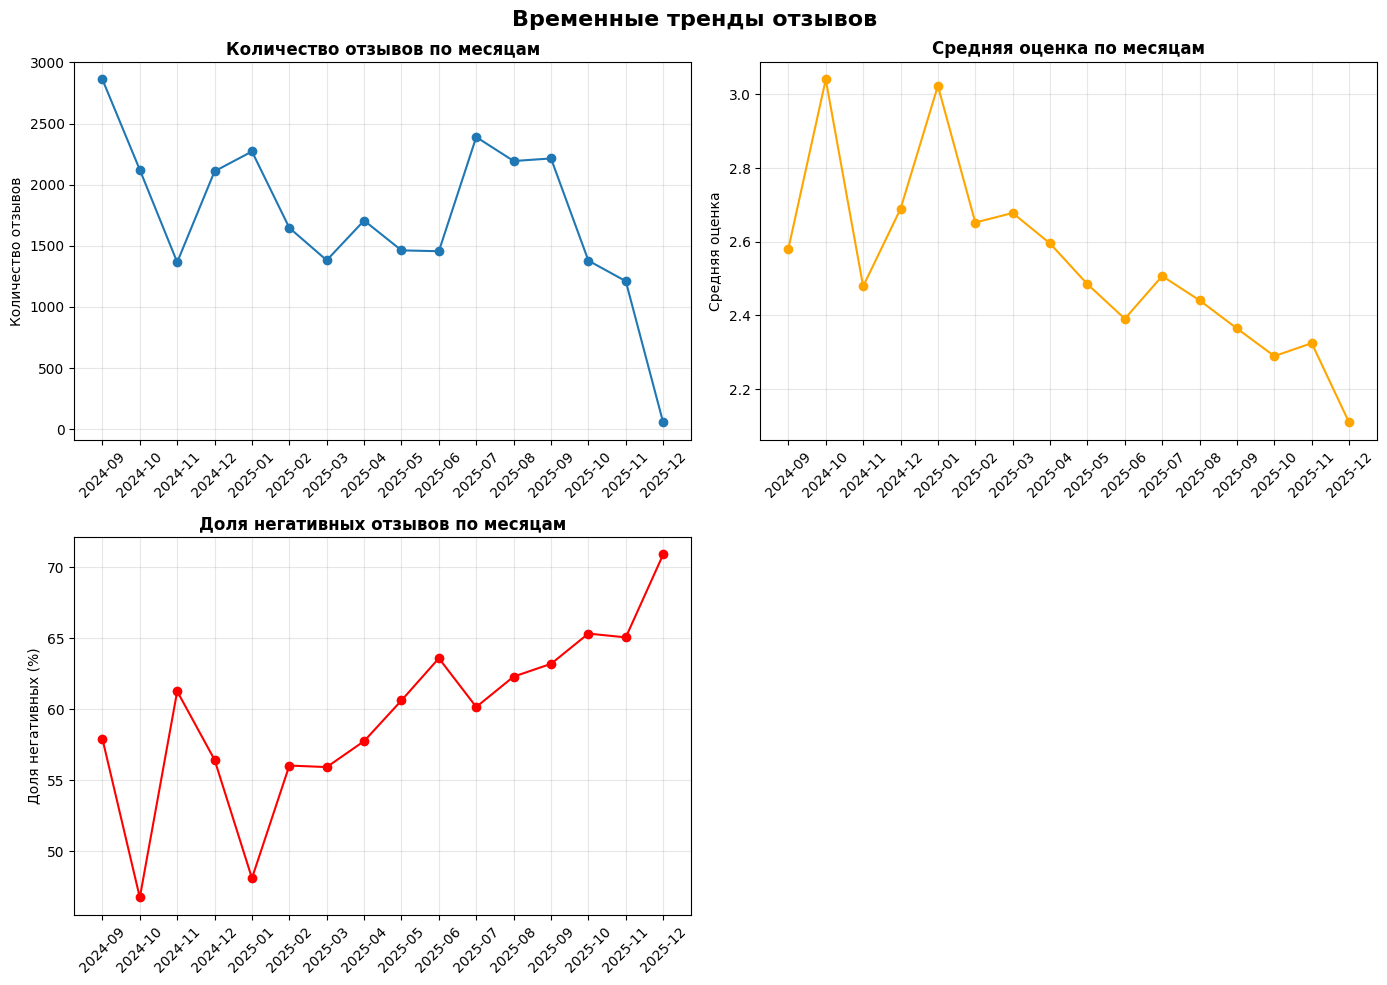


💾 ШАГ 9: ФОРМИРОВАНИЕ РЕЗУЛЬТАТОВ

📤 Экспортировать результаты? (y/n): y

💾 ЭКСПОРТ РЕЗУЛЬТАТОВ В ПАПКУ: tele2_analysis_results
  Создана директория: tele2_analysis_results
  📊 Экспорт данных в Excel...
    ✅ Excel файл создан: tele2_analysis_results/tele2_analysis.xlsx
  📈 Экспорт графиков...
    ✅ Графики экспортированы в папку: tele2_analysis_results
  📋 Экспорт текстовых отчетов...
    ✅ Текстовые отчеты созданы

✅ Все результаты экспортированы в папку: tele2_analysis_results

📋 СВОДКА РЕЗУЛЬТАТОВ

📊 ОСНОВНЫЕ МЕТРИКИ:
  • Всего отзывов: 27830
  • Негативных отзывов: 16198
  • Доля негативных: 58.2%
  • Средняя оценка: 2.59/5

🔑 ТОП-5 КЛЮЧЕВЫХ СЛОВ:
  1. интернет (4086 упоминаний)
  2. приложение (3400 упоминаний)
  3. связь (2188 упоминаний)
  4. работает (2164 упоминаний)
  5. тариф (1795 упоминаний)

🚨 ОСНОВНЫЕ КАТЕГОРИИ ПРОБЛЕМ:
  1. 📶 Качество связи и покрытие (17268 упоминаний)
  2. 💰 Тарифы и оплата (10446 упоминаний)
  3. 📱 Технические проблемы (7281 упоминаний)

💡 РЕКОМЕНД

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import os
from datetime import datetime
from wordcloud import WordCloud

# ============================================================================
# 1. НАСТРОЙКИ И ПАРАМЕТРЫ
# ============================================================================

# Расширенный список русских стоп-слов
RUSSIAN_STOPWORDS = {
    'и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'все',
    'она', 'так', 'его', 'но', 'да', 'ты', 'к', 'у', 'же', 'вы', 'за', 'бы', 'по',
    'только', 'ее', 'мне', 'было', 'вот', 'от', 'меня', 'еще', 'нет', 'о', 'из', 'ему',
    'теперь', 'когда', 'даже', 'ну', 'ли', 'если', 'уже', 'или', 'ни', 'быть', 'был',
    'него', 'до', 'вас', 'нибудь', 'уж', 'вам', 'сказал', 'ведь', 'там', 'потом', 'себя',
    'ничего', 'ей', 'может', 'они', 'тут', 'где', 'есть', 'надо', 'ней', 'для', 'мы',
    'тебя', 'их', 'чем', 'была', 'сам', 'чтоб', 'без', 'будто', 'чего', 'раз', 'тоже',
    'себе', 'под', 'будет', 'ж', 'тогда', 'кто', 'этот', 'того', 'потому', 'этого',
    'какой', 'совсем', 'ним', 'здесь', 'этом', 'один', 'почти', 'мой', 'тем', 'чтобы',
    'нее', 'сейчас', 'были', 'куда', 'зачем', 'всех', 'никогда', 'можно', 'при', 'наконец',
    'два', 'об', 'другой', 'хоть', 'после', 'над', 'больше', 'тот', 'через', 'эти',
    'нас', 'про', 'всего', 'них', 'какая', 'много', 'разве', 'три', 'эту', 'моя',
    'впрочем', 'хорошо', 'свою', 'этой', 'перед', 'иногда', 'лучше', 'чуть', 'том',
    'нельзя', 'такой', 'им', 'более', 'всегда', 'конечно', 'всю', 'между', 'это',
    'также', 'теле2', 'tele2', 'оператор', 'компания', 'фирма', 'организация',
    'сервис', 'услуга', 'продукт', 'товар', 'магазин', 'салон', 'офис',
}

# Минимальная длина слова для анализа
MIN_WORD_LENGTH = 3

# ============================================================================
# 2. ФУНКЦИИ ДЛЯ ЧТЕНИЯ И ПРЕДОБРАБОТКИ ФАЙЛА
# ============================================================================

def read_structured_csv(file_path):
    """
    Читает CSV файл с колонками: Дата, Оценка, Отзыв, Имя, Ответ разработчика, Версия приложения
    """
    print(f"📖 Чтение структурированного CSV файла: {file_path}")

    # Пробуем разные кодировки
    encodings = ['utf-8', 'cp1251', 'windows-1251', 'latin1', 'iso-8859-1']

    for encoding in encodings:
        try:
            print(f"  Пробуем кодировку: {encoding}")

            # Читаем CSV с учетом возможных проблем
            df = pd.read_csv(
                file_path,
                encoding=encoding,
                delimiter=',',
                on_bad_lines='skip',
                engine='python',
                quotechar='"',
                doublequote=True
            )

            print(f"  Успешно! Прочитано строк: {len(df)}")
            print(f"  Колонки в файле: {list(df.columns)}")

            # Проверяем наличие необходимых колонок
            column_mapping = {}

            # Пробуем найти колонки по различным возможным названиям
            possible_names = {
                'review': ['Отзыв', 'отзыв', 'Review', 'review', 'Текст', 'текст', 'Комментарий', 'комментарий'],
                'rating': ['Оценка', 'оценка', 'Rating', 'rating', 'Рейтинг', 'рейтинг', 'Score', 'score'],
                'date': ['Дата', 'дата', 'Date', 'date', 'Время', 'время'],
                'name': ['Имя', 'имя', 'Name', 'name', 'Пользователь', 'пользователь'],
                'developer_response': ['Ответ разработчика', 'ответ разработчика', 'Ответ', 'ответ', 'Response', 'response'],
                'app_version': ['Версия приложения', 'версия приложения', 'Версия', 'версия', 'Version', 'version']
            }

            # Находим соответствия
            for standard_name, possible_variants in possible_names.items():
                for col in df.columns:
                    if col in possible_variants:
                        column_mapping[standard_name] = col
                        print(f"  Найдена колонка '{col}' → '{standard_name}'")
                        break

            # Если не нашли колонку с отзывом по стандартным названиям, ищем по содержимому
            if 'review' not in column_mapping:
                for col in df.columns:
                    # Проверяем, содержит ли колонка текст
                    if df[col].dtype == 'object' and len(df) > 0:
                        sample = str(df[col].iloc[0]) if not df[col].isna().iloc[0] else ""
                        if len(sample) > 20:  # Предполагаем, что отзывы длиннее 20 символов
                            column_mapping['review'] = col
                            print(f"  Предположительно колонка с отзывом: '{col}'")
                            break

            # Переименовываем колонки в стандартные имена
            df_standard = pd.DataFrame()

            if 'review' in column_mapping:
                df_standard['review'] = df[column_mapping['review']].fillna('')
            else:
                print("❌ Не найдена колонка с отзывами!")
                # Берем первую текстовую колонку
                for col in df.columns:
                    if df[col].dtype == 'object':
                        df_standard['review'] = df[col].fillna('')
                        print(f"  Используем колонку: '{col}'")
                        break

            # Добавляем другие колонки, если они есть
            if 'rating' in column_mapping:
                df_standard['rating'] = pd.to_numeric(df[column_mapping['rating']], errors='coerce')

            if 'date' in column_mapping:
                try:
                    df_standard['date'] = pd.to_datetime(df[column_mapping['date']], errors='coerce')
                except:
                    df_standard['date'] = df[column_mapping['date']]

            if 'name' in column_mapping:
                df_standard['name'] = df[column_mapping['name']].fillna('Неизвестно')

            if 'developer_response' in column_mapping:
                df_standard['developer_response'] = df[column_mapping['developer_response']].fillna('')

            if 'app_version' in column_mapping:
                df_standard['app_version'] = df[column_mapping['app_version']].fillna('')

            print(f"\n  Примеры первых 3 отзывов:")
            for i in range(min(3, len(df_standard))):
                review_preview = df_standard['review'].iloc[i]
                if len(str(review_preview)) > 100:
                    review_preview = str(review_preview)[:100] + "..."
                print(f"    {i+1}: {review_preview}")

            return df_standard

        except UnicodeDecodeError:
            print(f"  Кодировка {encoding} не подошла")
            continue
        except Exception as e:
            print(f"  Ошибка при чтении с кодировкой {encoding}: {str(e)[:50]}...")
            continue

    # Если все кодировки не подошли
    print("  ⚠️ Не удалось прочитать файл стандартными кодировками")
    return None

def preprocess_russian_text(text, remove_stopwords=True):
    """Очистка и предобработка русского текста"""
    if not isinstance(text, str):
        return ""

    # Приводим к нижнему регистру
    text = text.lower()

    # Удаляем ссылки
    text = re.sub(r'http\S+|www\S+', '', text)

    # Удаляем email
    text = re.sub(r'\S+@\S+', '', text)

    # Удаляем номера телефонов
    text = re.sub(r'[\+\d\s\-\(\)]{7,}', '', text)

    # Удаляем специальные символы, оставляем кириллицу и знаки препинания
    text = re.sub(r'[^а-яё\s\.\,\!\?\:\;\-]', ' ', text)

    # Удаляем лишние пробелы
    text = re.sub(r'\s+', ' ', text).strip()

    # Удаляем стоп-слова, если нужно
    if remove_stopwords:
        words = text.split()
        filtered_words = [word for word in words if word not in RUSSIAN_STOPWORDS]
        text = ' '.join(filtered_words)

    return text

# ============================================================================
# 3. АНАЛИЗ ТОНАЛЬНОСТИ С ИСПОЛЬЗОВАНИЕМ ОЦЕНКИ
# ============================================================================

def analyze_sentiment_with_rating(df):
    """
    Анализ тональности на основе оценок пользователей
    """
    print("⭐ Анализ тональности по оценкам пользователей...")

    sentiments = []

    if 'rating' in df.columns:
        for rating in df['rating']:
            if pd.isna(rating):
                sentiments.append('NEUTRAL')
            elif rating <= 2:
                sentiments.append('NEGATIVE')
            elif rating == 3:
                sentiments.append('NEUTRAL')
            else:  # rating >= 4
                sentiments.append('POSITIVE')

        # Статистика по оценкам
        rating_stats = df['rating'].describe()
        print(f"\n📊 Статистика оценок:")
        print(f"  Средняя оценка: {rating_stats['mean']:.2f}")
        print(f"  Медиана: {rating_stats['50%']:.1f}")
        print(f"  Минимум: {rating_stats['min']:.0f}")
        print(f"  Максимум: {rating_stats['max']:.0f}")

        # Распределение оценок
        rating_counts = df['rating'].value_counts().sort_index()
        print(f"\n📈 Распределение оценок:")
        for rating, count in rating_counts.items():
            percentage = count / len(df) * 100
            print(f"  {rating} звёзд: {count} ({percentage:.1f}%)")

    else:
        print("⚠️ Колонка с оценками не найдена, используем текстовый анализ...")
        sentiments = analyze_sentiment_from_text(df['cleaned_review'].tolist())

    return sentiments

def analyze_sentiment_from_text(texts):
    """
    Анализ тональности на основе текста (используется, если нет оценок)
    """
    negative_keywords = [
        'плох', 'ужас', 'кошмар', 'отврат', 'недовол', 'разочар', 'проблем',
        'не работ', 'сломал', 'не функци', 'глюк', 'зависа', 'медлен', 'долго',
        'дорог', 'обман', 'мошенник', 'врет', 'лож', 'нахам', 'груб', 'некоррект',
        'плохо', 'ужасно', 'отвратительно', 'мерзость', 'гадость'
    ]

    positive_keywords = [
        'хорош', 'отлич', 'прекрас', 'замечат', 'супер', 'класс', 'рекоменд',
        'благодар', 'спасибо', 'довол', 'удовлетвор', 'рад', 'понрав', 'люб',
        'отлично', 'прекрасно', 'замечательно'
    ]

    sentiments = []

    for text in tqdm(texts, desc="Анализ тональности"):
        text_lower = text.lower()

        # Считаем ключевые слова
        neg_count = sum(1 for word in negative_keywords if word in text_lower)
        pos_count = sum(1 for word in positive_keywords if word in text_lower)

        # Определяем тональность
        if neg_count > pos_count:
            sentiments.append('NEGATIVE')
        elif pos_count > neg_count:
            sentiments.append('POSITIVE')
        else:
            sentiments.append('NEUTRAL')

    return sentiments

# ============================================================================
# 4. АНАЛИЗ КЛЮЧЕВЫХ СЛОВ И ФРАЗ
# ============================================================================

def extract_keywords_tfidf(texts, top_n=30, ngram_range=(1, 2)):
    """Извлечение ключевых слов с использованием TF-IDF"""
    print("🔍 Извлечение ключевых фраз с помощью TF-IDF...")

    stopwords_list = list(RUSSIAN_STOPWORDS)

    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=1000,
        stop_words=stopwords_list,
        min_df=2,
        max_df=0.8,
        token_pattern=r'\b[а-яё]{3,}\b'
    )

    try:
        X = vectorizer.fit_transform(texts)
        feature_names = vectorizer.get_feature_names_out()
        avg_tfidf = np.asarray(X.mean(axis=0)).ravel()

        top_indices = avg_tfidf.argsort()[-top_n:][::-1]

        key_phrases = []
        for idx in top_indices:
            phrase = feature_names[idx]
            score = avg_tfidf[idx]

            words = phrase.split()
            if any(word in RUSSIAN_STOPWORDS for word in words):
                continue

            if all(len(word) >= MIN_WORD_LENGTH for word in words):
                key_phrases.append((phrase, score))

        return key_phrases[:top_n]

    except Exception as e:
        print(f"⚠️ Ошибка: {e}")
        return []

def analyze_word_frequency(texts, top_n=30):
    """Частотный анализ слов"""
    print("📊 Частотный анализ ключевых слов...")

    all_words = []

    for text in texts:
        words = re.findall(r'\b[а-яё]{3,}\b', text.lower())
        words = [word for word in words if word not in RUSSIAN_STOPWORDS]
        all_words.extend(words)

    word_freq = Counter(all_words)
    return word_freq.most_common(top_n)

# ============================================================================
# 5. АНАЛИЗ ПРОБЛЕМ И КАТЕГОРИЗАЦИЯ
# ============================================================================

def categorize_problems(reviews, keywords, top_n=8):
    """Категоризация проблем по ключевым словам"""
    print("📈 Категоризация проблем...")

    problem_categories = {
        '📶 Качество связи и покрытие': {
            'keywords': ['связь', 'сигнал', 'покрытие', 'сеть', 'интернет', 'звонок', 'мобильный'],
            'weight': 0,
            'examples': []
        },
        '💰 Тарифы и оплата': {
            'keywords': ['тариф', 'оплата', 'деньги', 'цена', 'списание', 'баланс', 'стоимость'],
            'weight': 0,
            'examples': []
        },
        '👨‍💼 Обслуживание клиентов': {
            'keywords': ['обслуживание', 'поддержка', 'сотрудник', 'консультант', 'менеджер', 'сервис'],
            'weight': 0,
            'examples': []
        },
        '📱 Технические проблемы': {
            'keywords': ['приложение', 'сайт', 'ошибка', 'глюк', 'зависание', 'технический', 'настройка'],
            'weight': 0,
            'examples': []
        },
        '⏱️ Время ожидания': {
            'keywords': ['медленно', 'долго', 'скорость', 'ожидание', 'время', 'задержка'],
            'weight': 0,
            'examples': []
        },
        '📞 Служба поддержки': {
            'keywords': ['звонок', 'дозвониться', 'поддержка', 'оператор', 'телефон', 'горячий'],
            'weight': 0,
            'examples': []
        }
    }

    all_text = ' '.join(reviews).lower()

    for category, data in problem_categories.items():
        weight = 0
        for keyword in data['keywords']:
            weight += all_text.count(keyword)

        for word, freq in keywords:
            if any(keyword in word for keyword in data['keywords']):
                weight += freq

        data['weight'] = weight

        examples_found = 0
        for text in reviews[:50]:
            if examples_found >= 2:
                break
            if any(keyword in text.lower() for keyword in data['keywords'][:3]):
                if len(text) > 150:
                    example = text[:150] + '...'
                else:
                    example = text
                data['examples'].append(example)
                examples_found += 1

    filtered_categories = {
        cat: data for cat, data in problem_categories.items()
        if data['weight'] > 0
    }

    sorted_categories = sorted(
        filtered_categories.items(),
        key=lambda x: x[1]['weight'],
        reverse=True
    )

    result = []
    for category_name, data in sorted_categories[:top_n]:
        result.append({
            'category': category_name,
            'weight': data['weight'],
            'keywords': data['keywords'],
            'examples': data['examples']
        })

    return result

# ============================================================================
# 6. АНАЛИЗ ВРЕМЕННЫХ ТРЕНДОВ (ЕСЛИ ЕСТЬ ДАТА)
# ============================================================================

def analyze_temporal_trends(df):
    """Анализ временных трендов по отзывам"""
    if 'date' not in df.columns:
        print("⚠️ Колонка с датами не найдена, пропускаем анализ трендов")
        return None

    print("📅 Анализ временных трендов...")

    try:
        # Преобразуем даты
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df = df.dropna(subset=['date'])

        # Группируем по месяцам
        df['month'] = df['date'].dt.to_period('M')

        # Количество отзывов по месяцам
        monthly_counts = df.groupby('month').size()

        # Средняя оценка по месяцам
        if 'rating' in df.columns:
            monthly_ratings = df.groupby('month')['rating'].mean()

        # Доля негативных отзывов по месяцам
        if 'sentiment' in df.columns:
            monthly_sentiments = df.groupby('month')['sentiment'].value_counts().unstack(fill_value=0)
            monthly_negative_pct = (monthly_sentiments.get('NEGATIVE', 0) / monthly_sentiments.sum(axis=1) * 100)

        return {
            'monthly_counts': monthly_counts,
            'monthly_ratings': monthly_ratings if 'rating' in df.columns else None,
            'monthly_negative_pct': monthly_negative_pct if 'sentiment' in df.columns else None
        }

    except Exception as e:
        print(f"⚠️ Ошибка при анализе трендов: {e}")
        return None

# ============================================================================
# 7. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================================================

def plot_rating_distribution(df, save_path=None):
    """Визуализация распределения оценок"""
    if 'rating' not in df.columns:
        return

    plt.figure(figsize=(10, 6))

    # Создаем данные для графика
    rating_counts = df['rating'].value_counts().sort_index()

    # Столбчатая диаграмма
    colors = ['red', 'orange', 'yellow', 'lightgreen', 'green']
    bars = plt.bar(rating_counts.index.astype(str), rating_counts.values, color=colors)

    plt.title('Распределение оценок пользователей', fontsize=14, fontweight='bold')
    plt.xlabel('Оценка (звёзды)', fontsize=12)
    plt.ylabel('Количество отзывов', fontsize=12)
    plt.grid(axis='y', alpha=0.3)

    # Добавляем значения на столбцы
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{int(height)}', ha='center', va='bottom')

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
    else:
        plt.tight_layout()
        plt.show()

def plot_sentiment_distribution(df, save_path=None):
    """Визуализация распределения тональности"""
    if 'sentiment' not in df.columns:
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    sentiment_counts = pd.Series(df['sentiment']).value_counts()
    colors = {'NEGATIVE': 'red', 'NEUTRAL': 'gray', 'POSITIVE': 'green'}
    sentiment_colors = [colors.get(s, 'blue') for s in sentiment_counts.index]

    # Столбчатая диаграмма
    bars = ax1.bar(sentiment_counts.index, sentiment_counts.values, color=sentiment_colors)
    ax1.set_title('Распределение тональности', fontweight='bold')
    ax1.set_ylabel('Количество отзывов')
    ax1.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{int(height)}', ha='center', va='bottom')

    # Круговая диаграмма
    ax2.pie(sentiment_counts.values, labels=sentiment_counts.index,
            autopct='%1.1f%%', colors=sentiment_colors, startangle=90)
    ax2.set_title('Доли тональности', fontweight='bold')

    plt.suptitle('Анализ тональности отзывов', fontsize=16, fontweight='bold')

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
    else:
        plt.tight_layout()
        plt.show()

def plot_temporal_trends(trend_data, save_path=None):
    """Визуализация временных трендов"""
    if not trend_data:
        return

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Количество отзывов по месяцам
    ax1 = axes[0, 0]
    monthly_counts = trend_data['monthly_counts']
    ax1.plot(monthly_counts.index.astype(str), monthly_counts.values, marker='o')
    ax1.set_title('Количество отзывов по месяцам', fontweight='bold')
    ax1.set_ylabel('Количество отзывов')
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)

    # Средняя оценка по месяцам
    ax2 = axes[0, 1]
    if trend_data['monthly_ratings'] is not None:
        monthly_ratings = trend_data['monthly_ratings']
        ax2.plot(monthly_ratings.index.astype(str), monthly_ratings.values, marker='o', color='orange')
        ax2.set_title('Средняя оценка по месяцам', fontweight='bold')
        ax2.set_ylabel('Средняя оценка')
        ax2.grid(True, alpha=0.3)
        ax2.tick_params(axis='x', rotation=45)

    # Доля негативных отзывов
    ax3 = axes[1, 0]
    if trend_data['monthly_negative_pct'] is not None:
        monthly_negative = trend_data['monthly_negative_pct']
        ax3.plot(monthly_negative.index.astype(str), monthly_negative.values, marker='o', color='red')
        ax3.set_title('Доля негативных отзывов по месяцам', fontweight='bold')
        ax3.set_ylabel('Доля негативных (%)')
        ax3.grid(True, alpha=0.3)
        ax3.tick_params(axis='x', rotation=45)

    axes[1, 1].axis('off')  # Отключаем 4-й график

    plt.suptitle('Временные тренды отзывов', fontsize=16, fontweight='bold')

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
    else:
        plt.tight_layout()
        plt.show()

# ============================================================================
# 8. ОСНОВНАЯ ФУНКЦИЯ АНАЛИЗА
# ============================================================================

def run_tele2_analysis(file_path, max_reviews=None):
    """
    Запуск комплексного анализа отзывов Tele2

    Параметры:
    - file_path: путь к файлу с отзывами
    - max_reviews: максимальное количество отзывов для анализа
    """
    print("="*80)
    print("🚀 КОМПЛЕКСНЫЙ АНАЛИЗ ОТЗЫВОВ TELE2")
    print("="*80)

    # 1. Чтение файла
    print("\n📋 ШАГ 1: ЧТЕНИЕ ФАЙЛА")
    df = read_structured_csv(file_path)

    if df is None or len(df) == 0:
        print("❌ Не удалось прочитать файл или файл пуст")
        return None

    # Ограничиваем количество отзывов
    if max_reviews and max_reviews < len(df):
        df = df.head(max_reviews)
        print(f"  Анализируем {max_reviews} отзывов")

    print(f"✅ Всего отзывов: {len(df)}")

    # 2. Предобработка текста
    print("\n🧹 ШАГ 2: ПРЕДОБРАБОТКА ТЕКСТА")
    df['cleaned_review'] = df['review'].apply(lambda x: preprocess_russian_text(x, remove_stopwords=False))

    # Удаляем слишком короткие отзывы
    initial_count = len(df)
    df = df[df['cleaned_review'].str.len() >= 10]
    print(f"✅ После очистки: {len(df)} отзывов (удалено {initial_count - len(df)})")

    if len(df) == 0:
        print("❌ Нет отзывов для анализа после очистки")
        return None

    # 3. Анализ тональности
    print("\n😊 ШАГ 3: АНАЛИЗ ТОНАЛЬНОСТИ")
    df['sentiment'] = analyze_sentiment_with_rating(df)

    sentiment_counts = df['sentiment'].value_counts()
    print("\n📊 РАСПРЕДЕЛЕНИЕ ТОНАЛЬНОСТИ:")
    for sentiment, count in sentiment_counts.items():
        percentage = count / len(df) * 100
        print(f"  {sentiment}: {count} ({percentage:.1f}%)")

    # 4. Визуализация оценок и тональности
    print("\n📊 ШАГ 4: ВИЗУАЛИЗАЦИЯ ОСНОВНЫХ МЕТРИК")

    if 'rating' in df.columns:
        plot_rating_distribution(df)

    plot_sentiment_distribution(df)

    # 5. Анализ негативных отзывов
    print("\n🔍 ШАГ 5: АНАЛИЗ НЕГАТИВНЫХ ОТЗЫВОВ")
    negative_reviews = df[df['sentiment'] == 'NEGATIVE']['cleaned_review'].tolist()
    print(f"✅ Негативных отзывов: {len(negative_reviews)}")

    if len(negative_reviews) < 10:
        print("⚠️ Негативных отзывов мало, анализируем все отзывы")
        reviews_for_analysis = df['cleaned_review'].tolist()
    else:
        reviews_for_analysis = negative_reviews

    # 6. Анализ ключевых слов
    print("\n🔑 ШАГ 6: АНАЛИЗ КЛЮЧЕВЫХ СЛОВ")

    key_phrases = extract_keywords_tfidf(reviews_for_analysis, top_n=25)
    top_keywords = analyze_word_frequency(reviews_for_analysis, top_n=25)

    # 7. Категоризация проблем
    print("\n📈 ШАГ 7: КАТЕГОРИЗАЦИЯ ПРОБЛЕМ")
    problem_categories = categorize_problems(reviews_for_analysis, top_keywords, top_n=6)

    # 8. Анализ временных трендов
    print("\n📅 ШАГ 8: АНАЛИЗ ВРЕМЕННЫХ ТРЕНДОВ")
    trend_data = analyze_temporal_trends(df)
    if trend_data:
        plot_temporal_trends(trend_data)

    # 9. Формирование результатов
    print("\n💾 ШАГ 9: ФОРМИРОВАНИЕ РЕЗУЛЬТАТОВ")

    results = {
        'total_reviews': len(df),
        'negative_reviews': len(negative_reviews),
        'sentiment_distribution': sentiment_counts.to_dict(),
        'key_phrases': key_phrases,
        'top_keywords': top_keywords,
        'problem_categories': problem_categories,
        'trend_data': trend_data,
        'df': df
    }

    return results

# ============================================================================
# 9. ЭКСПОРТ РЕЗУЛЬТАТОВ И ГРАФИКОВ
# ============================================================================

def export_analysis_results(results, output_dir="tele2_analysis_results"):
    """
    Экспорт всех результатов анализа в файлы
    """
    import os

    print(f"\n💾 ЭКСПОРТ РЕЗУЛЬТАТОВ В ПАПКУ: {output_dir}")

    # Создаем директорию
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"  Создана директория: {output_dir}")

    # 1. Экспорт данных в Excel
    print("  📊 Экспорт данных в Excel...")
    export_to_excel(results, f"{output_dir}/tele2_analysis.xlsx")

    # 2. Экспорт графиков
    print("  📈 Экспорт графиков...")
    export_plots(results, output_dir)

    # 3. Экспорт текстовых отчетов
    print("  📋 Экспорт текстовых отчетов...")
    export_text_reports(results, output_dir)

    print(f"\n✅ Все результаты экспортированы в папку: {output_dir}")

def export_to_excel(results, filename):
    """Экспорт результатов в Excel файл"""
    try:
        with pd.ExcelWriter(filename, engine='openpyxl') as writer:
            # 1. Все отзывы с метаданными
            if 'df' in results:
                columns_to_export = ['review', 'sentiment']
                if 'rating' in results['df'].columns:
                    columns_to_export.append('rating')
                if 'date' in results['df'].columns:
                    columns_to_export.append('date')
                if 'name' in results['df'].columns:
                    columns_to_export.append('name')

                results['df'][columns_to_export].to_excel(
                    writer, sheet_name='Все отзывы', index=False
                )

            # 2. Негативные отзывы
            negative_df = results['df'][results['df']['sentiment'] == 'NEGATIVE']
            if len(negative_df) > 0:
                negative_df[['review', 'rating'] if 'rating' in negative_df.columns else ['review']].to_excel(
                    writer, sheet_name='Негативные отзывы', index=False
                )

            # 3. Статистика
            stats_data = [
                ['Всего отзывов', results['total_reviews']],
                ['Негативных отзывов', results['negative_reviews']],
                ['Доля негативных', f"{results['negative_reviews']/results['total_reviews']*100:.1f}%"]
            ]

            if 'sentiment_distribution' in results:
                for sentiment, count in results['sentiment_distribution'].items():
                    stats_data.append([f'Отзывов {sentiment}', count])

            pd.DataFrame(stats_data, columns=['Метрика', 'Значение']).to_excel(
                writer, sheet_name='Статистика', index=False
            )

            # 4. Ключевые слова
            if 'top_keywords' in results:
                keywords_df = pd.DataFrame(results['top_keywords'], columns=['Ключевое слово', 'Частота'])
                keywords_df.to_excel(writer, sheet_name='Ключевые слова', index=False)

            # 5. Категории проблем
            if 'problem_categories' in results:
                categories_data = []
                for category in results['problem_categories']:
                    categories_data.append({
                        'Категория': category['category'],
                        'Вес': category['weight'],
                        'Ключевые слова': ', '.join(category['keywords'][:5]),
                        'Пример 1': category['examples'][0] if len(category['examples']) > 0 else '',
                        'Пример 2': category['examples'][1] if len(category['examples']) > 1 else ''
                    })

                categories_df = pd.DataFrame(categories_data)
                categories_df.to_excel(writer, sheet_name='Категории проблем', index=False)

        print(f"    ✅ Excel файл создан: {filename}")

    except Exception as e:
        print(f"    ⚠️ Ошибка при экспорте в Excel: {e}")

def export_plots(results, output_dir):
    """Экспорт графиков в файлы"""
    # 1. Распределение оценок
    if 'rating' in results['df'].columns:
        plot_rating_distribution(results['df'], f"{output_dir}/rating_distribution.png")

    # 2. Распределение тональности
    plot_sentiment_distribution(results['df'], f"{output_dir}/sentiment_distribution.png")

    # 3. Временные тренды
    if results['trend_data']:
        plot_temporal_trends(results['trend_data'], f"{output_dir}/temporal_trends.png")

    # 4. Топ ключевых слов
    if 'top_keywords' in results:
        plot_top_keywords_chart(results['top_keywords'], output_dir)

    print(f"    ✅ Графики экспортированы в папку: {output_dir}")

def plot_top_keywords_chart(keywords_data, output_dir):
    """Создание графика топ ключевых слов"""
    if not keywords_data:
        return

    plt.figure(figsize=(12, 8))

    words = [item[0] for item in keywords_data[:15]][::-1]
    frequencies = [item[1] for item in keywords_data[:15]][::-1]

    bars = plt.barh(words, frequencies, color='steelblue')
    plt.xlabel('Частота', fontsize=12)
    plt.title('Топ-15 ключевых слов в отзывах Tele2', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)

    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
                f'{int(width)}', ha='left', va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f"{output_dir}/top_keywords.png", dpi=300, bbox_inches='tight')
    plt.close()

def export_text_reports(results, output_dir):
    """Экспорт текстовых отчетов"""
    # 1. Сводный отчет
    with open(f"{output_dir}/summary_report.txt", "w", encoding="utf-8") as f:
        f.write("="*60 + "\n")
        f.write("📊 ОТЧЕТ ПО АНАЛИЗУ ОТЗЫВОВ TELE2\n")
        f.write("="*60 + "\n\n")

        f.write(f"📅 Дата генерации: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n\n")

        f.write("📈 ОСНОВНЫЕ МЕТРИКИ:\n")
        f.write(f"  • Всего отзывов: {results['total_reviews']}\n")
        f.write(f"  • Негативных отзывов: {results['negative_reviews']}\n")
        f.write(f"  • Доля негативных: {results['negative_reviews']/results['total_reviews']*100:.1f}%\n\n")

        if 'rating' in results['df'].columns:
            avg_rating = results['df']['rating'].mean()
            f.write(f"  • Средняя оценка: {avg_rating:.2f}/5\n\n")

        f.write("🔑 ТОП-10 КЛЮЧЕВЫХ СЛОВ:\n")
        if 'top_keywords' in results:
            for i, (word, freq) in enumerate(results['top_keywords'][:10], 1):
                f.write(f"  {i:2d}. {word:20s} - {freq:4d}\n")
        f.write("\n")

        f.write("🚨 ОСНОВНЫЕ КАТЕГОРИИ ПРОБЛЕМ:\n")
        if 'problem_categories' in results:
            for i, category in enumerate(results['problem_categories'][:5], 1):
                f.write(f"\n  {i}. {category['category']}\n")
                f.write(f"     Вес проблемы: {category['weight']} упоминаний\n")
                f.write(f"     Ключевые слова: {', '.join(category['keywords'][:3])}\n")
                if category['examples']:
                    f.write(f"     Пример: {category['examples'][0]}\n")

    # 2. Подробный отчет по проблемам
    with open(f"{output_dir}/detailed_problems_report.txt", "w", encoding="utf-8") as f:
        f.write("="*60 + "\n")
        f.write("🚨 ДЕТАЛЬНЫЙ ОТЧЕТ ПО ПРОБЛЕМАМ\n")
        f.write("="*60 + "\n\n")

        if 'problem_categories' in results:
            for category in results['problem_categories']:
                f.write(f"📌 {category['category']}\n")
                f.write(f"   Вес: {category['weight']} упоминаний\n")
                f.write(f"   Ключевые слова: {', '.join(category['keywords'])}\n")
                f.write("   Примеры отзывов:\n")
                for example in category['examples']:
                    f.write(f"     • {example}\n")
                f.write("\n")

    print(f"    ✅ Текстовые отчеты созданы")

# ============================================================================
# 10. ГЛАВНАЯ ФУНКЦИЯ
# ============================================================================

def main():
    """
    Главная функция для запуска анализа
    """
    print("="*80)
    print("📊 АНАЛИЗАТОР ОТЗЫВОВ TELE2 (СТРУКТУРИРОВАННЫЕ ДАННЫЕ)")
    print("="*80)

    # Путь к файлу
    file_path = "/content/tele2_reviews (1).csv"

    if not os.path.exists(file_path):
        print(f"❌ Файл не найден: {file_path}")
        print("   Убедитесь, что файл находится в той же папке, что и скрипт")
        return

    print(f"📁 Файл для анализа: {file_path}")

    # Выбор режима анализа
    print("\nВыберите режим анализа:")
    print("1. Полный анализ (рекомендуется)")
    print("2. Быстрый анализ (ограниченное количество отзывов)")
    print("3. Только экспорт существующих результатов")

    try:
        choice = int(input("\nВведите номер (1-3): ").strip())
    except:
        choice = 1

    if choice == 1:
        # Полный анализ
        print("\n" + "="*80)
        print("🚀 ЗАПУСК ПОЛНОГО АНАЛИЗА")
        print("="*80)

        # Запускаем анализ
        results = run_tele2_analysis(file_path)

        if results:
            # Экспорт результатов
            export_choice = input("\n📤 Экспортировать результаты? (y/n): ").strip().lower()
            if export_choice == 'y':
                export_analysis_results(results)

            # Вывод сводки
            print_summary(results)

    elif choice == 2:
        # Быстрый анализ
        print("\n⚡ ЗАПУСК БЫСТРОГО АНАЛИЗА")

        try:
            max_reviews = int(input("Сколько отзывов анализировать? (по умолчанию 500): ").strip() or 500)
        except:
            max_reviews = 500

        results = run_tele2_analysis(file_path, max_reviews=max_reviews)

        if results:
            print_summary(results)

    elif choice == 3:
        # Только экспорт
        print("\n📤 ЭКСПОРТ РЕЗУЛЬТАТОВ")
        print("⚠️ Сначала необходимо провести анализ")

    else:
        print("❌ Неверный выбор. Запускаю полный анализ по умолчанию.")
        results = run_tele2_analysis(file_path)
        if results:
            print_summary(results)

def print_summary(results):
    """Вывод сводки результатов"""
    print("\n" + "="*80)
    print("📋 СВОДКА РЕЗУЛЬТАТОВ")
    print("="*80)

    print(f"\n📊 ОСНОВНЫЕ МЕТРИКИ:")
    print(f"  • Всего отзывов: {results['total_reviews']}")
    print(f"  • Негативных отзывов: {results['negative_reviews']}")
    print(f"  • Доля негативных: {results['negative_reviews']/results['total_reviews']*100:.1f}%")

    if 'rating' in results['df'].columns:
        avg_rating = results['df']['rating'].mean()
        print(f"  • Средняя оценка: {avg_rating:.2f}/5")

    print(f"\n🔑 ТОП-5 КЛЮЧЕВЫХ СЛОВ:")
    if 'top_keywords' in results:
        for i, (word, freq) in enumerate(results['top_keywords'][:5], 1):
            print(f"  {i}. {word} ({freq} упоминаний)")

    print(f"\n🚨 ОСНОВНЫЕ КАТЕГОРИИ ПРОБЛЕМ:")
    if 'problem_categories' in results:
        for i, category in enumerate(results['problem_categories'][:3], 1):
            print(f"  {i}. {category['category']} ({category['weight']} упоминаний)")

    print(f"\n💡 РЕКОМЕНДАЦИИ:")
    neg_percentage = results['negative_reviews'] / results['total_reviews'] * 100

    if neg_percentage > 30:
        print("  🚨 ВЫСОКИЙ УРОВЕНЬ НЕГАТИВА! Необходимы срочные меры.")
        print("    1. Анализ основных причин негатива")
        print("    2. Улучшение сервиса по ключевым направлениям")
        print("    3. Активная работа с клиентами")
    elif neg_percentage > 15:
        print("  ⚠️ СРЕДНИЙ УРОВЕНЬ НЕГАТИВА. Рекомендуется:")
        print("    1. Обратить внимание на основные проблемы")
        print("    2. Улучшить проблемные области")
        print("    3. Мониторить отзывы регулярно")
    else:
        print("  ✅ НИЗКИЙ УРОВЕНЬ НЕГАТИВА. Продолжайте в том же духе!")
        print("    1. Поддерживайте текущий уровень сервиса")
        print("    2. Анализируйте даже редкие негативные отзывы")
        print("    3. Работайте над постоянным улучшением")

# ============================================================================
# ЗАПУСК ПРОГРАММЫ
# ============================================================================

if __name__ == "__main__":
    try:
        main()
    except KeyboardInterrupt:
        print("\n\n⏹️  Анализ прерван пользователем")
    except Exception as e:
        print(f"\n❌ Произошла ошибка: {e}")
        print("\n💡 Возможные решения:")
        print("1. Проверьте формат CSV файла")
        print("2. Убедитесь, что файл содержит колонки: Дата, Оценка, Отзыв, Имя, Ответ разработчика, Версия приложения")
        print("3. Попробуйте открыть файл в Excel и сохранить как CSV UTF-8")

новое

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import os
from datetime import datetime, timedelta
from wordcloud import WordCloud
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy import stats
import networkx as nx
from matplotlib.patches import FancyBboxPatch, Patch
from matplotlib.lines import Line2D
import json
import plotly.io as pio
from typing import List, Dict, Optional, Tuple, Any

# Установите стиль графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# 1. НАСТРОЙКИ И ПАРАМЕТРЫ
# ============================================================================

RUSSIAN_STOPWORDS = {
    'и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'все',
    'она', 'так', 'его', 'но', 'да', 'ты', 'к', 'у', 'же', 'вы', 'за', 'бы', 'по',
    'только', 'ее', 'мне', 'было', 'вот', 'от', 'меня', 'еще', 'нет', 'о', 'из', 'ему',
    'теперь', 'когда', 'даже', 'ну', 'ли', 'если', 'уже', 'или', 'ни', 'быть', 'был',
    'него', 'до', 'вас', 'нибудь', 'уж', 'вам', 'сказал', 'ведь', 'там', 'потом', 'себя',
    'ничего', 'ей', 'может', 'они', 'тут', 'где', 'есть', 'надо', 'ней', 'для', 'мы',
    'тебя', 'их', 'чем', 'была', 'сам', 'чтоб', 'без', 'будто', 'чего', 'раз', 'тоже',
    'себе', 'под', 'будет', 'ж', 'тогда', 'кто', 'этот', 'того', 'потому', 'этого',
    'какой', 'совсем', 'ним', 'здесь', 'этом', 'один', 'почти', 'мой', 'тем', 'чтобы',
    'нее', 'сейчас', 'были', 'куда', 'зачем', 'всех', 'никогда', 'можно', 'при', 'наконец',
    'два', 'об', 'другой', 'хоть', 'после', 'над', 'больше', 'тот', 'через', 'эти',
    'нас', 'про', 'всего', 'них', 'какая', 'много', 'разве', 'три', 'эту', 'моя',
    'впрочем', 'хорошо', 'свою', 'этой', 'перед', 'иногда', 'лучше', 'чуть', 'том',
    'нельзя', 'такой', 'им', 'более', 'всегда', 'конечно', 'всю', 'между', 'это',
    'также', 'теле2', 'tele2', 'оператор', 'компания', 'фирма', 'организация',
    'сервис', 'услуга', 'продукт', 'товар', 'магазин', 'салон', 'офис',
}

# ============================================================================
# 2. БАЗОВЫЕ ФУНКЦИИ АНАЛИЗА (КОТОРЫХ НЕ ХВАТАЛО)
# ============================================================================

def read_structured_csv(file_path):
    """
    Чтение CSV файла с отзывами (поддержка русских и английских названий колонок)
    """
    try:
        print(f"📖 Чтение файла: {file_path}")
        df = pd.read_csv(file_path, encoding='utf-8')

        print(f"📊 Доступные колонки: {df.columns.tolist()}")
        print(f"📊 Первые несколько строк:\n{df.head()}")

        # Определяем сопоставление русских и английских названий колонок
        column_mapping = {}

        # Проверяем русские названия
        for col in df.columns:
            col_lower = col.lower()

            # Проверяем различные варианты названий колонок
            if any(keyword in col_lower for keyword in ['отзыв', 'текст', 'review', 'comment', 'feedback']):
                column_mapping['review'] = col
            elif any(keyword in col_lower for keyword in ['оценка', 'рейтинг', 'rating', 'score', 'оценка']):
                column_mapping['rating'] = col
            elif any(keyword in col_lower for keyword in ['дата', 'date', 'время', 'time']):
                column_mapping['date'] = col
            elif any(keyword in col_lower for keyword in ['имя', 'name', 'автор', 'author']):
                column_mapping['name'] = col

        print(f"📊 Найдены колонки: {column_mapping}")

        # Переименовываем колонки для единообразия
        for new_name, old_name in column_mapping.items():
            if old_name != new_name:
                df.rename(columns={old_name: new_name}, inplace=True)

        # Проверяем наличие обязательных колонок
        required_cols = ['review', 'rating']
        missing_cols = []

        for col in required_cols:
            if col not in df.columns:
                missing_cols.append(col)
                print(f"⚠️ Колонка '{col}' не найдена. Создаем пустую колонку.")
                df[col] = None

        # Если есть дата, но она не в правильном формате, пытаемся преобразовать
        if 'date' in df.columns:
            try:
                df['date'] = pd.to_datetime(df['date'], errors='coerce')
            except:
                print("⚠️ Не удалось преобразовать колонку date в datetime")

        print(f"✅ Успешно прочитано {len(df)} отзывов")
        print(f"✅ Колонки после обработки: {df.columns.tolist()}")

        return df

    except Exception as e:
        print(f"❌ Ошибка чтения файла: {e}")
        import traceback
        traceback.print_exc()
        return None
def preprocess_russian_text(text, remove_stopwords=True):
    """
    Предобработка русского текста
    """
    if pd.isna(text) or text is None:
        return ""

    # Преобразуем в строку
    text = str(text)

    # Проверяем, не пустая ли строка после преобразования
    if len(text.strip()) == 0:
        return ""

    # Приводим к нижнему регистру
    text = text.lower()

    # Удаляем HTML-теги
    text = re.sub(r'<[^>]+>', ' ', text)

    # Удаляем URL
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Удаляем специальные символы, но оставляем русские буквы и пробелы
    text = re.sub(r'[^а-яё\s]', ' ', text, flags=re.IGNORECASE)

    # Удаляем лишние пробелы
    text = re.sub(r'\s+', ' ', text).strip()

    if remove_stopwords and text:
        words = text.split()
        words = [word for word in words if word not in RUSSIAN_STOPWORDS and len(word) > 2]
        text = ' '.join(words)

    return text

def analyze_sentiment_with_rating(df):
    """
    Анализ тональности на основе рейтинга
    """
    sentiments = []

    for idx, row in df.iterrows():
        if 'rating' not in row or pd.isna(row['rating']):
            sentiments.append('NEUTRAL')
            continue

        try:
            # Преобразуем рейтинг в число
            rating_str = str(row['rating'])
            # Ищем числовое значение в строке
            import re
            numbers = re.findall(r'\d+\.?\d*', rating_str)
            if numbers:
                rating = float(numbers[0])
            else:
                # Если не нашли число, пробуем преобразовать всю строку
                try:
                    rating = float(rating_str)
                except:
                    rating = 3.0  # По умолчанию нейтральный

            if rating >= 4:
                sentiments.append('POSITIVE')
            elif rating >= 2.5:
                sentiments.append('NEUTRAL')
            else:
                sentiments.append('NEGATIVE')
        except Exception as e:
            sentiments.append('NEUTRAL')

    return sentiments


def extract_keywords_tfidf(reviews, top_n=25):
    """
    Извлечение ключевых слов с помощью TF-IDF
    """
    try:
        if not reviews:
            return []

        vectorizer = TfidfVectorizer(
            max_features=top_n * 2,
            stop_words=list(RUSSIAN_STOPWORDS),
            ngram_range=(1, 2),
            min_df=2
        )

        tfidf_matrix = vectorizer.fit_transform(reviews)
        feature_names = vectorizer.get_feature_names_out()

        # Суммируем TF-IDF по всем документам
        tfidf_scores = tfidf_matrix.sum(axis=0).A1
        keywords_with_scores = list(zip(feature_names, tfidf_scores))
        keywords_with_scores.sort(key=lambda x: x[1], reverse=True)

        return keywords_with_scores[:top_n]

    except Exception as e:
        print(f"⚠️ Ошибка TF-IDF: {e}")
        return []

def analyze_word_frequency(reviews, top_n=25):
    """
    Анализ частоты слов
    """
    all_words = []
    for review in reviews:
        words = review.split()
        all_words.extend([w for w in words if len(w) > 2])

    word_counts = Counter(all_words)
    return word_counts.most_common(top_n)

def categorize_problems(reviews, top_keywords, top_n=8):
    """
    Категоризация проблем на основе ключевых слов
    """
    # Определение категорий проблем
    problem_categories = [
        {
            'category': '📶 Проблемы со связью',
            'keywords': ['связь', 'сеть', 'сигнал', 'звонок', 'интернет', 'звонить', 'мобильный', 'сотовая'],
            'description': 'Проблемы с качеством связи, пропажа сигнала',
            'weight': 0
        },
        {
            'category': '💰 Тарифы и оплата',
            'keywords': ['тариф', 'оплата', 'деньги', 'цена', 'стоимость', 'списание', 'абонентский', 'плата', 'платить'],
            'description': 'Жалобы на тарифы, списания денег, стоимость услуг',
            'weight': 0
        },
        {
            'category': '👨‍💼 Обслуживание',
            'keywords': ['обслуживание', 'сотрудник', 'консультант', 'менеджер', 'офис', 'салон', 'отношение'],
            'description': 'Проблемы с обслуживанием в салонах связи',
            'weight': 0
        },
        {
            'category': '📱 Технические проблемы',
            'keywords': ['интернет', 'данные', 'мегабайт', 'трафик', 'скорость', 'приложение', 'настройка'],
            'description': 'Технические проблемы с интернетом, приложениями',
            'weight': 0
        },
        {
            'category': '⏱️ Время и скорость',
            'keywords': ['медленно', 'долго', 'скорость', 'ожидание', 'быстро', 'тормозит'],
            'description': 'Жалобы на медленную работу, долгое ожидание',
            'weight': 0
        },
        {
            'category': '📞 Поддержка',
            'keywords': ['поддержка', 'звонок', 'оператор', 'колцентр', 'служба', 'помощь', 'консультация'],
            'description': 'Проблемы со службой поддержки',
            'weight': 0
        },
        {
            'category': '📝 Документы и регистрация',
            'keywords': ['договор', 'паспорт', 'регистрация', 'документ', 'подпись', 'оформление'],
            'description': 'Проблемы с оформлением документов',
            'weight': 0
        },
        {
            'category': '📲 Роуминг и поездки',
            'keywords': ['роуминг', 'заграниц', 'поездка', 'зарубеж', 'страна', 'зона'],
            'description': 'Проблемы в роуминге, за границей',
            'weight': 0
        },
        {
            'category': '🔔 Уведомления и оповещения',
            'keywords': ['смс', 'уведомление', 'оповещение', 'рассылка', 'спам', 'реклама'],
            'description': 'Жалобы на уведомления, спам, рекламу',
            'weight': 0
        },
        {
            'category': '💳 Сайт и личный кабинет',
            'keywords': ['сайт', 'личный кабинет', 'онлайн', 'интернет-магазин', 'зайти', 'вход'],
            'description': 'Проблемы с сайтом, личным кабинетом',
            'weight': 0
        }
    ]

    # Подсчитываем вес каждой категории
    for review in reviews:
        for category in problem_categories:
            for keyword in category['keywords']:
                if keyword in review:
                    category['weight'] += 1
                    break  # Чтобы не считать несколько раз за один отзыв

    # Сортируем по весу и берем top_n
    sorted_categories = sorted(problem_categories, key=lambda x: x['weight'], reverse=True)

    # Фильтруем категории с нулевым весом
    filtered_categories = [cat for cat in sorted_categories if cat['weight'] > 0]

    return filtered_categories[:top_n]

# ============================================================================
# 3. РАСШИРЕННЫЕ ФУНКЦИИ АНАЛИЗА ПРОБЛЕМ
# ============================================================================

def analyze_problem_dynamics(df, category_keywords, time_column='date'):
    """
    Анализ динамики проблем во времени
    """
    if time_column not in df.columns:
        return None

    print("📊 Анализ динамики проблем во времени...")

    try:
        # Преобразуем даты
        df['date'] = pd.to_datetime(df[time_column], errors='coerce')
        df = df.dropna(subset=['date'])

        # Создаем временные периоды
        df['month'] = df['date'].dt.to_period('M')
        df['week'] = df['date'].dt.to_period('W')

        # Анализ по месяцам
        monthly_trends = {}

        for category, keywords in category_keywords.items():
            # Создаем маску для категории
            mask = df['review'].apply(
                lambda x: any(keyword in str(x).lower() for keyword in keywords[:3])
                if pd.notna(x) else False
            )

            if mask.any():
                # Группируем по месяцам
                category_data = df[mask].groupby('month').size()
                monthly_trends[category] = category_data

        return monthly_trends

    except Exception as e:
        print(f"⚠️ Ошибка при анализе динамики: {e}")
        return None

def analyze_problem_correlations(df, problem_categories):
    """
    Анализ корреляций между проблемами
    """
    print("🔗 Анализ корреляций между проблемами...")

    # Создаем бинарные признаки для каждой проблемы
    problem_features = {}

    for category in problem_categories:
        keywords = category['keywords']
        feature_name = category['category'].replace('📶 ', '').replace('💰 ', '').replace('👨‍💼 ', '').replace('📱 ', '').replace('⏱️ ', '').replace('📞 ', '')

        # Создаем бинарный признак
        problem_features[feature_name] = df['review'].apply(
            lambda x: 1 if any(keyword in str(x).lower() for keyword in keywords[:3])
            and pd.notna(x) else 0
        )

    # Создаем DataFrame с признаками
    features_df = pd.DataFrame(problem_features)

    if len(features_df.columns) < 2:
        return pd.DataFrame()

    # Вычисляем корреляции
    correlation_matrix = features_df.corr()

    return correlation_matrix

def analyze_problem_severity(df, problem_categories):
    """
    Анализ серьезности проблем на основе оценок
    """
    print("⚠️ Анализ серьезности проблем...")

    severity_data = []

    for category in problem_categories:
        keywords = category['keywords']

        # Находим отзывы с этой проблемой
        mask = df['review'].apply(
            lambda x: any(keyword in str(x).lower() for keyword in keywords[:3])
            if pd.notna(x) else False
        )

        if mask.any() and 'rating' in df.columns:
            problem_reviews = df[mask]

            # Средняя оценка для проблемных отзывов
            avg_rating = problem_reviews['rating'].mean() if len(problem_reviews) > 0 else 0

            # Количество отзывов с проблемой
            count = len(problem_reviews)

            # Доля негативных отзывов
            if 'sentiment' in problem_reviews.columns:
                negative_pct = (problem_reviews['sentiment'] == 'NEGATIVE').sum() / count * 100 if count > 0 else 0
            else:
                negative_pct = (problem_reviews['rating'] <= 2).sum() / count * 100 if count > 0 else 0

            severity_data.append({
                'category': category['category'],
                'count': count,
                'avg_rating': avg_rating,
                'negative_pct': negative_pct,
                'severity_score': (100 - negative_pct) * count / 100 if count > 0 else 0
            })

    # Сортируем по серьезности
    severity_df = pd.DataFrame(severity_data)
    if not severity_df.empty:
        severity_df = severity_df.sort_values('severity_score', ascending=False)

    return severity_df

# ============================================================================
# 4. НОВЫЕ ВИЗУАЛИЗАЦИИ
# ============================================================================

def plot_problem_dynamics(monthly_trends, save_path=None):
    """
    Визуализация динамики проблем во времени
    """
    if not monthly_trends:
        print("⚠️ Нет данных для визуализации динамики проблем")
        return

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    # Сортируем проблемы по общей частоте
    total_counts = {cat: data.sum() for cat, data in monthly_trends.items()}
    sorted_categories = sorted(total_counts.items(), key=lambda x: x[1], reverse=True)

    # Ограничиваем количество графиков
    max_plots = min(4, len(sorted_categories))

    for idx, (category, total_count) in enumerate(sorted_categories[:max_plots]):
        ax = axes[idx]
        data = monthly_trends[category]

        # Преобразуем Period в строку для отображения
        x_labels = [str(p) for p in data.index]

        # График динамики
        ax.plot(x_labels, data.values, marker='o', linewidth=2, markersize=6)

        # Добавляем скользящее среднее
        if len(data) > 3:
            window_size = min(3, len(data) // 2)
            rolling_mean = data.rolling(window=window_size, center=True).mean()
            ax.plot(x_labels, rolling_mean.values, '--', linewidth=2, alpha=0.7, label='Скользящее среднее')

        ax.set_title(f'Динамика: {category}\nВсего: {int(total_count)} упоминаний', fontweight='bold', fontsize=11)
        ax.set_xlabel('Месяц')
        ax.set_ylabel('Количество упоминаний')
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)

        # Добавляем легенду для скользящего среднего
        if len(data) > 3:
            ax.legend()

    # Скрываем неиспользуемые оси
    for idx in range(max_plots, 4):
        axes[idx].axis('off')

    plt.suptitle('Динамика проблем по месяцам', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"✅ Диаграмма сохранена: {save_path}")
    else:
        plt.show()

def plot_problem_correlation_heatmap(correlation_matrix, save_path=None):
    """
    Визуализация корреляций между проблемами
    """
    if correlation_matrix.empty:
        print("⚠️ Нет данных для визуализации корреляций")
        return

    plt.figure(figsize=(12, 10))

    # Создаем маску для верхнего треугольника
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

    # Создаем тепловую карту
    sns.heatmap(correlation_matrix,
                mask=mask,
                annot=True,
                fmt=".2f",
                cmap='coolwarm',
                center=0,
                square=True,
                linewidths=1,
                cbar_kws={"shrink": 0.8})

    plt.title('Корреляции между проблемами\n(чем ближе к 1, тем чаще встречаются вместе)',
              fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"✅ Тепловая карта сохранена: {save_path}")
    else:
        plt.tight_layout()
        plt.show()

def plot_problem_severity_radar(severity_df, save_path=None):
    """
    Визуализация серьезности проблем на радарной диаграмме
    """
    if severity_df.empty:
        print("⚠️ Нет данных для радарной диаграммы")
        return

    # Ограничиваем количество категорий для читаемости
    max_categories = min(8, len(severity_df))
    plot_df = severity_df.head(max_categories).copy()

    # Нормализуем данные для радарной диаграммы
    if plot_df['severity_score'].max() > 0:
        plot_df['normalized_severity'] = plot_df['severity_score'] / plot_df['severity_score'].max() * 100
    else:
        plot_df['normalized_severity'] = 0

    if plot_df['count'].max() > 0:
        plot_df['normalized_count'] = plot_df['count'] / plot_df['count'].max() * 100
    else:
        plot_df['normalized_count'] = 0

    plot_df['normalized_negative'] = plot_df['negative_pct']

    # Укорачиваем названия категорий для отображения
    plot_df['short_category'] = plot_df['category'].apply(
        lambda x: x[:20] + '...' if len(x) > 20 else x
    )

    # Создаем фигуру
    fig = plt.figure(figsize=(12, 10))

    # Создаем полярную систему координат
    ax = fig.add_subplot(111, polar=True)

    # Углы для каждой категории
    categories = plot_df['short_category'].tolist()
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

    # Показатели для отображения
    severity_values = plot_df['normalized_severity'].tolist()
    count_values = plot_df['normalized_count'].tolist()
    negative_values = plot_df['normalized_negative'].tolist()

    # Замыкаем графики
    severity_values += severity_values[:1]
    count_values += count_values[:1]
    negative_values += negative_values[:1]
    angles += angles[:1]

    # Рисуем графики
    ax.plot(angles, severity_values, 'o-', linewidth=2, label='Серьезность', color='red')
    ax.fill(angles, severity_values, alpha=0.1, color='red')

    ax.plot(angles, count_values, 'o-', linewidth=2, label='Количество', color='blue')
    ax.fill(angles, count_values, alpha=0.1, color='blue')

    ax.plot(angles, negative_values, 'o-', linewidth=2, label='Доля негатива (%)', color='orange')
    ax.fill(angles, negative_values, alpha=0.1, color='orange')

    # Настраиваем метки
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)

    # Добавляем легенду
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    plt.title('Радарная диаграмма серьезности проблем', fontsize=16, fontweight='bold', pad=30)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        plt.close()
        print(f"✅ Радарная диаграмма сохранена: {save_path}")
    else:
        plt.tight_layout()
        plt.show()

def plot_problem_distribution_sunburst(problem_categories, save_path=None):
    """
    Визуализация распределения проблем в виде Sunburst диаграммы
    """
    if not problem_categories:
        print("⚠️ Нет данных для Sunburst диаграммы")
        return

    # Создаем данные для диаграммы
    data = []

    for category in problem_categories:
        category_name = category['category']
        weight = category['weight']

        # Извлекаем основную категорию (эмодзи и текст)
        if '📶' in category_name:
            main_category = 'Качество связи'
        elif '💰' in category_name:
            main_category = 'Тарифы и оплата'
        elif '👨‍💼' in category_name:
            main_category = 'Обслуживание'
        elif '📱' in category_name:
            main_category = 'Технические проблемы'
        elif '⏱️' in category_name:
            main_category = 'Время и скорость'
        elif '📞' in category_name:
            main_category = 'Поддержка'
        elif '📝' in category_name:
            main_category = 'Документы'
        elif '📲' in category_name:
            main_category = 'Роуминг'
        elif '🔔' in category_name:
            main_category = 'Уведомления'
        elif '💳' in category_name:
            main_category = 'Сайт и ЛК'
        else:
            main_category = 'Другие'

        # Создаем запись
        data.append({
            'main_category': main_category,
            'sub_category': category_name,
            'value': weight,
            'color': weight
        })

    # Создаем DataFrame
    df_sunburst = pd.DataFrame(data)

    # Создаем Sunburst диаграмму
    try:
        fig = px.sunburst(
            df_sunburst,
            path=['main_category', 'sub_category'],
            values='value',
            color='color',
            color_continuous_scale='RdYlBu_r',
            title='Распределение проблем по категориям (Sunburst)'
        )

        fig.update_layout(
            title_font_size=16,
            title_font_weight='bold',
            margin=dict(t=50, l=0, r=0, b=0)
        )

        if save_path:
            # Сохраняем как HTML для интерактивности
            html_path = save_path.replace('.png', '.html')
            fig.write_html(html_path)

            # Также сохраняем как статичное изображение
            try:
                fig.write_image(save_path, width=1000, height=800)
            except:
                print("⚠️ Не удалось сохранить как изображение. Установите kaleido: pip install kaleido")

            print(f"✅ Sunburst диаграмма сохранена: {save_path} и {html_path}")
        else:
            fig.show()

    except Exception as e:
        print(f"⚠️ Ошибка при создании Sunburst диаграммы: {e}")

def plot_problem_network_graph(problem_categories, df, save_path=None):
    """
    Визуализация связей между проблемами в виде графа
    """
    if not problem_categories or len(problem_categories) < 2:
        print("⚠️ Недостаточно данных для графа проблем")
        return

    # Создаем граф
    G = nx.Graph()

    # Добавляем узлы (проблемы)
    for category in problem_categories:
        category_name = category['category']
        weight = category['weight']
        G.add_node(category_name, weight=weight)

    # Анализируем совместное появление проблем в отзывах
    edges = {}

    for i, cat1 in enumerate(problem_categories):
        for j, cat2 in enumerate(problem_categories):
            if i >= j:  # Избегаем дублирования
                continue

            keywords1 = cat1['keywords']
            keywords2 = cat2['keywords']

            # Считаем отзывы, где упоминаются обе проблемы
            mask1 = df['review'].apply(
                lambda x: any(keyword in str(x).lower() for keyword in keywords1[:3])
                if pd.notna(x) else False
            )

            mask2 = df['review'].apply(
                lambda x: any(keyword in str(x).lower() for keyword in keywords2[:3])
                if pd.notna(x) else False
            )

            joint_count = (mask1 & mask2).sum()

            if joint_count > 0:
                edge_weight = joint_count / min(cat1['weight'], cat2['weight']) if min(cat1['weight'], cat2['weight']) > 0 else 0
                edges[(cat1['category'], cat2['category'])] = {
                    'weight': edge_weight,
                    'count': joint_count
                }

    # Добавляем ребра
    for (node1, node2), data in edges.items():
        G.add_edge(node1, node2, weight=data['weight'], count=data['count'])

    # Если нет ребер, не рисуем граф
    if len(G.edges()) == 0:
        print("⚠️ Нет связей между проблемами для построения графа")
        return

    # Создаем график
    plt.figure(figsize=(14, 10))

    # Позиционирование узлов
    pos = nx.spring_layout(G, k=2, iterations=50)

    # Размеры узлов в зависимости от веса
    node_sizes = [G.nodes[node]['weight'] * 10 for node in G.nodes()]

    # Цвета узлов
    node_colors = []
    for node in G.nodes():
        if '📶' in node:
            node_colors.append('#FF6B6B')  # Красный
        elif '💰' in node:
            node_colors.append('#4ECDC4')  # Бирюзовый
        elif '👨‍💼' in node:
            node_colors.append('#FFD166')  # Желтый
        elif '📱' in node:
            node_colors.append('#06D6A0')  # Зеленый
        elif '⏱️' in node:
            node_colors.append('#118AB2')  # Синий
        elif '📞' in node:
            node_colors.append('#EF476F')  # Розовый
        else:
            node_colors.append('#073B4C')  # Темно-синий

    # Толщина ребер в зависимости от веса
    edge_weights = [G.edges[edge]['weight'] * 5 if G.edges[edge]['weight'] > 0 else 0.5 for edge in G.edges()]

    # Рисуем граф
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                          node_color=node_colors, alpha=0.9,
                          edgecolors='black', linewidths=2)

    nx.draw_networkx_edges(G, pos, width=edge_weights,
                          alpha=0.5, edge_color='gray')

    # Подписи узлов
    labels = {node: node.replace('📶 ', '').replace('💰 ', '').replace('👨‍💼 ', '').replace('📱 ', '').replace('⏱️ ', '').replace('📞 ', '')
              for node in G.nodes()}

    nx.draw_networkx_labels(G, pos, labels, font_size=9, font_weight='bold')

    # Добавляем легенду для ребер
    if edges:
        max_joint = max([data['count'] for data in edges.values()]) if edges else 0
        edge_info = f"Толщина ребер показывает частоту совместного появления проблем\nМаксимальное совместное появление: {max_joint} раз"

        plt.text(0.02, 0.98, edge_info, transform=plt.gca().transAxes,
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.title('Граф взаимосвязей проблем\n(чем толще связь, тем чаще проблемы встречаются вместе)',
              fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        plt.close()
        print(f"✅ Граф проблем сохранен: {save_path}")
    else:
        plt.tight_layout()
        plt.show()

def plot_problem_timeline(df, problem_categories, save_path=None):
    """
    Визуализация проблем на временной шкале
    """
    if 'date' not in df.columns:
        print("⚠️ Нет данных о датах для временной шкалы")
        return

    print("📅 Создание временной шкалы проблем...")

    try:
        # Преобразуем даты
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df = df.dropna(subset=['date'])

        # Сортируем по дате
        df = df.sort_values('date')

        # Создаем фигуру
        fig, ax = plt.subplots(figsize=(16, 8))

        # Цвета для категорий
        colors = plt.cm.tab10(np.linspace(0, 1, len(problem_categories)))

        # Создаем временную шкалу
        y_positions = {}

        for idx, category in enumerate(problem_categories):
            category_name = category['category']
            keywords = category['keywords']

            # Находим отзывы с этой проблемой
            mask = df['review'].apply(
                lambda x: any(keyword in str(x).lower() for keyword in keywords[:3])
                if pd.notna(x) else False
            )

            if mask.any():
                # Получаем даты проблемных отзывов
                problem_dates = df[mask]['date']

                # Уникальные даты
                unique_dates = problem_dates.dt.normalize().unique()

                # Создаем полосу для категории
                y_position = len(problem_categories) - idx - 1
                y_positions[category_name] = y_position

                # Рисуем полосу
                for date in unique_dates:
                    ax.barh(y_position, width=1, height=0.6,
                           left=date, color=colors[idx], alpha=0.7,
                           edgecolor='black', linewidth=0.5)

        # Если нет данных, выходим
        if not y_positions:
            print("⚠️ Нет данных для временной шкалы")
            return

        # Настраиваем оси
        ax.set_yticks(list(y_positions.values()))
        ax.set_yticklabels([cat.replace('📶 ', '').replace('💰 ', '').replace('👨‍💼 ', '').replace('📱 ', '').replace('⏱️ ', '').replace('📞 ', '')
                            for cat in y_positions.keys()], fontsize=10)

        # Форматируем ось X (даты)
        ax.xaxis_date()
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

        # Добавляем сетку
        ax.grid(True, alpha=0.3, axis='x')

        plt.title('Временная шкала возникновения проблем', fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Дата', fontsize=12)
        plt.ylabel('Категория проблемы', fontsize=12)

        # Добавляем легенду
        legend_patches = []
        for idx, category in enumerate(problem_categories):
            if category['category'] in y_positions:
                patch = Patch(color=colors[idx], label=category['category'])
                legend_patches.append(patch)

        ax.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
            plt.close()
            print(f"✅ Временная шкала сохранена: {save_path}")
        else:
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"⚠️ Ошибка при создании временной шкалы: {e}")

def plot_interactive_problem_timeline(df, problem_categories, save_path=None):
    """
    Интерактивная временная шкала проблем (Plotly)
    """
    if 'date' not in df.columns:
        print("⚠️ Нет данных о датах для интерактивной временной шкалы")
        return

    try:
        # Преобразуем даты
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df = df.dropna(subset=['date'])

        # Создаем данные для Plotly
        timeline_data = []

        for category in problem_categories:
            category_name = category['category']
            keywords = category['keywords']

            # Находим отзывы с этой проблемой
            mask = df['review'].apply(
                lambda x: any(keyword in str(x).lower() for keyword in keywords[:3])
                if pd.notna(x) else False
            )

            if mask.any():
                problem_df = df[mask].copy()

                # Группируем по дням
                daily_counts = problem_df.groupby(problem_df['date'].dt.date).size()

                for date, count in daily_counts.items():
                    timeline_data.append({
                        'date': date,
                        'category': category_name,
                        'count': count,
                        'keywords': ', '.join(keywords[:3])
                    })

        if not timeline_data:
            print("⚠️ Нет данных для интерактивной временной шкалы")
            return

        # Создаем DataFrame
        timeline_df = pd.DataFrame(timeline_data)

        # Создаем интерактивную временную шкалу
        fig = px.scatter(
            timeline_df,
            x='date',
            y='category',
            size='count',
            color='category',
            hover_data=['count', 'keywords'],
            title='Интерактивная временная шкала проблем',
            labels={'date': 'Дата', 'category': 'Категория проблемы', 'count': 'Количество упоминаний'}
        )

        fig.update_layout(
            title_font_size=16,
            title_font_weight='bold',
            xaxis_title="Дата",
            yaxis_title="Категория проблемы",
            hovermode='closest',
            height=600
        )

        if save_path:
            # Сохраняем как HTML
            html_path = save_path.replace('.png', '.html')
            fig.write_html(html_path)

            # Также сохраняем как статичное изображение
            try:
                fig.write_image(save_path, width=1200, height=600)
            except:
                print("⚠️ Не удалось сохранить как изображение")

            print(f"✅ Интерактивная временная шкала сохранена: {save_path} и {html_path}")
        else:
            fig.show()

    except Exception as e:
        print(f"⚠️ Ошибка при создании интерактивной временной шкалы: {e}")

def plot_problem_heatmap_by_time(df, problem_categories, save_path=None):
    """
    Тепловая карта проблем по времени суток
    """
    if 'date' not in df.columns:
        print("⚠️ Нет данных о датах для тепловой карты по времени")
        return

    try:
        # Преобразуем даты и извлекаем час
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df = df.dropna(subset=['date'])
        df['hour'] = df['date'].dt.hour

        # Создаем матрицу для тепловой карты
        heatmap_data = []

        for category in problem_categories:
            category_name = category['category']
            keywords = category['keywords']

            # Находим отзывы с этой проблемой
            mask = df['review'].apply(
                lambda x: any(keyword in str(x).lower() for keyword in keywords[:3])
                if pd.notna(x) else False
            )

            if mask.any():
                problem_df = df[mask].copy()

                # Распределение по часам
                hourly_counts = problem_df['hour'].value_counts().sort_index()

                for hour in range(24):
                    count = hourly_counts.get(hour, 0)
                    heatmap_data.append({
                        'category': category_name,
                        'hour': hour,
                        'count': count
                    })

        if not heatmap_data:
            print("⚠️ Нет данных для тепловой карты по времени")
            return

        # Создаем DataFrame и сводную таблицу
        heatmap_df = pd.DataFrame(heatmap_data)
        pivot_table = heatmap_df.pivot_table(
            index='category',
            columns='hour',
            values='count',
            fill_value=0
        )

        # Создаем тепловую карту
        plt.figure(figsize=(14, 8))

        sns.heatmap(
            pivot_table,
            annot=True,
            fmt='.0f',
            cmap='YlOrRd',
            linewidths=0.5,
            cbar_kws={'label': 'Количество упоминаний'}
        )

        plt.title('Распределение проблем по времени суток', fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Час дня', fontsize=12)
        plt.ylabel('Категория проблемы', fontsize=12)

        # Укорачиваем названия категорий
        y_labels = [label.get_text().replace('📶 ', '').replace('💰 ', '').replace('👨‍💼 ', '').replace('📱 ', '').replace('⏱️ ', '').replace('📞 ', '')
                    for label in plt.gca().get_yticklabels()]
        plt.gca().set_yticklabels(y_labels, fontsize=9)

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
            plt.close()
            print(f"✅ Тепловая карта по времени сохранена: {save_path}")
        else:
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"⚠️ Ошибка при создании тепловой карты по времени: {e}")

def plot_problem_bubble_chart(problem_categories, df, save_path=None):
    """
    Пузырьковая диаграмма проблем (размер - частота, цвет - серьезность)
    """
    if not problem_categories:
        print("⚠️ Нет данных для пузырьковой диаграммы")
        return

    # Создаем данные для диаграммы
    bubble_data = []

    for category in problem_categories:
        category_name = category['category']
        keywords = category['keywords']
        weight = category['weight']

        # Находим отзывы с этой проблемой
        mask = df['review'].apply(
            lambda x: any(keyword in str(x).lower() for keyword in keywords[:3])
            if pd.notna(x) else False
        )

        if mask.any() and 'rating' in df.columns:
            problem_reviews = df[mask]

            # Средняя оценка
            avg_rating = problem_reviews['rating'].mean() if len(problem_reviews) > 0 else 0

            # Доля негативных
            if 'sentiment' in problem_reviews.columns:
                negative_pct = (problem_reviews['sentiment'] == 'NEGATIVE').sum() / len(problem_reviews) * 100 if len(problem_reviews) > 0 else 0
            else:
                negative_pct = (problem_reviews['rating'] <= 2).sum() / len(problem_reviews) * 100 if len(problem_reviews) > 0 else 0

            bubble_data.append({
                'category': category_name,
                'count': weight,
                'avg_rating': avg_rating,
                'negative_pct': negative_pct,
                'severity': negative_pct * weight / 100 if weight > 0 else 0
            })

    if not bubble_data:
        print("⚠️ Нет данных для пузырьковой диаграммы")
        return

    # Создаем DataFrame
    bubble_df = pd.DataFrame(bubble_data)

    # Создаем пузырьковую диаграмму
    plt.figure(figsize=(14, 10))

    # Размеры пузырьков
    bubble_sizes = bubble_df['count'] * 10

    # Цвета в зависимости от серьезности
    colors = bubble_df['negative_pct']

    # Рисуем диаграмму рассеяния с пузырьками
    scatter = plt.scatter(
        bubble_df['count'],
        bubble_df['avg_rating'],
        s=bubble_sizes,
        c=colors,
        cmap='RdYlBu_r',
        alpha=0.7,
        edgecolors='black',
        linewidths=1
    )

    # Добавляем цветовую шкалу
    cbar = plt.colorbar(scatter)
    cbar.set_label('Доля негативных отзывов (%)', fontsize=12)

    # Добавляем подписи к пузырькам
    for idx, row in bubble_df.iterrows():
        plt.annotate(
            row['category'].replace('📶 ', '').replace('💰 ', '').replace('👨‍💼 ', '').replace('📱 ', '').replace('⏱️ ', '').replace('📞 ', ''),
            (row['count'], row['avg_rating']),
            fontsize=9,
            ha='center',
            va='center',
            fontweight='bold'
        )

    # Настраиваем график
    plt.title('Пузырьковая диаграмма проблем\n(Размер - частота, Цвет - доля негатива)',
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Частота упоминаний', fontsize=12)
    plt.ylabel('Средняя оценка', fontsize=12)
    plt.grid(True, alpha=0.3)

    # Добавляем легенду для размеров
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Частота (размер)',
               markerfacecolor='gray', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Доля негатива (цвет)',
               markerfacecolor='red', markersize=10)
    ]

    plt.legend(handles=legend_elements, loc='upper right', fontsize=10)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        plt.close()
        print(f"✅ Пузырьковая диаграмма сохранена: {save_path}")
    else:
        plt.tight_layout()
        plt.show()

# ============================================================================
# 5. ОБНОВЛЕННАЯ ГЛАВНАЯ ФУНКЦИЯ С НОВЫМИ ВИЗУАЛИЗАЦИЯМИ
# ============================================================================

def run_extended_tele2_analysis(file_path, max_reviews=None):
    """
    Расширенный анализ отзывов Tele2 с новыми визуализациями
    """
    print("="*80)
    print("🚀 РАСШИРЕННЫЙ АНАЛИЗ ОТЗЫВОВ TELE2 С ВИЗУАЛИЗАЦИЯМИ")
    print("="*80)

    # 1. Чтение файла
    print("\n📋 ШАГ 1: ЧТЕНИЕ ФАЙЛА")
    df = read_structured_csv(file_path)

    if df is None or len(df) == 0:
        print("❌ Не удалось прочитать файл")
        return None

    if max_reviews and max_reviews < len(df):
        df = df.head(max_reviews)

    print(f"✅ Всего отзывов: {len(df)}")

    # 2. Предобработка
    print("\n🧹 ШАГ 2: ПРЕДОБРАБОТКА ТЕКСТА")
    df['cleaned_review'] = df['review'].apply(lambda x: preprocess_russian_text(x, remove_stopwords=False))

    # Удаляем слишком короткие отзывы
    initial_count = len(df)
    df = df[df['cleaned_review'].str.len() >= 10]
    print(f"✅ После очистки: {len(df)} отзывов (удалено {initial_count - len(df)})")

    if len(df) == 0:
        print("❌ Нет отзывов для анализа")
        return None

    # 3. Анализ тональности
    print("\n😊 ШАГ 3: АНАЛИЗ ТОНАЛЬНОСТИ")
    df['sentiment'] = analyze_sentiment_with_rating(df)

    sentiment_counts = df['sentiment'].value_counts()
    for sentiment, count in sentiment_counts.items():
        percentage = count / len(df) * 100
        print(f"  {sentiment}: {count} ({percentage:.1f}%)")

    # 4. Анализ негативных отзывов
    print("\n🔍 ШАГ 4: АНАЛИЗ НЕГАТИВНЫХ ОТЗЫВОВ")
    negative_reviews = df[df['sentiment'] == 'NEGATIVE']['cleaned_review'].tolist()

    if len(negative_reviews) < 10:
        print(f"⚠️  Негативных отзывов мало ({len(negative_reviews)}), анализируем все отзывы")
        reviews_for_analysis = df['cleaned_review'].tolist()
    else:
        reviews_for_analysis = negative_reviews

    print(f"✅ Негативных отзывов: {len(negative_reviews)}")

    # 5. Анализ ключевых слов
    print("\n🔑 ШАГ 5: АНАЛИЗ КЛЮЧЕВЫХ СЛОВ")
    key_phrases = extract_keywords_tfidf(reviews_for_analysis, top_n=25)
    top_keywords = analyze_word_frequency(reviews_for_analysis, top_n=25)

    print("📊 Топ-10 ключевых слов:")
    for i, (word, freq) in enumerate(top_keywords[:10], 1):
        print(f"  {i:2d}. {word:20s} ({freq} упоминаний)")

    # 6. Категоризация проблем
    print("\n📈 ШАГ 6: КАТЕГОРИЗАЦИЯ ПРОБЛЕМ")
    problem_categories = categorize_problems(reviews_for_analysis, top_keywords, top_n=8)

    print("📊 Топ-5 категорий проблем:")
    for i, category in enumerate(problem_categories[:5], 1):
        print(f"  {i:2d}. {category['category']:30s} ({category['weight']} упоминаний)")

    # 7. Расширенный анализ проблем
    print("\n🔬 ШАГ 7: РАСШИРЕННЫЙ АНАЛИЗ ПРОБЛЕМ")

    # 7.1. Анализ динамики
    category_keywords = {cat['category']: cat['keywords'] for cat in problem_categories}
    monthly_trends = analyze_problem_dynamics(df, category_keywords)

    # 7.2. Анализ корреляций
    correlation_matrix = analyze_problem_correlations(df, problem_categories)

    # 7.3. Анализ серьезности
    severity_df = analyze_problem_severity(df, problem_categories)

    # 8. Визуализация
    print("\n🎨 ШАГ 8: СОЗДАНИЕ ВИЗУАЛИЗАЦИЙ")

    # Создаем папку для графиков
    output_dir = "tele2_visualizations"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"📁 Создана папка для визуализаций: {output_dir}")

    # Основные визуализации
    print("  📊 Создание визуализаций...")

    # 1. Динамика проблем
    if monthly_trends:
        plot_problem_dynamics(monthly_trends, f"{output_dir}/problem_dynamics.png")
    else:
        print("    ⚠️ Нет данных для динамики проблем")

    # 2. Корреляции проблем
    if correlation_matrix is not None and not correlation_matrix.empty:
        plot_problem_correlation_heatmap(correlation_matrix, f"{output_dir}/problem_correlations.png")
    else:
        print("    ⚠️ Нет данных для корреляций проблем")

    # 3. Радарная диаграмма серьезности
    if severity_df is not None and not severity_df.empty:
        plot_problem_severity_radar(severity_df, f"{output_dir}/problem_severity_radar.png")
    else:
        print("    ⚠️ Нет данных для радарной диаграммы")

    # 4. Sunburst диаграмма
    if problem_categories:
        plot_problem_distribution_sunburst(problem_categories, f"{output_dir}/problem_sunburst.png")
    else:
        print("    ⚠️ Нет данных для Sunburst диаграммы")

    # 5. Граф проблем
    if problem_categories:
        plot_problem_network_graph(problem_categories, df, f"{output_dir}/problem_network.png")
    else:
        print("    ⚠️ Нет данных для графа проблем")

    # 6. Временная шкала
    if 'date' in df.columns and problem_categories:
        plot_problem_timeline(df, problem_categories, f"{output_dir}/problem_timeline.png")
    else:
        print("    ⚠️ Нет данных для временной шкалы")

    # 7. Интерактивная временная шкала
    if 'date' in df.columns and problem_categories:
        plot_interactive_problem_timeline(df, problem_categories, f"{output_dir}/interactive_timeline.png")
    else:
        print("    ⚠️ Нет данных для интерактивной временной шкалы")

    # 8. Тепловая карта по времени
    if 'date' in df.columns and problem_categories:
        plot_problem_heatmap_by_time(df, problem_categories, f"{output_dir}/problem_heatmap_time.png")
    else:
        print("    ⚠️ Нет данных для тепловой карты по времени")

    # 9. Пузырьковая диаграмма
    if problem_categories:
        plot_problem_bubble_chart(problem_categories, df, f"{output_dir}/problem_bubble_chart.png")
    else:
        print("    ⚠️ Нет данных для пузырьковой диаграммы")

    # 9. Формирование результатов
    print("\n💾 ШАГ 9: ФОРМИРОВАНИЕ РЕЗУЛЬТАТОВ")

    results = {
        'total_reviews': len(df),
        'negative_reviews': len(negative_reviews),
        'sentiment_distribution': df['sentiment'].value_counts().to_dict(),
        'key_phrases': key_phrases,
        'top_keywords': top_keywords,
        'problem_categories': problem_categories,
        'monthly_trends': monthly_trends,
        'correlation_matrix': correlation_matrix,
        'severity_df': severity_df,
        'df': df
    }

    # Сохраняем результаты в JSON
    results_file = f"{output_dir}/analysis_results.json"
    try:
        # Преобразуем данные для сохранения в JSON
        json_results = {
            'total_reviews': results['total_reviews'],
            'negative_reviews': results['negative_reviews'],
            'sentiment_distribution': results['sentiment_distribution'],
            'top_keywords': results['top_keywords'],
            'problem_categories': results['problem_categories'],
        }

        with open(results_file, 'w', encoding='utf-8') as f:
            json.dump(json_results, f, ensure_ascii=False, indent=2)

        print(f"✅ Результаты сохранены в: {results_file}")
    except Exception as e:
        print(f"⚠️ Не удалось сохранить результаты в JSON: {e}")

    return results

# ============================================================================
# 6. ФУНКЦИЯ ДЛЯ СОЗДАНИЯ ИНТЕРАКТИВНОГО ОТЧЕТА
# ============================================================================

def create_interactive_dashboard(results, output_dir="tele2_dashboard"):
    """
    Создание интерактивного дашборда с Plotly
    """
    if not results:
        print("❌ Нет результатов для создания дашборда")
        return

    print("\n📊 СОЗДАНИЕ ИНТЕРАКТИВНОГО ДАШБОРДА")

    # Создаем папку
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    try:
        # 1. Сводная информация
        fig_summary = go.Figure()

        fig_summary.add_trace(go.Indicator(
            mode="number",
            value=results['total_reviews'],
            title={"text": "Всего отзывов"},
            domain={'row': 0, 'column': 0}
        ))

        fig_summary.add_trace(go.Indicator(
            mode="number",
            value=results['negative_reviews'],
            title={"text": "Негативных отзывов"},
            domain={'row': 0, 'column': 1}
        ))

        neg_percentage = results['negative_reviews'] / results['total_reviews'] * 100 if results['total_reviews'] > 0 else 0
        fig_summary.add_trace(go.Indicator(
            mode="number",
            value=neg_percentage,
            title={"text": "Доля негативных (%)"},
            number={'suffix': '%'},
            domain={'row': 0, 'column': 2}
        ))

        if 'rating' in results['df'].columns:
            avg_rating = results['df']['rating'].mean()
            fig_summary.add_trace(go.Indicator(
                mode="number",
                value=avg_rating,
                title={"text": "Средняя оценка"},
                domain={'row': 0, 'column': 3}
            ))

        fig_summary.update_layout(
            grid={'rows': 1, 'columns': 4, 'pattern': "independent"},
            title="Сводная информация",
            height=200
        )

        fig_summary.write_html(f"{output_dir}/summary_indicators.html")

        # 2. График категорий проблем
        if results['problem_categories']:
            categories_df = pd.DataFrame(results['problem_categories'])

            fig_categories = px.bar(
                categories_df,
                x='category',
                y='weight',
                title='Распределение проблем по категориям',
                labels={'category': 'Категория', 'weight': 'Количество упоминаний'},
                color='weight',
                color_continuous_scale='RdYlBu_r'
            )

            fig_categories.update_layout(
                xaxis_tickangle=-45,
                height=500
            )

            fig_categories.write_html(f"{output_dir}/problem_categories.html")

        # 3. Тепловая карта корреляций
        if results['correlation_matrix'] is not None and not results['correlation_matrix'].empty:
            fig_corr = px.imshow(
                results['correlation_matrix'],
                title='Корреляции между проблемами',
                color_continuous_scale='RdBu',
                zmin=-1,
                zmax=1
            )

            fig_corr.update_layout(
                height=600,
                xaxis_tickangle=-45
            )

            fig_corr.write_html(f"{output_dir}/correlation_heatmap.html")

        # 4. Создаем основной дашборд
        create_main_dashboard(results, output_dir)

        print(f"✅ Интерактивный дашборд создан в папке: {output_dir}")

    except Exception as e:
        print(f"⚠️ Ошибка при создании дашборда: {e}")

def create_main_dashboard(results, output_dir):
    """
    Создание основного дашборда с несколькими графиками
    """
    try:
        # Создаем subplots
        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=(
                'Распределение тональности',
                'Топ ключевых слов',
                'Категории проблем',
                'Сводная информация'
            ),
            specs=[
                [{"type": "pie"}, {"type": "bar"}],
                [{"type": "bar"}, {"type": "table"}]
            ],
            vertical_spacing=0.15,
            horizontal_spacing=0.15
        )

        # 1. Распределение тональности
        sentiment_counts = pd.Series(results['sentiment_distribution'])
        fig.add_trace(
            go.Pie(labels=sentiment_counts.index, values=sentiment_counts.values,
                   name="Тональность", hole=0.3),
            row=1, col=1
        )

        # 2. Топ ключевых слов
        if results['top_keywords']:
            top_words = results['top_keywords'][:10]
            words = [w[0] for w in top_words][::-1]
            frequencies = [w[1] for w in top_words][::-1]

            fig.add_trace(
                go.Bar(x=frequencies, y=words, orientation='h', name="Ключевые слова",
                       marker_color='lightblue'),
                row=1, col=2
            )

        # 3. Категории проблем
        if results['problem_categories']:
            categories_df = pd.DataFrame(results['problem_categories'])
            # Укорачиваем названия для отображения
            categories_df['short_name'] = categories_df['category'].apply(
                lambda x: x[:20] + '...' if len(x) > 20 else x
            )

            fig.add_trace(
                go.Bar(x=categories_df['short_name'], y=categories_df['weight'],
                       name="Проблемы", marker_color='lightcoral'),
                row=2, col=1
            )

        # 4. Сводная таблица
        if results['problem_categories']:
            categories_df = pd.DataFrame(results['problem_categories'])
            summary_table = go.Table(
                header=dict(
                    values=['Категория', 'Упоминаний', 'Описание'],
                    fill_color='lightgray',
                    align='left'
                ),
                cells=dict(
                    values=[
                        categories_df['category'],
                        categories_df['weight'],
                        categories_df.get('description', [''] * len(categories_df))
                    ],
                    align='left'
                )
            )

            fig.add_trace(summary_table, row=2, col=2)

        # Обновляем layout
        fig.update_layout(
            height=800,
            showlegend=True,
            title_text="📊 Дашборд анализа отзывов Tele2",
            title_font_size=20
        )

        # Сохраняем
        fig.write_html(f"{output_dir}/main_dashboard.html")
        print(f"✅ Основной дашборд сохранен: {output_dir}/main_dashboard.html")

    except Exception as e:
        print(f"⚠️ Ошибка при создании основного дашборда: {e}")

# ============================================================================
# 7. ФУНКЦИЯ ВЫВОДА СВОДКИ
# ============================================================================

def print_summary_extended(results):
    """Вывод расширенной сводки результатов"""
    if not results:
        print("❌ Нет результатов для вывода")
        return

    print("\n" + "="*80)
    print("📋 РАСШИРЕННАЯ СВОДКА РЕЗУЛЬТАТОВ")
    print("="*80)

    print(f"\n📊 ОСНОВНЫЕ МЕТРИКИ:")
    print(f"  • Всего отзывов: {results['total_reviews']}")
    print(f"  • Негативных отзывов: {results['negative_reviews']}")
    print(f"  • Доля негативных: {results['negative_reviews']/results['total_reviews']*100:.1f}%")

    if 'rating' in results['df'].columns:
        avg_rating = results['df']['rating'].mean()
        print(f"  • Средняя оценка: {avg_rating:.2f}/5")

    print(f"\n📈 РАСПРЕДЕЛЕНИЕ ТОНАЛЬНОСТИ:")
    for sentiment, count in results['sentiment_distribution'].items():
        percentage = count / results['total_reviews'] * 100
        print(f"  • {sentiment}: {count} ({percentage:.1f}%)")

    print(f"\n🔑 ТОП-10 КЛЮЧЕВЫХ СЛОВ:")
    if results['top_keywords']:
        for i, (word, freq) in enumerate(results['top_keywords'][:10], 1):
            print(f"  {i:2d}. {word:20s} ({freq} упоминаний)")

    print(f"\n🚨 ТОП-5 КАТЕГОРИЙ ПРОБЛЕМ:")
    if results['problem_categories']:
        for i, category in enumerate(results['problem_categories'][:5], 1):
            print(f"  {i:2d}. {category['category']:30s} ({category['weight']} упоминаний)")

    print(f"\n📈 ДИНАМИКА ПРОБЛЕМ:")
    if results['monthly_trends']:
        for category, data in list(results['monthly_trends'].items())[:3]:
            if len(data) > 1:
                if data.iloc[-1] > data.iloc[-2]:
                    trend = "📈 растет"
                elif data.iloc[-1] < data.iloc[-2]:
                    trend = "📉 снижается"
                else:
                    trend = "➡️ стабильна"
                print(f"  • {category}: {trend}")
    else:
        print("  • Нет данных о динамике")

    print(f"\n🔗 КОРРЕЛЯЦИИ ПРОБЛЕМ:")
    if results['correlation_matrix'] is not None and not results['correlation_matrix'].empty:
        # Находим самые сильные корреляции
        corr_matrix = results['correlation_matrix']
        strong_correlations = []

        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                corr = corr_matrix.iloc[i, j]
                if abs(corr) > 0.3:  # Порог для сильной корреляции
                    strong_correlations.append((
                        corr_matrix.columns[i],
                        corr_matrix.columns[j],
                        corr
                    ))

        if strong_correlations:
            strong_correlations.sort(key=lambda x: abs(x[2]), reverse=True)
            for cat1, cat2, corr in strong_correlations[:3]:
                print(f"  • {cat1} и {cat2}: {corr:.2f}")
        else:
            print("  • Сильных корреляций не обнаружено")
    else:
        print("  • Нет данных о корреляциях")

    print(f"\n💡 РЕКОМЕНДАЦИИ:")

    if results['severity_df'] is not None and not results['severity_df'].empty:
        top_problem = results['severity_df'].iloc[0]
        print(f"  🚨 Наиболее серьезная проблема: {top_problem['category']}")
        print(f"    • Упоминаний: {int(top_problem['count'])}")
        print(f"    • Доля негатива: {top_problem['negative_pct']:.1f}%")
        print(f"    • Средняя оценка: {top_problem['avg_rating']:.1f}")

        # Рекомендации
        print(f"\n  🎯 Ключевые рекомендации:")
        print(f"    1. Сосредоточиться на решении проблемы '{top_problem['category'].split()[1]}'")
        print(f"    2. Проанализировать негативные отзывы для выявления коренных причин")
        print(f"    3. Разработать план улучшения по топ-3 проблемам")
    else:
        print("  • Нет данных для рекомендаций")

    print(f"\n📁 ВИЗУАЛИЗАЦИИ И ФАЙЛЫ:")
    print(f"  Все результаты сохранены в папке 'tele2_visualizations/':")
    print(f"    1. Динамика проблем (problem_dynamics.png)")
    print(f"    2. Корреляции проблем (problem_correlations.png)")
    print(f"    3. Радарная диаграмма серьезности (problem_severity_radar.png)")
    print(f"    4. Sunburst диаграмма (problem_sunburst.png)")
    print(f"    5. Граф проблем (problem_network.png)")
    print(f"    6. Временная шкала (problem_timeline.png)")
    print(f"    7. Тепловая карта по времени (problem_heatmap_time.png)")
    print(f"    8. Пузырьковая диаграмма (problem_bubble_chart.png)")
    print(f"    9. Результаты анализа (analysis_results.json)")

# ============================================================================
# 8. ГЛАВНАЯ ФУНКЦИЯ С ВИЗУАЛИЗАЦИЯМИ
# ============================================================================

def main_with_visualizations():
    """
    Главная функция с расширенными визуализациями
    """
    print("="*80)
    print("🎨 АНАЛИЗАТОР ОТЗЫВОВ TELE2 С РАСШИРЕННЫМИ ВИЗУАЛИЗАЦИЯМИ")
    print("="*80)

    # Путь к файлу
    file_path = "/content/tele2_reviews (1).csv"  # Измените на ваш путь

    # Проверяем наличие файла
    if not os.path.exists(file_path):
        print(f"❌ Файл не найден: {file_path}")
        print("💡 Проверьте путь к файлу или переименуйте ваш файл в 'tele2_reviews.csv'")
        return

    print(f"📁 Анализируем файл: {file_path}")

    # Выбор режима
    print("\nВыберите режим анализа:")
    print("1. Полный анализ с визуализациями")
    print("2. Интерактивный дашборд")
    print("3. Только вывод сводки")

    try:
        choice = input("\nВведите номер (1-3) или Enter для полного анализа: ").strip()
        if choice == "":
            choice = "1"
        choice = int(choice)
    except:
        choice = 1

    if choice == 1:
        # Полный анализ
        print("\n" + "="*80)
        print("🚀 ЗАПУСК ПОЛНОГО АНАЛИЗА С ВИЗУАЛИЗАЦИЯМИ")
        print("="*80)

        # Ограничение по количеству отзывов
        use_limit = input("Ограничить количество отзывов? (y/n, по умолчанию n): ").strip().lower()

        if use_limit == 'y':
            try:
                max_reviews = int(input("Сколько отзывов анализировать? (по умолчанию 1000): ").strip() or "1000")
            except:
                max_reviews = 1000
        else:
            max_reviews = None

        # Запускаем анализ
        results = run_extended_tele2_analysis(file_path, max_reviews)

        if results:
            # Создаем интерактивный дашборд
            dashboard_choice = input("\n📊 Создать интерактивный дашборд? (y/n, по умолчанию y): ").strip().lower()
            if dashboard_choice != 'n':
                create_interactive_dashboard(results, "tele2_interactive_dashboard")

            # Вывод сводки
            print_summary_extended(results)

    elif choice == 2:
        # Только интерактивный дашборд (нужны существующие результаты)
        print("\n📊 СОЗДАНИЕ ИНТЕРАКТИВНОГО ДАШБОРДА")
        print("⚠️ Для этого режима нужны результаты анализа")
        print("💡 Сначала запустите полный анализ (режим 1)")

    elif choice == 3:
        # Только сводка
        print("\n📋 ВЫВОД СВОДКИ")
        print("⚠️ Для этого режима нужны результаты анализа")
        print("💡 Сначала запустите полный анализ (режим 1)")

    else:
        print("❌ Неверный выбор. Запускаю полный анализ...")
        results = run_extended_tele2_analysis(file_path, None)
        if results:
            print_summary_extended(results)

# ============================================================================
# 9. ЗАПУСК ПРОГРАММЫ
# ============================================================================

if __name__ == "__main__":
    try:
        # Проверяем наличие необходимых библиотек
        try:
            import plotly
            import networkx
            import seaborn
            import wordcloud
            import scipy
            print("✅ Все необходимые библиотеки установлены")
        except ImportError as e:
            print(f"⚠️ Не установлена библиотека: {e}")
            print("\n💡 Установите недостающие библиотеки:")
            print("pip install plotly networkx seaborn wordcloud scipy scikit-learn tqdm kaleido")

            # Спросим пользователя, хочет ли он установить
            install = input("\nУстановить недостающие библиотеки? (y/n): ").strip().lower()
            if install == 'y':
                import subprocess
                subprocess.check_call(["pip", "install", "plotly", "networkx", "seaborn",
                                      "wordcloud", "scipy", "scikit-learn", "tqdm", "kaleido"])
                print("✅ Библиотеки установлены. Перезапустите программу.")
                exit()

        # Запускаем главную функцию
        main_with_visualizations()

    except KeyboardInterrupt:
        print("\n\n⏹️  Анализ прерван пользователем")
    except Exception as e:
        print(f"\n❌ Произошла ошибка: {e}")
        print("\n💡 Возможные решения:")
        print("1. Проверьте наличие файла с отзывами (по умолчанию 'tele2_reviews.csv')")
        print("2. Убедитесь, что файл имеет правильный формат CSV")
        print("3. Проверьте, что файл содержит колонки: review, rating, date")
        print("4. Установите все зависимости: pip install -r requirements.txt")
        print("\n📁 Пример содержимого requirements.txt:")
        print("pandas")
        print("numpy")
        print("matplotlib")
        print("seaborn")
        print("scikit-learn")
        print("plotly")
        print("networkx")
        print("wordcloud")
        print("scipy")
        print("tqdm")
        print("kaleido")

✅ Все необходимые библиотеки установлены
🎨 АНАЛИЗАТОР ОТЗЫВОВ TELE2 С РАСШИРЕННЫМИ ВИЗУАЛИЗАЦИЯМИ
📁 Анализируем файл: /content/tele2_reviews (1).csv

Выберите режим анализа:
1. Полный анализ с визуализациями
2. Интерактивный дашборд
3. Только вывод сводки

Введите номер (1-3) или Enter для полного анализа: 1

🚀 ЗАПУСК ПОЛНОГО АНАЛИЗА С ВИЗУАЛИЗАЦИЯМИ
Ограничить количество отзывов? (y/n, по умолчанию n): n
🚀 РАСШИРЕННЫЙ АНАЛИЗ ОТЗЫВОВ TELE2 С ВИЗУАЛИЗАЦИЯМИ

📋 ШАГ 1: ЧТЕНИЕ ФАЙЛА
📖 Чтение файла: /content/tele2_reviews (1).csv
📊 Доступные колонки: ['Дата', 'Оценка', 'Отзыв', 'Имя', 'Ответ разработчика', 'Версия приложения']
📊 Первые несколько строк:
                  Дата  Оценка  \
0  2025-12-01 20:02:02       2   
1  2025-12-01 19:21:34       4   
2  2025-12-01 18:52:28       1   
3  2025-12-01 18:41:52       1   
4  2025-12-01 18:19:23       1   

                                               Отзыв              Имя  \
0  То, как трагик в тоске, то, как в танце весело...            Ро

In [ ]:
# Основные библиотеки
!pip install pandas numpy matplotlib seaborn scikit-learn

# Для расширенных визуализаций
!pip install plotly kaleido networkx scipy wordcloud

# Для интерактивных графиков
!pip install plotly==5.14.0 kaleido==0.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 5.2 MB/s eta 0:00:00
  Attempting uninstall: kaleido
    Found existing installation: kaleido 1.2.0
    Uninstalling kaleido-1.2.0:
      Successfully uninstalled kaleido-1.2.0
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1
